# Objective and estimands

This notebook evaluates temporal transport of the frozen Cox model for **first documented readmission after discharge**. The model is fitted once in each of the five imputed 80% development samples and applied without updating to the corresponding internal holdout and to new C1 patients entering treatment from 2021 onward.

The external outcome is evaluated separately from mortality. Individual death dates are unavailable after 2020 and are therefore **not used to censor external follow-up**. The external estimand is time to first documented readmission in the available treatment registry, with administrative censoring at the last date on which a new admission can be observed. This measurement difference from the internally validated cause-specific analysis is stated explicitly and will be quantified in a supplementary death-masking sensitivity after reconstruction from the pre-censoring source layer.

Performance is assessed at 6, 12, and 36 months using the same Uno weighting estimator as `prediction23_converted_mod`. Because the frozen Cox model is stratified, the primary ranking score is the pooled absolute risk at each horizon, which incorporates the original stratum-specific baseline hazards. A concordance restricted to comparable pairs within the ten baseline strata is retained as a supplementary diagnostic. Calibration slope, expected-to-observed ratio, ICI, point Brier score, and IBS are also reported.

## Decisions fixed before performance estimation

- Use the final parsimonious readmission formula from `prediction23_converted_mod`.
- Fit and preserve all five development-imputation models.
- Use one external cohort for all horizons. Horizon-specific risk sets and IPCW weights change, but `ymax` does not define a new target cohort.
- Use 20 December 2024 as the outcome-ascertainment cutoff because this is the last observed **admission**, whereas 28 May 2025 is only the last discharge.
- Report SMDs for the complete external analysis cohort. Horizon-specific complete-follow-up SMDs are supplementary diagnostics, not the primary transport comparison.
- Use horizon-specific absolute risk for the primary Uno C. A raw linear predictor has no common origin across the baseline-hazard strata and must not be compared globally.
- Retain LP-based Uno C restricted to within-stratum pairs as a supplementary diagnostic.
- Use Riley et al. (2022) simulations and bootstrap precision as the formal information assessment.
- Report Kish-type effective information for IPCW weights only as a diagnostic. The algebra is not survey-specific, but it is not a formal sample-size calculation here.
- Report events per coefficient parameter descriptively. No EPV threshold is used because the prediction model is frozen rather than developed in the validation data.
- Do not use `pmsampsize`, which targets prediction-model development. The current `pmvalsampsize` implementation does not support survival outcomes.
- Do not use matching, treatment weighting, C5, or external decision-curve analysis.

In [59]:
#| label: setup
#| results: hold

required_packages <- c(
  "survival", "dplyr", "stringr", "stringi", "lubridate",
  "ggplot2", "scales", "knitr", "tidyr", "purrr", "patchwork"
)
missing_packages <- required_packages[
  !vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)
]
if (length(missing_packages)) {
  stop(
    "Required packages are missing. Install them outside this analysis: ",
    paste(missing_packages, collapse = ", "),
    call. = FALSE
  )
}

suppressPackageStartupMessages({
  library(survival)
  library(dplyr)
  library(ggplot2)
})
options(stringsAsFactors = FALSE, width = 140)

Sys.setenv(PRED26_RUN_MODE = "full")

In [60]:
#| label: configuration

# ---- Fixed analysis constants ----
SEED <- 2125L                                     # Master random seed for reproducible bootstrap and Riley simulations
HORIZONS <- c(6, 12, 36)                          # Prediction horizons in months for readmission risk
EXTERNAL_START <- as.Date("2021-01-01")           # First admission date for the external validation cohort
DEVELOPMENT_START <- as.Date("2010-01-01")        # Start of the original model-development period
DEVELOPMENT_END <- as.Date("2020-12-31")          # End of the original model-development period
READMISSION_CUTOFF <- as.Date("2024-12-20")       # Last date on which a new admission can be observed

# ---- Run mode selection ----
# RUN_MODE is read from the environment variable PRED26_RUN_MODE.
# Allowed values: "smoke" (fast test run) or "full" (final run with full precision).
RUN_MODE <- tolower(Sys.getenv("PRED26_RUN_MODE", "smoke"))
if (!RUN_MODE %in% c("smoke", "full")) stop("PRED26_RUN_MODE must be 'smoke' or 'full'.")

# Set computational intensity based on run mode:
# - smoke: small numbers for quick checks
# - full: numbers used for the final, manuscript-ready results
B_BOOT <- if (RUN_MODE == "full") 1000L else 20L        # Bootstrap replicates for confidence intervals
B_RILEY <- if (RUN_MODE == "full") 500L else 10L        # Monte-Carlo simulations for Riley precision audit
GRID_STEP_MONTHS <- if (RUN_MODE == "full") 0.25 else 1 # Grid resolution (months) for calibration/Brier/IBS curves
OFFICIAL_RUN <- RUN_MODE == "full"                      # Logical flag used later to name outputs and print status

# ---- Model metadata ----
MODEL_COEFFICIENT_PARAMETERS <- 26L   # Number of estimated coefficients in the frozen Cox model
MODEL_SOURCE_PREDICTORS <- 18L        # Number of original predictor variables before dummy expansion

# ---- Locate the project root ----
# The function searches a list of likely locations for the SISTRAT project
# by checking for the presence of a known input file.
find_project_root <- function() {
  candidates <- unique(c(
    Sys.getenv("SISTRAT_PROJECT_ROOT", unset = NA_character_),  # Optional user-provided path
    "G:/My Drive/Alvacast/SISTRAT 2023",                         # Expected Google Drive path
    getwd(), dirname(getwd())                                    # Current or parent directory
  ))
  candidates <- candidates[!is.na(candidates) & nzchar(candidates)]  # Remove missing/empty candidates

  for (candidate in candidates) {
    candidate <- normalizePath(candidate, winslash = "/", mustWork = FALSE)
    marker <- file.path(candidate, "data", "20241015_out", "251001_c1_1025_df_prev1y.rds")
    if (file.exists(marker)) {
      return(candidate)  # Return the first candidate that contains the expected data file
    }
  }
  stop("Could not locate the SISTRAT project. Set SISTRAT_PROJECT_ROOT.", call. = FALSE)
}

PROJECT_ROOT <- find_project_root()  # Resolved absolute path to the project root
INPUT_DIR <- file.path(PROJECT_ROOT, "data", "20241015_out", "_val_inputs")  # Folder with validation input files

# ---- Define output directory ----
# Default output folder depends on run mode:
#   full          -> .../pred26_outputs/full/
#   smoke         -> .../pred26_outputs/tentative_smoke/
# This can be overridden by setting the PRED26_OUTPUT_DIR environment variable.
OUTPUT_DIR <- Sys.getenv(
  "PRED26_OUTPUT_DIR",
  file.path(getwd(), "pred26_outputs", if (OFFICIAL_RUN) "full" else "tentative_smoke")
)
dir.create(OUTPUT_DIR, recursive = TRUE, showWarnings = FALSE)  # Create output folder if it does not exist

# ---- Build and display run configuration table ----
config <- data.frame(
  item = c(
    "run_mode", "official_run", "bootstrap_replicates", "Riley_simulations",
    "external_start", "readmission_ascertainment_cutoff",
    "model_coefficient_parameters", "model_source_predictors",
    "project_root", "output_directory"
  ),
  value = c(
    RUN_MODE, OFFICIAL_RUN, B_BOOT, B_RILEY,
    as.character(EXTERNAL_START), as.character(READMISSION_CUTOFF),
    MODEL_COEFFICIENT_PARAMETERS, MODEL_SOURCE_PREDICTORS,
    PROJECT_ROOT, normalizePath(OUTPUT_DIR, winslash = "/", mustWork = FALSE)
  )
)
knitr::kable(config, format = "markdown", caption = "Pre-specified run configuration")



Table: Pre-specified run configuration

|item                             |value                                                      |
|:--------------------------------|:----------------------------------------------------------|
|run_mode                         |full                                                       |
|official_run                     |TRUE                                                       |
|bootstrap_replicates             |1000                                                       |
|Riley_simulations                |500                                                        |
|external_start                   |2021-01-01                                                 |
|readmission_ascertainment_cutoff |2024-12-20                                                 |
|model_coefficient_parameters     |26                                                         |
|model_source_predictors          |18                                                         

In [61]:
#| label: utilities

# Global data frame used by timed_stage() to record execution time of each stage.
stage_times <- data.frame(stage = character(), seconds = numeric())

# Execute an expression, print a stage header, and record elapsed wall-clock time.
# Returns the expression's value so it can wrap any computation.
timed_stage <- function(label, expression) {
  cat(sprintf("\n=== %s ===\n", label))            # Print stage header
  flush.console()                                  # Ensure output is shown immediately
  started <- proc.time()[["elapsed"]]              # Record start time
  value <- force(expression)                       # Force evaluation of the expression
  elapsed <- proc.time()[["elapsed"]] - started    # Compute elapsed seconds
  stage_times <<- rbind(                           # Append result to global stage_times
    stage_times,
    data.frame(stage = label, seconds = elapsed)
  )
  cat(sprintf("Completed '%s' in %.2f seconds.\n", label, elapsed))
  flush.console()
  value                                            # Return the computed value
}

# Print a progress message when i reaches evenly spaced checkpoints.
# Default every = 0.10 means messages at 10%, 20%, ..., 100%.
progress_update <- function(i, total, label, every = 0.10) {
  checkpoints <- unique(pmax(1L, round(seq(every, 1, by = every) * total)))
  if (i %in% checkpoints || i == total) {          # Print only at checkpoints or the last iteration
    cat(sprintf("[%s] %d/%d (%.0f%%)\n", label, i, total, 100 * i / total))
    flush.console()
  }
  invisible(NULL)                                  # Return nothing visible
}

# Verify that a data frame contains all required columns.
# If any are missing, stop with an informative error.
assert_columns <- function(data, columns, label = deparse(substitute(data))) {
  missing <- setdiff(columns, names(data))         # Columns requested but not present
  if (length(missing)) {
    stop(label, " is missing required columns: ", paste(missing, collapse = ", "), call. = FALSE)
  }
  invisible(TRUE)                                  # Return TRUE silently if all columns exist
}

# Print a data frame as a Markdown table with a caption.
# Returns the original data frame invisibly so it can be chained or assigned.
print_table <- function(data, caption, digits = 3) {
  print(knitr::kable(data, format = "markdown", caption = caption, digits = digits))
  invisible(data)
}

# Clamp probabilities away from 0 and 1 to avoid numerical issues
# (e.g., log(0) or division by zero in calibration calculations).
clip_probability <- function(x, epsilon = 1e-8) {
  pmin(pmax(as.numeric(x), epsilon), 1 - epsilon)
}

# Convert a vector to Date, accepting multiple common formats.
# Already-Date input is returned unchanged.
parse_date_safely <- function(x) {
  if (inherits(x, "Date")) return(x)
  as.Date(lubridate::parse_date_time(
    as.character(x),
    orders = c("dmy", "ymd", "dmY", "Ymd"),  # Accepted date formats
    quiet = TRUE,
    tz = "UTC"
  ))
}

# Standardize text: lowercase, remove diacritics, collapse extra whitespace.
# Useful for harmonizing categorical strings before recoding.
normalize_text <- function(x) {
  stringr::str_squish(stringr::str_to_lower(
    stringi::stri_trans_general(as.character(x), "Latin-ASCII")
  ))
}

# Generate bootstrap resampling indices.
# Each replicate is a vector of length n sampled with replacement.
# The global SEED is used for reproducibility.
make_bootstrap_indices <- function(n, replicates, seed = SEED) {
  set.seed(seed)
  lapply(seq_len(replicates), function(i) sample.int(n, n, replace = TRUE))
}

## Frozen model specification

The formula and all dummy-variable encodings are explicit below.

In [62]:
#| label: frozen-formula

f_readmit <- survival::Surv(
  readmit_time_from_disch_m,
  readmit_event
) ~
  primary_sub_mod_cocaine_paste +
  primary_sub_mod_cocaine_powder +
  primary_sub_mod_alcohol +
  primary_sub_mod_others +
  adm_age_rec3 +
  porc_pobr +
  sex_rec_woman +
  ethnicity +
  dit_m +
  eva_consumo_logro_intermedio +
  eva_consumo_logro_minimo +
  ed_attainment_corr_2_completed_high_school_or_less +
  ed_attainment_corr_3_completed_primary_school_or_less +
  occupation_condition_corr24_unemployed +
  occupation_condition_corr24_inactive +
  dg_psiq_cie_10_dg +
  sub_dep_icd10_status_drug_dependence +
  polysubstance_strict +
  eva_sm_logro_intermedio +
  eva_sm_logro_minimo +
  evaluacindelprocesoteraputico_logro_intermedio +
  tr_outcome_referral +
  tr_outcome_dropout +
  tr_outcome_adm_discharge_adm_reasons +
  prim_sub_freq_rec_2_2_6_days_wk +
  prim_sub_freq_rec_3_daily +
  strata(plan_type_strata) +
  strata(tr_outcome_adm_discharge_rule_violation_undet)

COEFFICIENT_COLUMNS <- c(
  "primary_sub_mod_cocaine_paste", "primary_sub_mod_cocaine_powder",
  "primary_sub_mod_alcohol", "primary_sub_mod_others", "adm_age_rec3",
  "porc_pobr", "sex_rec_woman", "ethnicity", "dit_m",
  "eva_consumo_logro_intermedio", "eva_consumo_logro_minimo",
  "ed_attainment_corr_2_completed_high_school_or_less",
  "ed_attainment_corr_3_completed_primary_school_or_less",
  "occupation_condition_corr24_unemployed", "occupation_condition_corr24_inactive",
  "dg_psiq_cie_10_dg", "sub_dep_icd10_status_drug_dependence",
  "polysubstance_strict", "eva_sm_logro_intermedio", "eva_sm_logro_minimo",
  "evaluacindelprocesoteraputico_logro_intermedio",
  "tr_outcome_referral", "tr_outcome_dropout",
  "tr_outcome_adm_discharge_adm_reasons",
  "prim_sub_freq_rec_2_2_6_days_wk", "prim_sub_freq_rec_3_daily"
)
STRATA_COLUMNS <- c(
  "plan_type_strata",
  "tr_outcome_adm_discharge_rule_violation_undet"
)
MODEL_COLUMNS <- c(COEFFICIENT_COLUMNS, STRATA_COLUMNS)
OUTCOME_COLUMNS <- c("readmit_time_from_disch_m", "readmit_event")
CONTINUOUS_COLUMNS <- c("adm_age_rec3", "porc_pobr", "dit_m")

stopifnot(length(COEFFICIENT_COLUMNS) == MODEL_COEFFICIENT_PARAMETERS)
print(f_readmit)


survival::Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    primary_sub_mod_cocaine_powder + primary_sub_mod_alcohol + 
    primary_sub_mod_others + adm_age_rec3 + porc_pobr + sex_rec_woman + 
    ethnicity + dit_m + eva_consumo_logro_intermedio + eva_consumo_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    occupation_condition_corr24_unemployed + occupation_condition_corr24_inactive + 
    dg_psiq_cie_10_dg + sub_dep_icd10_status_drug_dependence + 
    polysubstance_strict + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    evaluacindelprocesoteraputico_logro_intermedio + tr_outcome_referral + 
    tr_outcome_dropout + tr_outcome_adm_discharge_adm_reasons + 
    prim_sub_freq_rec_2_2_6_days_wk + prim_sub_freq_rec_3_daily + 
    strata(plan_type_strata) + strata(tr_outcome_adm_discharge_rule_violation_undet)


This helper builds the external valdiation cohort from the raw C1 registry, defining index episode, deriving the readmission survival outcome, recoding predictors and producing a cohort-flow table.

It checks that all required columns exist in the raw registry, parse admission and discharge dates, identify patients with any episode in the development window (2010-2020) and remove them, keep patients aged 18-64 with at least one admission from 2021 up to the cutoff, select the first eligible episode (index) and compute anchor dates. Then, apply cohort exclusions (still in treatment up to the date of retrieval [May 2025]), require a valid index discharge on or before the cutoff.

The survival outcome is defined as the second admission on or after the index discharge and on or before the cutoff, non-readmissions are censored administratively. Then, computed time from discharge to readmission/censoring, potential follow-up time and duration of index treatment.

Regarding recoding, maps primary substance, recodes ethnicity, sex, primary-substance use frequence, and treatment outcome to match the model's expected encoding.

In [63]:
#| label: external-cohort-functions

# Helper: return the minimum date among values where condition is TRUE.
# Returns NA if no matching value exists.
minimum_date_where <- function(value, condition) {
  index <- which(condition %in% TRUE & !is.na(value))
  if (!length(index)) as.Date(NA) else min(value[index])
}
# Build the external validation cohort for first readmission.
# Steps:
#   1. Validate required columns and parse dates.
#   2. Confirm the observed last admission matches the configured cutoff.
#   3. Exclude patients who contributed to development (2010-2020).
#   4. Select first eligible episode from 2021 onward.
#   5. Derive survival outcome: time from discharge to readmission or censoring.
#   6. Recode categorical predictors to match the frozen model.
build_external_readmission_cohort <- function(
    raw,
    external_start = EXTERNAL_START,
    cutoff = READMISSION_CUTOFF,
    development_start = DEVELOPMENT_START,
    development_end = DEVELOPMENT_END,
    verbose = TRUE) {

  # Required columns in the raw C1 episode registry
  required <- c(
    "hash_key", "adm_date_rec2", "disch_date_rec6", "adm_age_rec3",
    "tr_compliance_rec7", "adm_disch_reason", "primary_sub", "prim_sub_freq",
    "sex_rec", "ethnicity_c1_c6_historic", "plan_type_corr",
    "eva_consumo", "eva_sm", "evaluacindelprocesoteraputico",
    "ed_attainment_corr", "occupation_condition_corr24",
    "sub_dep_icd10_status", "dg_psiq_cie_10_dg", "polysubstance_strict",
    "porc_pobr"
  )
  assert_columns(raw, required, "C1 episode registry")
  # Convenience printer that respects verbose
  message_line <- function(...) if (verbose) {
    cat(...); flush.console()
  }
  message_line("\n--- Building external readmission cohort ---\n")
  # Convert to data.frame and parse date columns safely
  raw <- as.data.frame(raw, stringsAsFactors = FALSE)
  message_line("Raw registry dimensions: ", nrow(raw), " rows, ", dplyr::n_distinct(raw$hash_key), " patients\n")

  raw$adm_date_rec2 <- parse_date_safely(raw$adm_date_rec2)
  raw$disch_date_rec6 <- parse_date_safely(raw$disch_date_rec6)
  message_line("Date ranges after parsing:\n")
  print(data.frame(
    variable = c("adm_date_rec2", "disch_date_rec6"),
    min = c(min(raw$adm_date_rec2, na.rm = TRUE), min(raw$disch_date_rec6, na.rm = TRUE)),
    max = c(max(raw$adm_date_rec2, na.rm = TRUE), max(raw$disch_date_rec6, na.rm = TRUE))
  ))
  raw <- raw |>
    dplyr::arrange(hash_key, adm_date_rec2, disch_date_rec6)
  # Data-quality check: the configured cutoff must equal the last admission in the file.
  observed_last_admission <- max(raw$adm_date_rec2, na.rm = TRUE)
  message_line("\nConfigured cutoff: ", cutoff, "; last observed admission: ", observed_last_admission, "\n")
  if (!identical(observed_last_admission, cutoff)) {
    stop(
      "Configured readmission cutoff (", cutoff,
      ") differs from the last observed admission (", observed_last_admission, ").",
      call. = FALSE
    )
  }
  # Identify patients whose episodes fall in the development window.
  # These are excluded from the external cohort to avoid leakage.
  development_ids <- raw |>
    dplyr::filter(
      !is.na(adm_age_rec3), adm_age_rec3 >= 18, adm_age_rec3 <= 64,
      !is.na(adm_date_rec2),
      adm_date_rec2 >= development_start, adm_date_rec2 <= development_end
    ) |>
    dplyr::distinct(hash_key) |>
    dplyr::pull(hash_key)
  message_line("Patients excluded for contributing to development (", development_start, " to ", development_end, "): ", length(development_ids), "\n")

  # Select patients not in development, aged 18-64, with an admission in the external window.
  # Rank their eligible episodes so the first episode becomes the index episode.
  eligible <- raw |>
    dplyr::filter(
      !hash_key %in% development_ids,
      !is.na(adm_age_rec3), adm_age_rec3 >= 18, adm_age_rec3 <= 64,
      !is.na(adm_date_rec2),
      adm_date_rec2 >= external_start, adm_date_rec2 <= cutoff
    ) |>
    dplyr::group_by(hash_key) |>
    dplyr::arrange(adm_date_rec2, disch_date_rec6, .by_group = TRUE) |>
    dplyr::mutate(qualifying_episode_rank = dplyr::row_number()) |>
    dplyr::ungroup()
  message_line("Patients with at least one eligible ", external_start, "+ episode: ", dplyr::n_distinct(eligible$hash_key), "\n")
  # For each patient, capture the dates of the first and second admissions,
  # plus the first discharge, to define the index episode and readmission event.
  anchors <- eligible |>
    dplyr::group_by(hash_key) |>
    dplyr::summarise(
      first_admission = minimum_date_where(adm_date_rec2, qualifying_episode_rank == 1L),
      first_discharge = minimum_date_where(disch_date_rec6, qualifying_episode_rank == 1L),
      second_admission = minimum_date_where(adm_date_rec2, qualifying_episode_rank == 2L),
      .groups = "drop"
    )
  # Keep only the first eligible episode and merge the anchor dates.
  index <- eligible |>
    dplyr::filter(qualifying_episode_rank == 1L) |>
    dplyr::left_join(anchors, by = "hash_key")
  # Cohort exclusions and flow counts
  n_before_current <- nrow(index)
  message_line("First eligible episodes before treatment-status filter: ", n_before_current, "\n")
  index <- index |>
    dplyr::filter(!(tr_compliance_rec7 %in% "currently in"))  # Exclude patients still in treatment
  n_after_current <- nrow(index)
  message_line("After excluding 'currently in treatment': ", n_after_current, "\n")
  missing_discharge <- sum(is.na(index$first_discharge))
  discharge_after_cutoff <- sum(index$first_discharge > cutoff, na.rm = TRUE)
  message_line("Missing index discharge: ", missing_discharge, "; discharge after cutoff: ", discharge_after_cutoff, "\n")
  index <- index |>
    dplyr::filter(!is.na(first_discharge), first_discharge <= cutoff)  # Must have discharge on/before cutoff
  # Define readmission event relative to the index discharge.
  # Events are admissions on or after discharge and on/before the cutoff.
  readmission_before_discharge <- with(
    index,
    !is.na(second_admission) & second_admission < first_discharge
  )
  readmission_same_day <- with(
    index,
    !is.na(second_admission) & second_admission == first_discharge
  )
  readmission_event <- with(
    index,
    !is.na(second_admission) & second_admission >= first_discharge & second_admission <= cutoff
  )
  # Event date for events; otherwise administrative censoring at cutoff.
  event_or_censor_date <- ifelse(
    readmission_event,
    as.numeric(index$second_admission),
    as.numeric(cutoff)
  )
  event_or_censor_date <- as.Date(event_or_censor_date, origin = "1970-01-01")
  # Create survival outcome variables
  index$readmit_event <- as.integer(readmission_event)
  index$readmit_time_from_disch_m <- pmax(
    as.numeric(lubridate::time_length(
      lubridate::interval(index$first_discharge, event_or_censor_date),
      unit = "months"
    )),
    1e-6  # Ensure strictly positive survival time
  )
  index$potential_followup_months <- pmax(
    as.numeric(lubridate::time_length(
      lubridate::interval(index$first_discharge, cutoff),
      unit = "months"
    )),
    0
  )
  index$dit_m <- as.numeric(lubridate::time_length(
    lubridate::interval(index$first_admission, index$first_discharge),
    unit = "months"
  ))
  message_line("\nDerived survival outcomes:\n")
  print(data.frame(
    statistic = c("Events (readmissions)", "Censored", "Before discharge", "Same-day readmission"),
    n = c(
      sum(index$readmit_event),
      sum(index$readmit_event == 0L),
      sum(readmission_before_discharge),
      sum(readmission_same_day)
    )
  ))
  # Recode primary substance into the frozen model's categories
  primary <- normalize_text(index$primary_sub)
  index$primary_sub_mod <- dplyr::case_when(
    stringr::str_detect(primary, "cocaine\\s*(base\\s*)?paste|pasta\\s*base|\\bpaco\\b") ~ "cocaine paste",
    stringr::str_detect(primary, "cocaine\\s*(powder|hydrochloride|hcl)|clorhidrato|hidrocloruro") ~ "cocaine powder",
    stringr::str_detect(primary, "\\balcohol\\b") ~ "alcohol",
    stringr::str_detect(primary, "marij|cannab|marihu") ~ "marijuana",
    TRUE ~ "others"
  )
  # Recode other predictors to match the frozen model's encoding
  index$ethnicity <- as.integer(!is.na(index$ethnicity_c1_c6_historic))
  index$sex_recoded <- dplyr::case_when(
    normalize_text(index$sex_rec) %in% c("mujer", "woman") ~ "woman",
    normalize_text(index$sex_rec) %in% c("hombre", "man") ~ "man",
    TRUE ~ NA_character_
  )
  index$prim_sub_freq_rec <- dplyr::case_when(
    index$prim_sub_freq %in% c("1. Less than 1 day a week", "2. 1 day a week") ~ "1_day_or_less",
    index$prim_sub_freq %in% c("3. 2 to 3 days a week", "4. 4 to 6 days a week") ~ "2_to_6_days",
    index$prim_sub_freq == "5. Daily" ~ "daily",
    TRUE ~ NA_character_
  )
  index$tr_outcome <- dplyr::case_when(
    stringr::str_detect(dplyr::coalesce(index$tr_compliance_rec7, ""), "dropout") & is.na(index$adm_disch_reason) ~ "dropout",
    index$tr_compliance_rec7 == "referral" & is.na(index$adm_disch_reason) ~ "referral",
    index$tr_compliance_rec7 == "completion" & is.na(index$adm_disch_reason) ~ "completion",
    stringr::str_detect(dplyr::coalesce(index$tr_compliance_rec7, ""), "discharge") &
      index$adm_disch_reason %in% c("agreement_end", "death", "no_local_service") ~ "adm discharge - adm reasons",
    stringr::str_detect(dplyr::coalesce(index$tr_compliance_rec7, ""), "discharge") &
      (index$adm_disch_reason == "rule_violation" | is.na(index$adm_disch_reason)) ~ "adm discharge - rule violation/undet",
    TRUE ~ "other"
  )
  message_line("\nRecoded predictor summaries:\n")
  print(data.frame(
    variable = c("primary_sub_mod", "sex_recoded", "prim_sub_freq_rec", "tr_outcome"),
    n_levels = c(
      dplyr::n_distinct(index$primary_sub_mod, na.rm = TRUE),
      dplyr::n_distinct(index$sex_recoded, na.rm = TRUE),
      dplyr::n_distinct(index$prim_sub_freq_rec, na.rm = TRUE),
      dplyr::n_distinct(index$tr_outcome, na.rm = TRUE)
    )
  ))
  # Build a cohort flow table showing counts at each inclusion/exclusion step
  flow <- data.frame(
    step = c(
      "C1 registry rows", "C1 registry patients", "Development patients excluded",
      "Patients with an eligible 2021+ episode", "First eligible episode",
      "After excluding currently in treatment", "Missing index discharge",
      "Index discharge after readmission cutoff", "Eligible follow-up cohort",
      "Documented readmissions", "Administratively censored",
      "Readmission before discharge", "Same-day readmission"
    ),
    n = c(
      nrow(raw), dplyr::n_distinct(raw$hash_key), length(development_ids),
      dplyr::n_distinct(eligible$hash_key), n_before_current,
      n_after_current, missing_discharge, discharge_after_cutoff, nrow(index),
      sum(index$readmit_event), sum(index$readmit_event == 0L),
      sum(readmission_before_discharge), sum(readmission_same_day)
    )
  )
  message_line("\nCohort flow:\n")
  print(flow)
  message_line(sprintf(
    "\nBuilt external cohort: %s patients, %s readmissions, cutoff %s.\n",
    format(nrow(index), big.mark = ","),
    format(sum(index$readmit_event), big.mark = ","),
    cutoff
  ))
  # Date audit for the raw registry
  source_date_audit <- data.frame(
    item = c("first_admission", "last_admission", "first_discharge", "last_discharge"),
    date = as.Date(c(
      min(raw$adm_date_rec2, na.rm = TRUE), max(raw$adm_date_rec2, na.rm = TRUE),
      min(raw$disch_date_rec6, na.rm = TRUE), max(raw$disch_date_rec6, na.rm = TRUE)
    ), origin = "1970-01-01")
  )
  message_line("\nSource date audit:\n")
  print(source_date_audit)
  # Return the cohort data, flow table, and source-date audit
  list(
    data = index,
    flow = flow,
    source_date_audit = source_date_audit
  )
}

These functions recode variables that must be present before building readmission cohort and dummy construction. 
- `prepare_external_model_data()`= Converts the recoded cohort into the exact 0/1 dummy format expected by the frozen model, reports missingness per variable, drops incomplete cases (if required), create dumy variables for all categorical predictors, converts plan type and rule-violation discharge into stratum variables, and audits the final data.
- `prepare_imputation_list()` to standardize every imputed develpoment/holdout data frame and check al required model columns are present.

In [64]:
#| label: model-ready-recoding-functions

# Source columns (pre-dummy) needed to construct the model matrix.
# These are the recoded variables produced by build_external_readmission_cohort().
MODEL_SOURCE_COLUMNS <- c(
  "primary_sub_mod", "adm_age_rec3", "porc_pobr", "sex_recoded", "ethnicity", "dit_m",
  "eva_consumo", "ed_attainment_corr", "occupation_condition_corr24",
  "dg_psiq_cie_10_dg", "sub_dep_icd10_status", "polysubstance_strict",
  "eva_sm", "evaluacindelprocesoteraputico", "tr_outcome",
  "prim_sub_freq_rec", "plan_type_corr"
)
#:#:#:#:#::#:#:#:#:#:#:#:#:#::#:#:#:#:#:#:#:#:#::#:#:#:#:
# MOTOR TO TRANSFORM DATABASE AND FORMULA INTO SURVIVAL STRUCTURE
# Convert the external cohort into the exact 0/1 dummy format required by the
# frozen Cox model, keeping only complete cases.
prepare_external_model_data <- function(cohort, plan_levels, verbose = TRUE) {
  # Confirm all predictor, outcome, and administrative columns are present
  assert_columns(
    cohort,
    c(MODEL_SOURCE_COLUMNS, OUTCOME_COLUMNS, "potential_followup_months", "hash_key"),
    "External nondummy cohort"
  )
  if (verbose) {
    cat("\n--- Preparing external model data ---\n")
    cat("Input cohort dimensions:", nrow(cohort), "rows,", dplyr::n_distinct(cohort$hash_key), "patients\n")
    cat("Required plan levels:", paste(plan_levels, collapse = " | "), "\n")
    flush.console()
  }
  # Count missing values per variable before dropping incomplete cases
  missingness <- data.frame(
    variable = c(MODEL_SOURCE_COLUMNS, OUTCOME_COLUMNS),
    missing = vapply(
      cohort[c(MODEL_SOURCE_COLUMNS, OUTCOME_COLUMNS)],
      function(value) sum(is.na(value)),
      integer(1)
    )
  ) |>
    dplyr::arrange(dplyr::desc(missing))
  if (verbose) {
    cat("\nMissingness counts before complete-case filter:\n")
    print(missingness)
    flush.console()
  }
  # Keep only rows with no missing model variables or outcomes
  complete <- stats::complete.cases(cohort[, c(MODEL_SOURCE_COLUMNS, OUTCOME_COLUMNS), drop = FALSE])
  analysis <- cohort[complete, , drop = FALSE]
  if (verbose) cat(sprintf(
    "Complete-case model data: %s -> %s patients (dropped %s, %.1f%%).\n",
    format(nrow(cohort), big.mark = ","), format(nrow(analysis), big.mark = ","),
    format(sum(!complete), big.mark = ","), 100 * mean(!complete)
  ))
  if (verbose) {
    cat("Outcome distribution in complete cases:\n")
    print(table(analysis$readmit_event, useNA = "ifany"))
    flush.console()
  }
  # Build the model-ready data frame with explicitly named dummy variables.
  # Reference categories are omitted to match the frozen model's formula.
  out <- data.frame(
    hash_key = analysis$hash_key,
    first_admission = analysis$first_admission,
    first_discharge = analysis$first_discharge,
    second_admission = analysis$second_admission,
    potential_followup_months = analysis$potential_followup_months,
    readmit_time_from_disch_m = as.numeric(analysis$readmit_time_from_disch_m),
    readmit_event = as.integer(analysis$readmit_event),
    # Primary substance dummies (reference: marijuana)
    primary_sub_mod_cocaine_paste = as.integer(analysis$primary_sub_mod == "cocaine paste"),
    primary_sub_mod_cocaine_powder = as.integer(analysis$primary_sub_mod == "cocaine powder"),
    primary_sub_mod_alcohol = as.integer(analysis$primary_sub_mod == "alcohol"),
    primary_sub_mod_others = as.integer(analysis$primary_sub_mod == "others"),
    # Continuous predictors
    adm_age_rec3 = as.numeric(analysis$adm_age_rec3),
    porc_pobr = as.numeric(analysis$porc_pobr),
    sex_rec_woman = as.integer(analysis$sex_recoded == "woman"),
    ethnicity = as.numeric(analysis$ethnicity),
    dit_m = as.numeric(analysis$dit_m),
    # Treatment-evaluation dummies (reference: logro maximo)
    eva_consumo_logro_intermedio = as.integer(analysis$eva_consumo == "logro intermedio"),
    eva_consumo_logro_minimo = as.integer(analysis$eva_consumo == "logro minimo"),
    # Education dummies (reference: completed technical/college or more)
    ed_attainment_corr_2_completed_high_school_or_less = as.integer(
      analysis$ed_attainment_corr == "2-Completed high school or less"
    ),
    ed_attainment_corr_3_completed_primary_school_or_less = as.integer(
      analysis$ed_attainment_corr == "3-Completed primary school or less"
    ),
    # Occupation dummies (reference: employed)
    occupation_condition_corr24_unemployed = as.integer(
      analysis$occupation_condition_corr24 == "unemployed"
    ),
    occupation_condition_corr24_inactive = as.integer(
      analysis$occupation_condition_corr24 == "inactive"
    ),
    # Psychiatric diagnosis and dependence indicators
    dg_psiq_cie_10_dg = as.logical(analysis$dg_psiq_cie_10_dg),
    sub_dep_icd10_status_drug_dependence = as.integer(
      analysis$sub_dep_icd10_status == "drug dependence"
    ),
    polysubstance_strict = as.integer(analysis$polysubstance_strict),
    # Tobacco/evaluation dummies (reference: logro maximo)
    eva_sm_logro_intermedio = as.integer(analysis$eva_sm == "logro intermedio"),
    eva_sm_logro_minimo = as.integer(analysis$eva_sm == "logro minimo"),
    evaluacindelprocesoteraputico_logro_intermedio = as.integer(
      analysis$evaluacindelprocesoteraputico == "logro intermedio"
    ),
    # Treatment-outcome dummies (reference: completion)
    tr_outcome_referral = as.integer(analysis$tr_outcome == "referral"),
    tr_outcome_dropout = as.integer(analysis$tr_outcome == "dropout"),
    tr_outcome_adm_discharge_adm_reasons = as.integer(
      analysis$tr_outcome == "adm discharge - adm reasons"
    ),
    # Substance-use-frequency dummies (reference: 1 day or less per week)
    prim_sub_freq_rec_2_2_6_days_wk = as.integer(analysis$prim_sub_freq_rec == "2_to_6_days"),
    prim_sub_freq_rec_3_daily = as.integer(analysis$prim_sub_freq_rec == "daily"),
    # Strata: plan type, coerced to the pre-specified level set
    plan_type_strata = factor(as.character(analysis$plan_type_corr), levels = plan_levels),
    # Strata: administrative discharge due to rule violation/undetermined
    tr_outcome_adm_discharge_rule_violation_undet = as.integer(
      analysis$tr_outcome == "adm discharge - rule violation/undet"
    ),
    stringsAsFactors = FALSE
  )
  if (verbose) {
    cat("\nModel-ready data dimensions:", nrow(out), "rows,", length(unique(out$hash_key)), "patients\n")
    cat("Plan-type strata distribution:\n")
    print(table(out$plan_type_strata, useNA = "ifany"))
    cat("Administrative-discharge stratum distribution:\n")
    print(table(out$tr_outcome_adm_discharge_rule_violation_undet, useNA = "ifany"))
    flush.console()
  }
  # Sanity checks: all required columns present and no missing values
  assert_columns(out, c(MODEL_COLUMNS, OUTCOME_COLUMNS), "External model data") |> print()
  if (any(!stats::complete.cases(out[, c(MODEL_COLUMNS, OUTCOME_COLUMNS)]))) {
    stop("The explicit model-ready recode created missing values.")
  }
  # Audit table showing observed levels for key categorical/stratification variables
  category_audit <- data.frame(
    variable = c(
      "plan_type_strata", "administrative-discharge stratum",
      "primary substance dummies", "readmission outcome"
    ),
    observed_levels = c(
      paste(names(table(out$plan_type_strata)), collapse = " | "),
      paste(names(table(out$tr_outcome_adm_discharge_rule_violation_undet)), collapse = " | "),
      paste(colSums(out[, grep("^primary_sub_mod_", names(out)), drop = FALSE]), collapse = " | "),
      paste(names(table(out$readmit_event)), collapse = " | ")
    )
  )
  if (verbose) {
    cat("\nCategory audit:\n")
    print(category_audit)
    flush.console()
  }
  list(data = out, missingness = missingness, category_audit = category_audit)
}
# Standardize a list of imputed development/holdout data frames so they share
# the same plan-type factor levels and numeric types as the external data.
prepare_imputation_list <- function(data_list, plan_levels = NULL) {
  stopifnot(is.list(data_list), length(data_list) >= 1L)
  if (is.null(plan_levels)) plan_levels <- levels(factor(data_list[[1L]]$plan_type_strata))
  cat("\n--- Preparing imputation list ---\n")
  cat("Number of imputations:", length(data_list), "\n")
  cat("Plan levels:", paste(plan_levels, collapse = " | "), "\n")
  flush.console()
  lapply(data_list, function(data) {
    data <- as.data.frame(data)
    assert_columns(data, c(MODEL_COLUMNS, OUTCOME_COLUMNS), "Imputed C1 data")
    data$plan_type_strata <- factor(as.character(data$plan_type_strata), levels = plan_levels)
    data$tr_outcome_adm_discharge_rule_violation_undet <- as.integer(
      data$tr_outcome_adm_discharge_rule_violation_undet
    )
    data$readmit_event <- as.integer(as.character(data$readmit_event))
    data$readmit_time_from_disch_m <- as.numeric(data$readmit_time_from_disch_m)
    cat("Imputation prepared: n =", nrow(data), ", events =", sum(data$readmit_event), "\n")
    flush.console()
    data
  })
}

In [65]:
#| label: fitting-and-prediction-functions

# Fit the frozen Cox model separately on each imputed development dataset.
# Arguments:
#   formula          : Surv(...) ~ ... formula used by survival::coxph()
#   development_list : list of data frames, one per imputation
#   verbose          : if TRUE, prints progress and an audit table
# Returns a list:
#   fits  : list of fitted coxph objects
#   audit : data frame with n, events, coefficients, strata, time, convergence
fit_frozen_models <- function(formula, development_list, verbose = TRUE) {
  # Pre-allocate output containers with the same length as the imputation list
  fits <- vector("list", length(development_list))
  audit <- vector("list", length(development_list))
  # Print a header so the user knows which stage is running
  if (verbose) {
    cat("\n--- Fitting frozen Cox models ---\n")
    cat("Number of imputations:", length(development_list), "\n")
    flush.console()
  }
  # Loop over each imputation and fit the identical model formula
  for (imputation in seq_along(development_list)) {
    if (verbose) cat(sprintf("Fitting imputation %d/%d...\n", imputation, length(development_list)))
    # Record wall-clock time for this fit
    started <- proc.time()[["elapsed"]]
    # Fit a Cox proportional-hazards model.
    #   ties = "efron"      : Efron approximation for tied event times
    #   x = TRUE, y = TRUE  : retain model matrix and response (used by predict())
    #   model = TRUE        : retain the model frame
    fit <- survival::coxph(
      formula = formula,
      data = development_list[[imputation]],
      ties = "efron", x = TRUE, y = TRUE, model = TRUE
    )
    # How long did this fit take?
    elapsed <- proc.time()[["elapsed"]] - started
    # Save the fitted model
    fits[[imputation]] <- fit
    # Extract the non-parametric baseline hazard (centered = FALSE means it is
    # the raw cumulative hazard, not centered at the predictor means).
    baseline <- survival::basehaz(fit, centered = FALSE)
    # Build an audit row summarising key properties of this fit
    audit[[imputation]] <- data.frame(
      imputation = imputation,
      n = fit$n,                                    # number of observations used
      readmissions = fit$nevent,                    # number of events
      coefficients = length(stats::coef(fit)),      # number of estimated beta coefficients
      baseline_strata = dplyr::n_distinct(baseline$strata),  # distinct baseline-hazard strata
      elapsed_seconds = elapsed,                    # fit duration
      converged = all(is.finite(stats::coef(fit)))  # finite coefficients = converged
    )
    # Print one-line summary for this imputation
    if (verbose) cat(sprintf(
      "  n=%s, readmissions=%s, coefficients=%d, strata=%d, %.2f s\n",
      format(fit$n, big.mark = ","), format(fit$nevent, big.mark = ","),
      length(stats::coef(fit)), audit[[imputation]]$baseline_strata, elapsed
    ))
  }
  # After all imputations are fitted, print the combined audit table
  if (verbose) {
    cat("\nFit audit:\n")
    print(dplyr::bind_rows(audit))
    flush.console()
  }
  # Return both the models and the audit information
  list(fits = fits, audit = dplyr::bind_rows(audit))
}
# Helper: normalise newdata into a list of m data frames.
# This allows the downstream functions to accept either:
#   (a) one data frame that should be predicted in every imputation, or
#   (b) a list of m data frames, one per imputation.
normalize_newdata <- function(newdata, m) {
  # Case (a): single data frame -> replicate it m times
  if (is.data.frame(newdata)) return(rep(list(newdata), m))
  # Case (b): already a list -> check it has exactly m elements
  if (!is.list(newdata) || length(newdata) != m) {
    stop("newdata must be one data frame or one data frame per imputation.")
  }
  newdata
}
# Predict the linear predictor (log hazard ratio relative to reference = zero)
# for each fitted model and each (possibly imputation-specific) newdata set.
# Returns a list of numeric vectors, one per imputation.
predict_lp_mi <- function(fits, newdata) {
  # Announce what is being predicted
  if (is.data.frame(newdata)) {
    cat("Linear-predictor prediction on", nrow(newdata), "observations\n")
  } else {
    cat("Linear-predictor prediction on", length(newdata), "imputation-specific datasets\n")
  }
  flush.console()
  # Make sure newdata is a list with one element per fitted model
  newdata <- normalize_newdata(newdata, length(fits))
  # For each model/data pair, predict the linear predictor.
  # type = "lp" gives X*beta; reference = "zero" centres at the model's
  # reference stratum (required for correct predictions with strata()).
  Map(function(fit, data) {
    as.numeric(stats::predict(fit, newdata = data, type = "lp", reference = "zero"))
  }, fits, newdata)
}
# Build a character key that uniquely identifies the baseline-hazard stratum
# of each row. The frozen Cox model has a separate baseline hazard for every
# combination of plan_type_strata and the administrative-discharge stratum.
readmission_stratum_key <- function(newdata) {
  paste0(
    as.character(newdata$plan_type_strata),
    ", tr_outcome_adm_discharge_rule_violation_undet=",
    as.integer(newdata$tr_outcome_adm_discharge_rule_violation_undet)
  )
}
# Predict survival probabilities S(t) = exp(-H_0k(t) * exp(lp))
# from a single stratified Cox model at a vector of times.
# The baseline hazard H_0k is chosen separately for each stratum k.
predict_survival_stratified_cox <- function(fit, newdata, times, verbose = TRUE) {
  # Ensure the two stratum variables are present in newdata
  assert_columns(newdata, STRATA_COLUMNS, "Prediction data")
  if (verbose) {
    cat("Predicting survival for", nrow(newdata), "rows at", length(times), "time points\n")
    cat("Time grid:", paste(head(times, 5), collapse = ", "), "...\n")
    flush.console()
  }
  # Linear predictor for every row, centred at the reference stratum
  linear_predictor <- as.numeric(stats::predict(
    fit, newdata = newdata, type = "lp", reference = "zero"
  ))
  # Extract the model's baseline cumulative hazards, one per stratum
  baseline <- survival::basehaz(fit, centered = FALSE)
  # Determine the stratum of every prediction row
  row_stratum <- readmission_stratum_key(newdata)
  # If any row belongs to a stratum not present in the fitted baseline,
  # stop with an informative message (the model cannot predict there).
  unavailable <- setdiff(unique(row_stratum), unique(as.character(baseline$strata)))
  if (length(unavailable)) {
    stop("No frozen baseline hazard for new-data strata: ", paste(unavailable, collapse = ", "))
  }
  # Matrix to hold survival probabilities: rows = observations, columns = times
  result <- matrix(NA_real_, nrow = nrow(newdata), ncol = length(times))
  # Process one stratum at a time
  for (key in unique(row_stratum)) {
    # Which rows belong to this stratum?
    rows <- which(row_stratum == key)
    # Select the corresponding baseline cumulative hazard steps
    stratum_baseline <- baseline[as.character(baseline$strata) == key, , drop = FALSE]
    # For each requested time, find the last baseline-hazard step <= that time
    index <- findInterval(times, stratum_baseline$time)
    # Initialise cumulative hazard to zero
    cumulative_hazard <- numeric(length(times))
    # Where index > 0, copy the cumulative hazard at that step
    has_step <- index > 0L
    cumulative_hazard[has_step] <- stratum_baseline$hazard[index[has_step]]
    # Survival = exp(- cumulative_hazard * exp(linear_predictor))
    # outer() broadcasts the cumulative hazard across all rows in this stratum.
    result[rows, ] <- exp(-outer(exp(linear_predictor[rows]), cumulative_hazard, `*`))
  }
  # Name columns by requested time for readability
  colnames(result) <- as.character(times)
  result
}
# Predict pooled absolute risk across multiple imputed models.
# For each model, compute 1 - S(t), then average across imputations.
predict_risk_mi <- function(fits, newdata, times, verbose = TRUE) {
  if (verbose) {
    cat("\n--- Predicting absolute risks ---\n")
    cat("Number of models:", length(fits), "\n")
    if (is.data.frame(newdata)) {
      cat("Prediction observations:", nrow(newdata), "\n")
    } else {
      cat("Imputation-specific prediction datasets:", length(newdata), "\n")
    }
    cat("Horizons (months):", paste(times, collapse = ", "), "\n")
    flush.console()
  }
  # Normalise newdata and prepare storage for per-imputation risks
  newdata <- normalize_newdata(newdata, length(fits))
  by_imputation <- vector("list", length(fits))
  # Predict risk for each imputation
  for (imputation in seq_along(fits)) {
    if (verbose) cat(sprintf("Absolute-risk prediction, imputation %d/%d...\n", imputation, length(fits)))
    # Predict survival probabilities for this imputation
    survival_probability <- predict_survival_stratified_cox(
      fits[[imputation]], newdata[[imputation]], times, verbose = FALSE
    )
    # Convert to absolute risk
    by_imputation[[imputation]] <- 1 - survival_probability
  }
  # Pool risks by simple arithmetic mean across imputations
  pooled <- Reduce(`+`, by_imputation) / length(by_imputation)
  # Label columns by time
  colnames(pooled) <- as.character(times)
  # Print a quick distributional summary of the pooled risks
  if (verbose) {
    cat("Risk prediction summary (pooled):\n")
    print(data.frame(
      horizon_months = times,
      mean_risk = colMeans(pooled),
      min_risk = apply(pooled, 2, min),
      max_risk = apply(pooled, 2, max)
    ))
    flush.console()
  }
  list(pooled = pooled, by_imputation = by_imputation, times = times)
}

- `uno_c_prediction23()` is the low-level engine: it takes a single risk score and a single time horizon and returns one C-index.
- `evaluate_uno_absolute_risk()` runs that engine once per horizon for an absolute-risk matrix, and optionally bootstraps the result.
- `evaluate_uno_within_strata()` does the same for a pooled linear predictor, but it never bootstraps and forces comparisons to stay within strata.
- `evaluate_uno_lp_global()` evaluate a pooled linear predictor, with no stratum restriction.
- `bootstrap_uno_summary()` just formats the point estimate and the 2.5%/97.5% quantiles into a tidy data.frame.

In [66]:
#| label: concordance-functions

#' Compute Uno's concordance (C-index) for a predicted score at one time horizon.
#'
#' Uno's C is a time-dependent concordance measure for survival outcomes. It is
#' useful when the prediction target is "risk within X months" rather than a
#' single global ranking. The score argument can be either an absolute risk
#' probability at that horizon or a linear predictor that is comparable within
#' a stratum.
#'
#' @param time    Numeric survival / follow-up times.
#' @param event   Integer event indicator (1 = event, 0 = censored).
#' @param score   Numeric predicted score (higher = more risk, see below).
#' @param horizon Numeric time horizon at which to evaluate concordance.
#' @param stratum Optional factor defining baseline-hazard strata. When given,
#'                comparable pairs are restricted to within the same stratum.
#'
#' @return Scalar Uno's C estimate, or NA_real_ if survival::concordance() fails.
#'
#' Why reverse = TRUE and ymax = horizon?
#' - Uno's C is usually computed by considering only pairs that are comparable
#'   up to the evaluation horizon. Setting ymax = horizon tells the function
#'   to truncate follow-up at the horizon.
#' - For risk predictions, higher scores should mean higher risk, so
#'   reverse = TRUE gives concordance in the correct direction.
uno_c_prediction23 <- function(time, event, score, horizon, stratum = NULL) {
  # Assemble a clean data frame so survival::concordance gets proper types.
  data <- data.frame(
    time = as.numeric(time),
    event = as.integer(event),
    score = as.numeric(score)
  )
  # If a stratum was supplied, add it as a factor to the data frame.
  if (!is.null(stratum)) data$stratum <- factor(stratum)
  # Build the formula. Without a stratum we model risk directly from the score.
  # With strata, we restrict comparable pairs to within the same stratum.
  formula <- if (is.null(stratum)) {
    survival::Surv(time, event) ~ score
  } else {
    survival::Surv(time, event) ~ score + strata(stratum)
  }
  # Try to compute concordance. Return NA if survival::concordance errors.
  tryCatch(
    unname(
      survival::concordance(
        formula,
        data = data,
        timewt = "n/G2",  # Uno-type time weighting (Gonen & Heller style).
        reverse = TRUE,     # Higher score = higher risk.
        ymax = horizon      # Evaluate only up to the specified horizon.
      )$concordance
    ),
    error = function(error) NA_real_
  )
}
#' Summarise a point estimate with bootstrap 95% percentile intervals.
#'
#' If replicates is NULL, the function is used for diagnostics where bootstrap
#' intervals are not desired or not possible (e.g., within-strata estimates).
#'
#' @param point       Numeric vector of point estimates, one per horizon.
#' @param replicates  Matrix of bootstrap replicates, or NULL. Rows are horizons,
#'                    columns are bootstrap samples.
#' @param metric_names Character vector of labels for each horizon.
#'
#' @return data.frame with one row per horizon: metric, estimate, lower_95, upper_95.
bootstrap_uno_summary <- function(point, replicates, metric_names) {
  if (is.null(replicates)) {
    # No bootstrap requested: return NA bounds.
    lower <- upper <- rep(NA_real_, length(point))
  } else {
    # Compute 2.5% and 97.5% quantiles across bootstrap columns for each horizon.
    lower <- apply(replicates, 1L, stats::quantile, 0.025, na.rm = TRUE, names = FALSE)
    upper <- apply(replicates, 1L, stats::quantile, 0.975, na.rm = TRUE, names = FALSE)
  }
  data.frame(
    metric = metric_names,
    estimate = point,
    lower_95 = lower,
    upper_95 = upper
  )
}
#' Evaluate Uno's C using pooled absolute risk at each horizon.
#'
#' risk_horizons is expected to be a matrix with one column per time horizon,
#' where each entry is the predicted absolute risk for that individual at that
#' horizon. The C-index is computed at each horizon using the corresponding risk
#' column and the matching horizon value.
#'
#' @param risk_horizons     n x k matrix of predicted absolute risks.
#'                          Columns correspond to elements of horizons.
#' @param time              Follow-up times.
#' @param event             Event indicators.
#' @param horizons          Vector of time horizons (e.g., c(12, 24, 36)).
#' @param bootstrap_indices Optional list of bootstrap index vectors. If NULL,
#'                          no bootstrap intervals are computed.
#' @param label             Label used for console output.
#' @param parallel          If TRUE (and future.apply is installed), distribute
#'                          the bootstrap replicates over a future plan (set
#'                          future::plan(future::multisession, workers = N) first).
#'
#' @return List with:
#'   - summary: data.frame of estimates and 95% percentile intervals.
#'   - replicates: matrix of bootstrap estimates (or NULL).
#'   - score: description of what score was used.
evaluate_uno_absolute_risk <- function(
    risk_horizons,
    time,
    event,
    horizons = HORIZONS,
    bootstrap_indices = NULL,
    label = "Uno C",
    parallel = FALSE) {
  # Print a progress header.
  cat("\n--- Evaluating", label, "on absolute risk ---\n")
  cat("Horizons:", paste(horizons, collapse = ", "), "months\n")
  cat("Observations:", length(time), "; events:", sum(event), "\n")
  flush.console()
  # Ensure risk_horizons is a matrix and has the expected dimensions.
  risk_horizons <- as.matrix(risk_horizons)
  stopifnot(
    nrow(risk_horizons) == length(time),
    ncol(risk_horizons) == length(horizons)
  )
  # Create human-readable labels like "12 months", "24 months", etc.
  metric_names <- paste0(horizons, " months")
  # Helper function: compute Uno's C for a subset of rows (used both for the
  # full sample and for each bootstrap sample).
  estimate <- function(index) {
    vapply(seq_along(horizons), function(j) {
      uno_c_prediction23(
        time[index],                # Subset of follow-up times.
        event[index],               # Subset of event indicators.
        risk_horizons[index, j],    # Risk predictions for this horizon.
        horizons[[j]]               # Matching time horizon.
      )
    }, numeric(1))
  }
  # Point estimates on the full data.
  point <- estimate(seq_along(time))
  cat("Point estimates:\n")
  print(data.frame(horizon = metric_names, uno_c = point))
  flush.console()
  # Compute bootstrap replicates if bootstrap_indices were supplied.
  if (is.null(bootstrap_indices)) {
    replicates <- NULL
  } else {
    use_par <- isTRUE(parallel) && requireNamespace("future.apply", quietly = TRUE)
    cat("Running", length(bootstrap_indices), "bootstrap replicates (parallel =", use_par, ")...\n")
    flush.console()
    replicate_list <- if (use_par) {
      future.apply::future_lapply(bootstrap_indices, estimate, future.seed = TRUE)
    } else {
      result <- vector("list", length(bootstrap_indices))
      for (b in seq_along(bootstrap_indices)) {
        result[[b]] <- estimate(bootstrap_indices[[b]])
        progress_update(b, length(bootstrap_indices), label)
      }
      result
    }
    # One column per bootstrap sample, one row per horizon (same layout the
    # sequential loop always produced).
    replicates <- matrix(
      unlist(replicate_list),
      nrow = length(point),
      ncol = length(bootstrap_indices)
    )
  }
  # Summarise point estimates and percentile intervals.
  summary <- bootstrap_uno_summary(point, replicates, metric_names)
  cat("\n", label, "summary:\n")
  print(summary)
  flush.console()
  list(
    summary = summary,
    replicates = replicates,
    score = "pooled absolute risk at the matching horizon"
  )
}

#' Evaluate Uno's C using the pooled linear predictor, restricted by stratum.
#'
#' This is used when predictions are linear predictors from a stratified model
#' (e.g., separate baseline hazards per stratum). A linear predictor is only
#' comparable between subjects in the same stratum, so we pass stratum to
#' uno_c_prediction23(). No bootstrap intervals are produced here.
#'
#' @param lp_by_imputation List of linear predictor vectors, one per imputation.
#'                         They are averaged to produce a pooled linear predictor.
#' @param time             Follow-up times.
#' @param event            Event indicators.
#' @param stratum          Factor defining the baseline-hazard strata.
#' @param horizons         Vector of time horizons.
#'
#' @return List with summary and a description of the score.
 

#' Evaluate Uno's C using the pooled linear predictor, with NO stratum restriction.
#'
#' Companion to evaluate_uno_absolute_risk() (risk-based, global) and the
#' within-strata LP function below: this isolates the effect of the
#' within-strata pair restriction from the effect of score type (LP vs risk),
#' by giving the LP score its own global (unrestricted) estimate with bootstrap.
#'
#' @param lp_by_imputation  List of linear predictor vectors, one per imputation.
#'                          Averaged to a pooled linear predictor.
#' @param time              Follow-up times.
#' @param event             Event indicators.
#' @param horizons          Vector of time horizons.
#' @param bootstrap_indices Optional list of bootstrap index vectors. If NULL,
#'                          no bootstrap intervals are computed.
#' @param label             Label used for console output.
#'
#' @return List with summary, replicates (or NULL), and a description of the score.
evaluate_uno_lp_global <- function(
    lp_by_imputation,
    time,
    event,
    horizons = HORIZONS,
    bootstrap_indices = NULL,
    label = "Global LP-based Uno C") {
  cat("\n--- Evaluating", label, "---\n")
  cat("Horizons:", paste(horizons, collapse = ", "), "months\n")
  cat("Observations:", length(time), "; events:", sum(event), "\n")
  flush.console()
  # Pool linear predictors across imputations by simple averaging.
  pooled_lp <- Reduce(`+`, lp_by_imputation) / length(lp_by_imputation)
  metric_names <- paste0(horizons, " months")
  # Helper: compute Uno's C at each horizon for a subset of rows (full sample
  # or one bootstrap sample). No stratum argument, so pairs are compared globally.
  estimate <- function(index) {
    vapply(horizons, function(horizon) {
      uno_c_prediction23(
        time = time[index],
        event = event[index],
        score = pooled_lp[index],
        horizon = horizon
      )
    }, numeric(1))
  }
  point <- estimate(seq_along(time))
  cat("Point estimates:\n")
  print(data.frame(horizon = metric_names, uno_c = point))
  flush.console()
  if (is.null(bootstrap_indices)) {
    replicates <- NULL
  } else {
    cat("Running", length(bootstrap_indices), "bootstrap replicates...\n")
    flush.console()
    replicates <- matrix(NA_real_, nrow = length(point), ncol = length(bootstrap_indices))
    for (b in seq_along(bootstrap_indices)) {
      replicates[, b] <- estimate(bootstrap_indices[[b]])
      progress_update(b, length(bootstrap_indices), label)
    }
  }
  summary <- bootstrap_uno_summary(point, replicates, metric_names)
  cat("\n", label, "summary:\n")
  print(summary)
  flush.console()
  list(
    summary = summary,
    replicates = replicates,
    score = "pooled linear predictor; no stratum restriction"
  )
}
#' Evaluate Uno's C using the pooled linear predictor, restricted by stratum.
#'
#' This is used when predictions are linear predictors from a stratified model
#' (e.g., separate baseline hazards per stratum). A linear predictor is only
#' comparable between subjects in the same stratum, so we pass stratum to
#' uno_c_prediction23(). Bootstrap intervals are produced when bootstrap_indices
#' is supplied, so this is directly comparable to evaluate_uno_lp_global() above.
#'
#' @param lp_by_imputation List of linear predictor vectors, one per imputation.
#'                         They are averaged to produce a pooled linear predictor.
#' @param time             Follow-up times.
#' @param event            Event indicators.
#' @param stratum          Factor defining the baseline-hazard strata.
#' @param horizons         Vector of time horizons.
#' @param bootstrap_indices Optional list of bootstrap index vectors. If NULL,
#'                         no bootstrap intervals are computed.
#' @param label            Label used for console output.
#'
#' @return List with summary, replicates (or NULL), and a description of the score.
evaluate_uno_within_strata <- function(
    lp_by_imputation,
    time,
    event,
    stratum,
    horizons = HORIZONS,
    bootstrap_indices = NULL,
    label = "Within-stratum Uno C") {
  cat("\n--- Evaluating", label, "---\n")
  cat("Horizons:", paste(horizons, collapse = ", "), "months\n")
  cat("Strata:", dplyr::n_distinct(stratum), "unique values\n")
  flush.console()
  # Pool linear predictors across imputations by simple averaging.
  pooled_lp <- Reduce(`+`, lp_by_imputation) / length(lp_by_imputation)
  metric_names <- paste0(horizons, " months")
  # Helper: compute within-stratum Uno's C at each horizon for a subset of rows.
  estimate <- function(index) {
    vapply(horizons, function(horizon) {
      uno_c_prediction23(
        time = time[index],
        event = event[index],
        score = pooled_lp[index],
        horizon = horizon,
        stratum = stratum[index]
      )
    }, numeric(1))
  }
  point <- estimate(seq_along(time))
  cat("Point estimates:\n")
  print(data.frame(horizon = metric_names, uno_c = point))
  flush.console()
  if (is.null(bootstrap_indices)) {
    replicates <- NULL
  } else {
    cat("Running", length(bootstrap_indices), "bootstrap replicates...\n")
    flush.console()
    replicates <- matrix(NA_real_, nrow = length(point), ncol = length(bootstrap_indices))
    for (b in seq_along(bootstrap_indices)) {
      replicates[, b] <- estimate(bootstrap_indices[[b]])
      progress_update(b, length(bootstrap_indices), label)
    }
  }
  summary <- bootstrap_uno_summary(point, replicates, metric_names)
  cat("Within-stratum Uno C summary:\n")
  print(summary)
  flush.console()
  list(
    summary = summary,
    replicates = replicates,
    score = "pooled linear predictor; comparable pairs restricted within baseline strata"
  )
}



**1. Calibration assessment**
- `km_risk_at()` — actual event risk at a horizon, with a confidence interval.
- `pseudo_event_risk()` — turn the censored survival outcome into a usable uncensored-like outcome via exact jackknife pseudo-values.
- `calibration_slope_pseudo()` — fit a complementary log-log regression of pseudo-values on predicted risk to get a calibration slope and intercept.
- `calibration_metrics_at()` — combine everything into one row: mean prediction, observed risk, E/O ratio, ICI, calibration intercept/slope.
- `calibration_curve_groups()` — group subjects by predicted risk deciles and compute observed risk in each group, for calibration plots.

**2. Brier / IBS evaluation**
- `censoring_survival_function()` — estimate the probability of remaining uncensored up to time `t`, used to weight observed events and survivors.
- `ipcw_brier_at()` — single-horizon Brier score with inverse-probability-of-censoring weights.
- `brier_curve()` — Brier score across a grid of prediction times.
- `ibs_to_horizons()` — integrate the Brier curve up to each horizon and normalize by the horizon to get the Integrated Brier Score.

**3. Bootstrap wrapper**
- `bootstrap_calibration_and_ibs()` — run the calibration and IBS pipeline repeatedly on bootstrap resamples and store results in a 3D array (horizon × metric × replicate). This lets you compute percentile confidence intervals later.

In [67]:
#| label: calibration-brier-and-ibs-functions

# Estimate the observed event risk at a single horizon using the Kaplan-Meier method.
# The Kaplan-Meier estimate gives the probability of surviving past the horizon,
# so observed event risk = 1 - survival probability at that time.
# The function returns observed risk together with log-log 95% confidence limits.
km_risk_at <- function(time, event, horizon) {
  fit <- survival::survfit(survival::Surv(time, event) ~ 1, conf.type = "log-log")
  estimate <- summary(fit, times = horizon, extend = TRUE)
  c(
    observed = 1 - estimate$surv[[1L]],  # Convert survival to event risk.
    lower = 1 - estimate$upper[[1L]],    # Lower risk bound = 1 - upper survival bound.
    upper = 1 - estimate$lower[[1L]]     # Upper risk bound = 1 - lower survival bound.
  )
}
# Compute exact jackknife pseudo-values for event risk at a horizon.
# Pseudo-values are leave-one-out estimates that turn a censored survival problem
# into an approximate uncensored outcome, so standard regression methods can be
# used for calibration.
# The implementation uses an O(n log n) risk-set construction so it can scale
# to a large cohort (e.g., 23,000 people).
pseudo_event_risk <- function(time, event, horizon) {
  time <- as.numeric(time)
  event <- as.integer(event)
  n <- length(time)
  # Distinct event times that occur up to the horizon.
  event_times <- sort(unique(time[event == 1L & time <= horizon]))
  if (!length(event_times)) return(rep(0, n))
  # O(n log n) risk-set construction.
  # Instead of repeatedly counting subjects with time >= value for each value,
  # sort unique times, count how many subjects have each unique time, and use
  # a reverse cumulative sum to get the number at risk at each unique time.
  all_times <- sort(unique(time))
  time_index <- match(time, all_times)
  number_at_time <- tabulate(time_index, nbins = length(all_times))
  at_risk_by_time <- rev(cumsum(rev(number_at_time)))
  # Map each event time to the corresponding unique-time index and extract the
  # number at risk and the number of events at that event time.
  event_index <- match(event_times, all_times)
  at_risk <- at_risk_by_time[event_index]
  death_count_by_time <- tabulate(
    time_index[event == 1L & time <= horizon],
    nbins = length(all_times)
  )
  deaths <- death_count_by_time[event_index]
  # The jackknife requires at least two people in each relevant risk set.
  if (any(at_risk <= 1L)) {
    stop("The Kaplan-Meier curve reaches a one-person risk set before the horizon; the jackknife slope is not stable.")
  }
  # KM multiplicative factors for the full sample and the leave-one-out versions.
  base_factor <- 1 - deaths / at_risk
  leave_at_risk_factor <- 1 - deaths / (at_risk - 1)
  leave_death_factor <- 1 - (deaths - 1) / (at_risk - 1)
  if (any(base_factor <= 0) || any(leave_at_risk_factor <= 0) || any(leave_death_factor <= 0)) {
    stop("A leave-one-out Kaplan-Meier factor is zero before the horizon; the jackknife slope is not stable.")
  }
  # Full-sample log survival at the horizon.
  log_survival <- sum(log(base_factor))
  # Adjustments to the log survival when removing one subject.
  # risk_set_adjustment: removing a subject who was at risk at that event time.
  # death_adjustment: removing a subject who actually died at that event time.
  risk_set_adjustment <- log(leave_at_risk_factor) - log(base_factor)
  death_adjustment <- log(leave_death_factor) - log(leave_at_risk_factor)
  cumulative_adjustment <- c(0, cumsum(risk_set_adjustment))
  # For each subject, find the last event time that occurs at or before their
  # own observed time (or the horizon, whichever is smaller).
  last_event_index <- findInterval(pmin(time, horizon), event_times)
  # Start from the full-sample survival and add the leave-one-out adjustment
  # up to the subject's relevant event time.
  log_leave_one_out_survival <- log_survival + cumulative_adjustment[last_event_index + 1L]
  # For subjects who died at or before the horizon, apply the additional death
  # adjustment because removing a death changes the event count too.
  is_horizon_death <- event == 1L & time <= horizon
  matched_event <- match(time[is_horizon_death], event_times)
  log_leave_one_out_survival[is_horizon_death] <-
    log_leave_one_out_survival[is_horizon_death] + death_adjustment[matched_event]
  # Convert log survival back to survival probabilities.
  survival <- exp(log_survival)
  leave_one_out_survival <- exp(log_leave_one_out_survival)
  # Exact jackknife pseudo-value for event risk:
  # n * (1 - S) - (n - 1) * (1 - S[-i])
  # This is the full-cohort estimate minus the leave-one-out estimate.
  1 - n * survival + (n - 1) * leave_one_out_survival
}
# Fit a complementary log-log calibration model using pseudo-values.
# The model is:
#   cloglog(pseudo risk) = intercept + slope * cloglog(predicted risk)
# If the predictions are perfectly calibrated, intercept = 0 and slope = 1.
# The function returns the intercept, slope, and a sandwich standard error for the slope.
calibration_slope_pseudo <- function(time, event, predicted_risk, horizon) {
  predicted_risk <- clip_probability(predicted_risk)
  # Compute pseudo-values for the observed event risk at this horizon.
  pseudo <- pseudo_event_risk(time, event, horizon)
  # Linear predictor on the complementary log-log scale.
  x <- log(-log1p(-predicted_risk))
  # Complementary log-log inverse link, clamped to avoid overflow.
  inverse_cloglog <- function(eta) 1 - exp(-exp(pmin(pmax(eta, -20), 20)))
  # Objective: minimize the sum of squared errors between pseudo-values and
  # the calibrated predictions.
  objective <- function(parameters) {
    fitted <- inverse_cloglog(parameters[[1L]] + parameters[[2L]] * x)
    sum((pseudo - fitted)^2)
  }
  # Optimize the intercept and slope.
  fit <- stats::optim(
    c(0, 1), objective, method = "BFGS",
    control = list(maxit = 1000, reltol = 1e-12)
  )
  if (fit$convergence != 0L || any(!is.finite(fit$par))) {
    stop("The complementary-log-log pseudo-value calibration model did not converge.")
  }
  # Compute fitted values at the estimated parameters.
  eta <- fit$par[[1L]] + fit$par[[2L]] * x
  eta <- pmin(pmax(eta, -20), 20)
  fitted <- inverse_cloglog(eta)
  # Derivative of the inverse cloglog with respect to the linear predictor.
  derivative <- exp(eta - exp(eta))
  # Design matrix and its derivative-weighted version.
  design <- cbind(1, x)
  derivative_design <- design * derivative
  # Sandwich variance estimator (bread-meat-bread).
  bread <- crossprod(derivative_design)
  score_by_person <- derivative_design * as.numeric(pseudo - fitted)
  meat <- crossprod(score_by_person)
  # Guard against singular bread matrix.
  inverse_bread <- tryCatch(solve(bread), error = function(error) NULL)
  robust_variance <- if (is.null(inverse_bread)) {
    matrix(NA_real_, nrow = 2L, ncol = 2L)
  } else {
    inverse_bread %*% meat %*% inverse_bread
  }
  standard_error <- sqrt(pmax(diag(robust_variance), 0))
  c(
    intercept = unname(fit$par[[1L]]),
    slope = unname(fit$par[[2L]]),
    slope_se = unname(standard_error[[2L]])
  )
}
# Compute a complete set of calibration metrics at a single horizon.
# These include average predicted risk, observed risk, the E/O ratio,
# the Integrated Calibration Index (ICI), and the calibration slope.
calibration_metrics_at <- function(time, event, predicted_risk, horizon) {
  predicted_risk <- clip_probability(predicted_risk)
  # Observed risk from the Kaplan-Meier curve.
  observed <- km_risk_at(time, event, horizon)
  # Pseudo-values for flexible calibration assessment.
  pseudo <- pseudo_event_risk(time, event, horizon)
  # Fit a local regression (LOESS) of pseudo-values on predicted risks.
  # This gives a smooth estimate of the observed risk for each predicted risk.
  smoother <- tryCatch(
    stats::loess(
      pseudo ~ predicted_risk,
      span = 0.75,
      degree = 1,
      control = stats::loess.control(surface = "interpolate", trace.hat = "approximate")
    ),
    error = function(error) NULL
  )
  # If LOESS fails, fall back to the mean pseudo-value as a constant calibration.
  calibrated <- if (is.null(smoother)) {
    rep(mean(pseudo), length(pseudo))
  } else {
    stats::predict(smoother, newdata = data.frame(predicted_risk = predicted_risk))
  }
  # Replace any non-finite smoothed predictions with the mean pseudo-value.
  calibrated[!is.finite(calibrated)] <- mean(pseudo, na.rm = TRUE)
  # Fit the pseudo-value calibration slope.
  slope <- tryCatch(
    calibration_slope_pseudo(time, event, predicted_risk, horizon),
    error = function(error) c(intercept = NA_real_, slope = NA_real_, slope_se = NA_real_)
  )
  data.frame(
    horizon_months = horizon,
    mean_predicted = mean(predicted_risk),
    observed = observed[["observed"]],
    expected_to_observed = mean(predicted_risk) / observed[["observed"]],
    ici = mean(abs(calibrated - predicted_risk), na.rm = TRUE),
    calibration_intercept = slope[["intercept"]],
    calibration_slope = slope[["slope"]],
    calibration_slope_se = slope[["slope_se"]]
  )
}
# Build decile-grouped calibration data for a calibration plot.
# Subjects are split into groups by predicted risk, and the observed event
# risk within each group is estimated by Kaplan-Meier.
calibration_curve_groups <- function(time, event, predicted_risk, horizon, groups = 10L) {
  predicted_risk <- as.numeric(predicted_risk)
  # Decile breakpoints of predicted risk.
  breaks <- unique(stats::quantile(
    predicted_risk,
    probs = seq(0, 1, length.out = groups + 1L),
    na.rm = TRUE,
    names = FALSE
  ))
  # If there are too few distinct breakpoints, put everyone in one group.
  if (length(breaks) < 3L) {
    group <- factor(1L)
  } else {
    group <- cut(predicted_risk, breaks = breaks, include.lowest = TRUE, labels = FALSE)
  }
  data <- data.frame(time = time, event = event, predicted = predicted_risk, group = group)
  # For each risk group, compute observed risk and its 95% CI.
  rows <- lapply(split(data, data$group), function(part) {
    observed <- km_risk_at(part$time, part$event, horizon)
    data.frame(
      horizon_months = horizon,
      group = as.integer(as.character(part$group[[1L]])),
      n = nrow(part),
      mean_predicted = mean(part$predicted),
      observed = observed[["observed"]],
      observed_lower = observed[["lower"]],
      observed_upper = observed[["upper"]]
    )
  })
  result <- dplyr::bind_rows(rows)
  # Replace infinite confidence bounds with the point estimate for plotting safety.
  result$observed_lower[!is.finite(result$observed_lower)] <- result$observed[!is.finite(result$observed_lower)]
  result$observed_upper[!is.finite(result$observed_upper)] <- result$observed[!is.finite(result$observed_upper)]
  result
}
# Estimate the censoring survival function G(t) = P(C > t).
# This is the probability that a subject is still under follow-up and uncensored
# at time t. It is used to compute inverse-probability-of-censoring weights.
# The returned function evaluates G at any query times and floors it at a small
# minimum to avoid extreme weights.
censoring_survival_function <- function(time, event, minimum = 0.01) {
  # Fit a survival model treating censoring as the event.
  fit <- survival::survfit(survival::Surv(time, 1L - event) ~ 1, conf.type = "none")
  function(query, before = FALSE) {
    if (!length(fit$time)) return(rep(1, length(query)))
    # For each query time, find the position in the fitted survival curve.
    index <- findInterval(query, fit$time, left.open = before)
    value <- rep(1, length(query))
    # If the query time is after at least one observed censoring time,
    # use the survival probability at that step.
    has_step <- index > 0L
    value[has_step] <- fit$surv[index[has_step]]
    # Floor the probability to avoid division by near-zero weights.
    pmax(value, minimum)
  }
}
# Compute an inverse-probability-of-censoring weighted (IPCW) Brier score
# at one horizon.
# The Brier score measures squared prediction error:
# (observed survival at horizon - predicted survival probability)^2
# IPCW reweights events and survivors to account for censoring.
ipcw_brier_at <- function(time, event, survival_probability, horizon) {
  G <- censoring_survival_function(time, event)
  # Identify subjects who had the event at or before the horizon.
  event_by_horizon <- event == 1L & time <= horizon
  # Identify subjects who were event-free at the horizon (censored or survived).
  event_free_at_horizon <- time > horizon
  weight <- numeric(length(time))
  # For events: weight by 1 / G(time of event), using the left limit of G.
  weight[event_by_horizon] <- 1 / G(time[event_by_horizon], before = TRUE)
  # For event-free at horizon: weight by 1 / G(horizon).
  weight[event_free_at_horizon] <- 1 / G(rep(horizon, sum(event_free_at_horizon)))
  # True binary survival outcome at the horizon (1 if event-free, 0 if event).
  outcome_survival <- as.numeric(time > horizon)
  # Weighted mean squared error.
  mean(weight * (outcome_survival - survival_probability)^2)
}
# Compute the Brier score curve over a grid of prediction times.
# risk_matrix is an n x m matrix of predicted event risks for m time points.
# This returns the IPCW Brier score at each of those time points.
brier_curve <- function(time, event, risk_matrix, times) {
  stopifnot(ncol(risk_matrix) == length(times))
  vapply(seq_along(times), function(j) {
    # Convert event risk to survival probability and evaluate Brier score.
    ipcw_brier_at(time, event, 1 - risk_matrix[, j], times[[j]])
  }, numeric(1))
}
# Compute the Integrated Brier score (IBS) up to each target horizon.
# The IBS is the area under the Brier score curve, normalized by the horizon.
# It is computed by trapezoidal integration.
ibs_to_horizons <- function(time, event, risk_matrix, times, horizons = HORIZONS) {
  brier <- brier_curve(time, event, risk_matrix, times)
  rows <- lapply(horizons, function(horizon) {
    keep <- times <= horizon
    x <- times[keep]
    y <- brier[keep]
    # Add the origin so the area starts from time 0.
    if (x[[1L]] > 0) {
      x <- c(0, x)
      y <- c(0, y)
    }
    # Trapezoidal rule: sum of (delta x) * average of consecutive y-values.
    area <- sum(diff(x) * (head(y, -1L) + tail(y, -1L)) / 2)
    data.frame(horizon_months = horizon, ibs = area / horizon)
  })
  list(
    summary = dplyr::bind_rows(rows),
    curve = data.frame(time_months = times, brier = brier)
  )
}
# Bootstrap calibration metrics, Brier score, and IBS over a set of bootstrap samples.
# Returns a 3D array with dimensions:
#   horizon x metric x bootstrap replicate
# where metrics are E/O, ICI, calibration slope, Brier score, and IBS.
#
# parallel = TRUE distributes the B replicates over a future plan (set
# future::plan(future::multisession, workers = N) first -- see the
# extval-discrimination cell in prediction26_ext_val_readm.ipynb for the same
# guard). bootstrap_indices is generated once up front by make_bootstrap_indices(),
# so (unlike bootstrap_extval_readmit()) no seeding happens inside the replicate
# function: the resamples are already fixed and identical whether this runs
# serial or parallel.
bootstrap_calibration_and_ibs <- function(
    time, event, risk_horizons, risk_grid, grid_times,
    bootstrap_indices, horizons = HORIZONS, label = "Calibration/IBS",
    parallel = FALSE) {
  cat("\n--- Bootstrapping", label, "---\n")
  cat("Horizons:", paste(horizons, collapse = ", "), "months\n")
  cat("Bootstrap replicates:", length(bootstrap_indices), "\n")
  flush.console()
  metrics <- c("expected_to_observed", "ici", "calibration_slope", "brier", "ibs")
  # One bootstrap replicate: returns a horizons x metrics matrix, matching the
  # array's first two dimensions so replicate results stack directly into it.
  one_rep <- function(index) {
    calibration <- dplyr::bind_rows(lapply(seq_along(horizons), function(j) {
      calibration_metrics_at(
        time[index], event[index], risk_horizons[index, j], horizons[[j]]
      )
    }))
    ibs <- ibs_to_horizons(
      time[index], event[index], risk_grid[index, , drop = FALSE], grid_times, horizons
    )$summary
    brier <- vapply(seq_along(horizons), function(j) {
      ipcw_brier_at(time[index], event[index], 1 - risk_horizons[index, j], horizons[[j]])
    }, numeric(1))
    cbind(
      expected_to_observed = calibration$expected_to_observed,
      ici = calibration$ici,
      calibration_slope = calibration$calibration_slope,
      brier = brier,
      ibs = ibs$ibs
    )
  }
  use_par <- isTRUE(parallel) && requireNamespace("future.apply", quietly = TRUE)
  cat("Parallel:", use_par, "\n")
  flush.console()
  replicate_list <- if (use_par) {
    future.apply::future_lapply(bootstrap_indices, one_rep, future.seed = TRUE)
  } else {
    result <- vector("list", length(bootstrap_indices))
    for (b in seq_along(bootstrap_indices)) {
      result[[b]] <- one_rep(bootstrap_indices[[b]])
      progress_update(b, length(bootstrap_indices), label)
    }
    result
  }
  # Stack the horizons x metrics matrices into the same horizon x metric x
  # replicate array the sequential version always produced.
  array <- array(
    unlist(replicate_list),
    dim = c(length(horizons), length(metrics), length(bootstrap_indices)),
    dimnames = list(as.character(horizons), metrics, NULL)
  )
  cat(label, "bootstrap completed.\n")
  flush.console()
  array
}


**1. Weight diagnostics**
- `kish_effective_information()` — computes the effective sample size implied by a set of weights. Heavily skewed weights shrink the effective sample size.
- `weight_cv()` — coefficient of variation of weights; another flag for unequal weight distribution.

**2. Follow-up and censoring support**
- `validation_window_support()` — for each prediction horizon, it reports:
  - **Raw counts**: how many subjects, events, censorings, and person-months are observed.
  - **Event adequacy**: events per model coefficient parameter.
  - **Data completeness**: known status at horizon, still at risk, and how many subjects would have had enough *potential* follow-up even if censored.
  - **Censoring survival**: estimated probability of remaining uncensored at the horizon.
  - **IPCW weight quality**: effective sample size, CV, 99th percentile, and maximum for both the standard status weights and the squared Uno event weights.

This let readers spot problems such as: too few events, too many early censorings, low censoring survival at the horizon, or a few extreme IPCW weights driving the results. Mainly, to know if the horizon is not well supported by the data.

In [68]:
#| label: follow-up-and-ipcw-diagnostic-functions

# Compute Kish-type effective sample size from a vector of positive weights.
# The effective sample size (ESS) tells you how much information your weighted
# sample actually carries. When weights are very unequal, ESS can be much
# smaller than the number of rows.
# Formula: ESS = (sum(weights))^2 / sum(weights^2).
kish_effective_information <- function(weights) {
  weights <- as.numeric(weights)
  # Keep only finite, positive weights.
  weights <- weights[is.finite(weights) & weights > 0]
  # If there are no valid weights or all weights are zero, ESS is undefined.
  if (!length(weights) || sum(weights^2) == 0) return(NA_real_)
  sum(weights)^2 / sum(weights^2)
}
# Compute the coefficient of variation of positive weights.
# CV = SD / mean. A large CV means some subjects receive much more weight
# than others, which can destabilize weighted estimates.
weight_cv <- function(weights) {
  weights <- as.numeric(weights)
  # Keep only finite, positive weights.
  weights <- weights[is.finite(weights) & weights > 0]
  # Need at least two weights and a non-zero mean to compute CV.
  if (length(weights) < 2L || mean(weights) == 0) return(NA_real_)
  stats::sd(weights) / mean(weights)
}
# Summarise follow-up structure and inverse-probability-of-censoring
# weighting (IPCW) diagnostics for each prediction horizon.
# This function checks whether the validation cohort has enough support
# (follow-up and events) to reliably evaluate predictions at each horizon,
# and reports how much the IPCW weights inflate or concentrate information.
validation_window_support <- function(
    time,
    event,
    potential_followup,
    horizons = HORIZONS,
    verbose = TRUE) {
  time <- as.numeric(time)
  event <- as.integer(event)
  # Estimate the censoring survival function G(t) = P(C > t).
  # This is reused from a related function (censoring_survival_function).
  G <- censoring_survival_function(time, event, minimum = 1e-8)
  if (verbose) {
    cat("\n--- Validation window support and IPCW diagnostics ---\n")
    cat("Observations:", length(time), "; events:", sum(event), "\n")
    cat("Horizons:", paste(horizons, collapse = ", "), "months\n")
    flush.console()
  }
  # For each horizon, build one row of diagnostics.
  result <- dplyr::bind_rows(lapply(horizons, function(horizon) {
    # Subjects who had the event at or before the horizon.
    event_by_horizon <- event == 1L & time <= horizon
    # Subjects who were still at risk and event-free at the horizon.
    # Note: uses >= horizon, so ties at the horizon count as event-free.
    event_free_at_horizon <- time >= horizon
    # Subjects whose event status is known at the horizon: either event
    # occurred before horizon, or they were still under follow-up at horizon.
    known <- event_by_horizon | event_free_at_horizon
    # IPCW weights used to reconstruct the status at the horizon (event or not).
    # Events are weighted by 1 / G(event_time), and survivors by 1 / G(horizon).
    status_weights <- numeric(length(time))
    status_weights[event_by_horizon] <- 1 / G(time[event_by_horizon], before = TRUE)
    status_weights[event_free_at_horizon] <- 1 / G(horizon, before = FALSE)
    # IPCW weights used specifically for events in Uno's concordance estimator.
    # These are squared inverse censoring probabilities: 1 / G(time)^2.
    uno_event_weights <- if (any(event_by_horizon)) {
      1 / G(time[event_by_horizon], before = TRUE)^2
    } else numeric()
    data.frame(
      horizon_months = horizon,
      n_at_time_zero = length(time),
      readmissions = sum(event_by_horizon),
      # Average number of events per model coefficient parameter. This helps
      # judge whether the event count is adequate relative to model complexity.
      events_per_coefficient_parameter = sum(event_by_horizon) / MODEL_COEFFICIENT_PARAMETERS,
      # Subjects censored before the horizon; their status at the horizon is unknown.
      censored_event_free_before_horizon = sum(event == 0L & time < horizon),
      percent_censored_before_horizon = 100 * mean(event == 0L & time < horizon),
      # Subjects still at risk and event-free at the exact horizon.
      still_at_risk_at_horizon = sum(time >= horizon),
      # Subjects whose potential follow-up time reached at least the horizon,
      # which is a stricter measure of whether the data can support evaluation
      # at that horizon. Returns NA if potential_followup is not provided.
      potential_followup_at_least_horizon = if (all(is.na(potential_followup))) {
        NA_integer_
      } else sum(potential_followup >= horizon, na.rm = TRUE),
      # Number of subjects whose horizon status is known.
      known_status_at_horizon = sum(known),
      # Probability of remaining uncensored at the horizon.
      censoring_survival_at_horizon = G(horizon, before = FALSE),
      # Person-months of observed follow-up up to the horizon.
      person_months_observed = sum(pmin(time, horizon)),
      # Effective sample size of the status IPCW weights (Kish-type).
      status_ipcw_kish_type_ess = kish_effective_information(status_weights),
      # ESS as a fraction of the original sample size.
      status_ipcw_ess_fraction_of_n = kish_effective_information(status_weights) / length(time),
      # Coefficient of variation of the status IPCW weights.
      status_ipcw_weight_cv = weight_cv(status_weights),
      # 99th percentile and maximum of the status IPCW weights.
      # These flag extreme weights that might dominate the weighted estimate.
      status_ipcw_weight_p99 = if (any(status_weights > 0)) {
        unname(stats::quantile(status_weights[status_weights > 0], 0.99, names = FALSE))
      } else NA_real_,
      status_ipcw_weight_max = if (any(status_weights > 0)) max(status_weights) else NA_real_,
      # Effective sample size of the Uno event weights.
      uno_event_weight_kish_type_ess = kish_effective_information(uno_event_weights),
      # Uno event ESS as a fraction of the number of observed events.
      uno_event_ess_fraction_of_events = if (sum(event_by_horizon) > 0) {
        kish_effective_information(uno_event_weights) / sum(event_by_horizon)
      } else NA_real_,
      # Coefficient of variation and extremes of the Uno event weights.
      uno_event_weight_cv = weight_cv(uno_event_weights),
      uno_event_weight_p99 = if (length(uno_event_weights)) {
        unname(stats::quantile(uno_event_weights, 0.99, names = FALSE))
      } else NA_real_,
      uno_event_weight_max = if (length(uno_event_weights)) max(uno_event_weights) else NA_real_
    )
  }))
  if (verbose) {
    cat("\nValidation window support summary:\n")
    print(result)
    flush.console()
  }
  result
}

To assess the precision capacity of the sample. Now, supporting parallel computation.

**1. Simulation building blocks**
- `make_empirical_censor_sampler()`— draws censoring times by resampling the observed potential follow-up distribution. This keeps the simulation tied to the real censoring pattern.
- `rexp_vector()` — draws exponential event times, but returns `Inf` for invalid rates so those simulated subjects never experience the event.

**2. Single validation dataset**
- `simulate_survival_validation()`— creates one hypothetical validation cohort of size `n`:
  - predicted risks are sampled from the observed risk distribution,
  - each risk is converted to an exponential event rate,
  - event times and empirical censoring times are drawn,
  - observed time and event status are derived,
  - the calibration slope is estimated using pseudo-values.

**3. Grid of sample sizes**
- `run_riley_grid()`— repeats the simulation across a grid of sample sizes and records:
  - average and 90th percentile of the calibration slope standard error,
  - average event and censoring counts,
  - whether the average SE meets strict (≤ 0.051) and pragmatic (≤ 0.102) precision targets.

In [ ]:
#| label: riley-precision-functions

# Build a sampler that draws censoring times from the observed potential follow-up.
# This preserves the empirical censoring distribution of the validation data,
# rather than assuming a parametric censoring model.
make_empirical_censor_sampler <- function(potential_followup) {
  # Convert to numeric and keep only finite, non-negative follow-up values.
  values <- as.numeric(potential_followup)
  values <- values[is.finite(values) & values >= 0]
  if (!length(values)) stop("No usable follow-up values for the censoring sampler.")
  cat("Censoring sampler built from", length(values), "valid potential follow-up values\n")
  flush.console()
  # Return a function that draws n censoring times with replacement from the
  # observed potential follow-up values. The horizon argument is accepted for
  # interface compatibility but is not used here.
  function(n, horizon) sample(values, n, replace = TRUE)
}
# Draw exponential event times for a vector of rates.
# For a given event rate lambda, the event time follows Exp(lambda).
# Invalid or non-positive rates return Inf, which means "no event occurs",
# consistent with standard survival analysis conventions.
rexp_vector <- function(rate) {
  result <- rep(Inf, length(rate))
  # Only simulate finite, positive rates.
  valid <- is.finite(rate) & rate > 0
  result[valid] <- stats::rexp(sum(valid), rate = rate[valid])
  result
}
# Simulate one validation dataset of size n under the Riley et al. precision framework.
# The approach is:
#   1. Sample predicted risks from an existing library of predicted risks.
#   2. Convert each risk into an exponential event rate at the horizon.
#   3. Draw event times from that exponential distribution.
#   4. Draw censoring times from the empirical censoring distribution.
#   5. Take the minimum of event time, censoring time, and horizon as observed time.
#   6. Fit the calibration slope on the simulated data and return diagnostics.
simulate_survival_validation <- function(n, risk_library, horizon, censor_sampler) {
  # Sample n predicted risks with replacement from the observed risk library.
  predicted <- clip_probability(sample(risk_library, n, replace = TRUE))
  # Convert predicted event risk by the horizon into an exponential event rate.
  # If predicted risk is p, then under an exponential model:
  #   p = 1 - exp(-lambda * horizon)
  #   lambda = -log(1 - p) / horizon
  event_rate <- -log1p(-predicted) / horizon
  # Draw event times from the exponential distribution.
  event_time <- rexp_vector(event_rate)
  # Draw censoring times from the empirical validation distribution.
  censor_time <- censor_sampler(n, horizon)
  # Observed time is the minimum of event, censoring, and administrative horizon.
  time <- pmin(event_time, censor_time, horizon)
  # Event indicator: 1 if the event occurred before both censoring and horizon.
  event <- as.integer(event_time <= censor_time & event_time <= horizon)
  # Fit the calibration slope on the simulated data using pseudo-values.
  slope <- tryCatch(
    calibration_slope_pseudo(time, event, predicted, horizon),
    error = function(error) c(intercept = NA_real_, slope = NA_real_, slope_se = NA_real_)
  )
  c(
    slope,  # intercept, slope, slope_se from calibration_slope_pseudo().
    events = sum(event),
    censored_before_horizon = sum(event == 0L & time < horizon),
    at_risk_at_horizon = sum(time >= horizon)
  )
}
# Run the Riley precision simulation across a grid of sample sizes for one horizon.
# For each sample size, simulate B_RILEY validation datasets and summarise how
# precisely the calibration slope can be estimated.
# This answers: "How large does my validation sample need to be so that the
# standard error of the calibration slope is acceptably small?"
run_riley_grid <- function(
    risk_library,
    horizon,
    potential_followup,
    n_grid,
    simulations = B_RILEY,
    seed = 2125,
    label = "Riley") {
  cat("\n--- Riley precision audit:", label, horizon, "months ---\n")
  cat("Sample-size grid:", paste(n_grid, collapse = ", "), "\n")
  cat("Simulations per grid point:", simulations, "\n")
  flush.console()
  # Fix a seed so the simulation is reproducible. The seed is shifted by horizon
  # so different horizons do not share the same random numbers.
  set.seed(seed + as.integer(horizon))
  # Build the empirical censoring sampler from the validation potential follow-up.
  censor_sampler <- make_empirical_censor_sampler(potential_followup)
  rows <- vector("list", length(n_grid))
  for (j in seq_along(n_grid)) {
    n <- n_grid[[j]]
    # Simulate 'simulations' validation datasets of size n.
    # Each simulation returns a named vector (intercept, slope, slope_se, events, ...).
    # replicate() collects them into a matrix with rows = names and columns = simulations.
    simulation_results <- replicate(simulations, {
      simulate_survival_validation(n, risk_library, horizon, censor_sampler)
    })
    # The standard error reported by the pseudo-value calibration model.
    standard_error <- simulation_results["slope_se", ]
    rows[[j]] <- data.frame(
      horizon_months = horizon,
      n = n,
      # Number of simulations where the slope standard error was finite.
      valid_simulations = sum(is.finite(standard_error)),
      # Mean and 90th percentile of the calibration slope standard error
      # across the simulated validation datasets.
      mean_se_slope = mean(standard_error, na.rm = TRUE),
      q90_se_slope = unname(stats::quantile(standard_error, 0.90, na.rm = TRUE)),
      # Average event counts and censoring counts in the simulated datasets.
      mean_events = mean(simulation_results["events", ], na.rm = TRUE),
      mean_censored_before_horizon = mean(simulation_results["censored_before_horizon", ], na.rm = TRUE),
      # Binary indicators of whether the average SE meets two precision targets.
      # These targets are taken from the Riley et al. sample-size framework.
      meets_strict_target_0_051 = mean(standard_error, na.rm = TRUE) <= 0.051,
      meets_pragmatic_target_0_102 = mean(standard_error, na.rm = TRUE) <= 0.102
    )
    progress_update(j, length(n_grid), paste(label, horizon, "months"), every = 0.20)
  }
  result <- dplyr::bind_rows(rows)
  cat("Riley grid results for", horizon, "months:\n")
  print(result)
  flush.console()
  result
}
# Run the Riley precision simulation across a grid of sample sizes for one horizon.
# For each sample size, simulate B_RILEY validation datasets and summarise how
# precisely the calibration slope can be estimated.
# This answers: "How large does my validation sample need to be so that the
# standard error of the calibration slope is acceptably small?"
#
# parallel = TRUE distributes the `simulations` (B_RILEY, typically 500) Monte
# Carlo draws within EACH grid point over a future plan (set
# future::plan(future::multisession, workers = N) first). This is the right
# granularity here: n_grid only has ~5-6 points (poor worker utilization if
# parallelized at that level), but each grid point runs hundreds of independent
# simulations. Each simulation is seeded explicitly by (horizon, grid index,
# simulation index), so results are IDENTICAL whether this runs serial or
# parallel -- same convention as bootstrap_calibration_indices() in
# validate_holdout_metrics.R.
run_riley_grid <- function(
    risk_library,
    horizon,
    potential_followup,
    n_grid,
    simulations = B_RILEY,
    seed = 2125,
    label = "Riley",
    parallel = FALSE) {
  cat("\n--- Riley precision audit:", label, horizon, "months ---\n")
  cat("Sample-size grid:", paste(n_grid, collapse = ", "), "\n")
  cat("Simulations per grid point:", simulations, "\n")
  flush.console()
  # Build the empirical censoring sampler from the validation potential follow-up.
  censor_sampler <- make_empirical_censor_sampler(potential_followup)
  use_par <- isTRUE(parallel) && requireNamespace("future.apply", quietly = TRUE)
  cat("Parallel:", use_par, "\n")
  flush.console()
  rows <- vector("list", length(n_grid))
  for (j in seq_along(n_grid)) {
    n <- n_grid[[j]]
    # Base seed for this (horizon, grid point); + i below gives each of the
    # `simulations` draws its own reproducible seed.
    seed_offset <- seed + as.integer(horizon) * 1e7 + j * 1e5
    one_sim <- function(i) {
      set.seed(seed_offset + i, kind = "Mersenne-Twister")
      simulate_survival_validation(n, risk_library, horizon, censor_sampler)
    }
    # Each simulation returns a named vector (intercept, slope, slope_se, events, ...).
    # [future_]sapply collects them into a matrix with rows = names and columns
    # = simulations, same layout replicate() produced before.
    simulation_results <- if (use_par) {
      future.apply::future_sapply(seq_len(simulations), one_sim, future.seed = TRUE)
    } else {
      sapply(seq_len(simulations), one_sim)
    }
    # The standard error reported by the pseudo-value calibration model.
    standard_error <- simulation_results["slope_se", ]
    rows[[j]] <- data.frame(
      horizon_months = horizon,
      n = n,
      # Number of simulations where the slope standard error was finite.
      valid_simulations = sum(is.finite(standard_error)),
      # Mean and 90th percentile of the calibration slope standard error
      # across the simulated validation datasets.
      mean_se_slope = mean(standard_error, na.rm = TRUE),
      q90_se_slope = unname(stats::quantile(standard_error, 0.90, na.rm = TRUE)),
      # Average event counts and censoring counts in the simulated datasets.
      mean_events = mean(simulation_results["events", ], na.rm = TRUE),
      mean_censored_before_horizon = mean(simulation_results["censored_before_horizon", ], na.rm = TRUE),
      # Binary indicators of whether the average SE meets two precision targets.
      # These targets are taken from the Riley et al. sample-size framework.
      meets_strict_target_0_051 = mean(standard_error, na.rm = TRUE) <= 0.051,
      meets_pragmatic_target_0_102 = mean(standard_error, na.rm = TRUE) <= 0.102
    )
    progress_update(j, length(n_grid), paste(label, horizon, "months"), every = 0.20)
  }
  result <- dplyr::bind_rows(rows)
  cat("Riley grid results for", horizon, "months:\n")
  print(result)
  flush.console()
  result
}


These functions support the external-validation report: first quantify how similar the cohorts are (SMDs), then present discrimination and calibration graphically.

**1. Standardised mean differences**
- `smd_numeric()` — SMD for a continuous variable using pooled variance.
- `smd_binary()` — SMD for a binary variable using pooled proportions.
- `expand_smd_variables()` — prepares a dataset for SMD comparison by including model coefficients and all stratum/plan dummy variables.
- `compute_smd_across_imputations()` — compares each imputed development sample to the external cohort and pools the SMDs across imputations.
- `compute_horizon_complete_followup_smd()` — repeats the SMD comparison but only for external subjects who could be followed to each horizon. This checks whether the "long-horizon-evaluable" subgroup differs from the development data.

**2. Figures**
- `plot_concordance()` — line plot of Uno's C across time horizons with error bars.
- `create_calibration_panel()` — a single calibration curve with a perfect-calibration diagonal, confidence band, and a density strip showing the distribution of predicted risks. Panels are stacked with `patchwork`.

In [70]:
#| label: smd-and-plot-functions

# Standardised mean difference (SMD) for a continuous variable.
# The denominator is the pooled standard deviation, computed as the square root
# of the average of the two group variances.
smd_numeric <- function(reference, target) {
  # Pooled SD from the two variances.
  denominator <- sqrt((stats::var(reference, na.rm = TRUE) + stats::var(target, na.rm = TRUE)) / 2)
  # If the denominator is invalid or zero, SMD is undefined.
  if (!is.finite(denominator) || denominator == 0) return(NA_real_)
  # Standardised mean difference: target mean minus reference mean, scaled by
  # the pooled SD.
  (mean(target, na.rm = TRUE) - mean(reference, na.rm = TRUE)) / denominator
}
# Standardised mean difference (SMD) for a binary variable.
# The denominator is the pooled SD based on p*(1-p) in each group.
smd_binary <- function(reference, target) {
  # Convert to numeric and compute prevalence / proportion in each group.
  p_reference <- mean(as.numeric(reference), na.rm = TRUE)
  p_target <- mean(as.numeric(target), na.rm = TRUE)
  # Pooled SD for a binary variable: sqrt( average of p*(1-p) ).
  denominator <- sqrt((p_reference * (1 - p_reference) + p_target * (1 - p_target)) / 2)
  if (!is.finite(denominator) || denominator == 0) return(NA_real_)
  # SMD for the difference in proportions.
  (p_target - p_reference) / denominator
}
# Expand the model data into SMD-comparable variables.
# This includes all model coefficients and the stratum dummy variables (baseline
# stratum and plan-type strata), so each variable can be compared between the
# development and external cohorts.
expand_smd_variables <- function(data, plan_levels) {
  # Start with the model coefficients.
  out <- as.data.frame(data[, COEFFICIENT_COLUMNS, drop = FALSE])
  # Add a dummy for the baseline stratum: whether the treatment outcome is
  # "stratum 1" (admission/discharge rule violation undetected).
  out$tr_outcome_stratum_1 <- as.integer(
    data$tr_outcome_adm_discharge_rule_violation_undet == 1L
  )
  # Add one dummy variable per plan-type level.
  for (level in plan_levels) {
    safe_name <- paste0("plan_type_strata_", gsub("-", "_", level))
    out[[safe_name]] <- as.integer(as.character(data$plan_type_strata) == level)
  }
  out
}
# Compute SMDs for every model variable, comparing each imputed development
# sample against the external target cohort.
# Returns both per-imputation results and a pooled summary across imputations.
compute_smd_across_imputations <- function(development_list, external, plan_levels, verbose = TRUE) {
  if (verbose) {
    cat("\n--- Computing SMDs ---\n")
    cat("Development imputations:", length(development_list), "\n")
    cat("External observations:", nrow(external), "\n")
    flush.console()
  }
  # Expand the external cohort into the SMD-comparable variables.
  target <- expand_smd_variables(external, plan_levels)
  variables <- names(target)
  # Compute SMDs for one development imputation.
  one_imputation <- function(data, imputation) {
    reference <- expand_smd_variables(data, plan_levels)
    dplyr::bind_rows(lapply(variables, function(variable) {
      # Use the numeric SMD for continuous variables, binary SMD otherwise.
      method <- if (variable %in% CONTINUOUS_COLUMNS) smd_numeric else smd_binary
      value <- method(reference[[variable]], target[[variable]])
      data.frame(
        imputation = imputation,
        variable = variable,
        # For continuous variables this is the mean; for binary variables it is
        # the prevalence / proportion.
        development_mean_or_prevalence = mean(as.numeric(reference[[variable]]), na.rm = TRUE),
        external_mean_or_prevalence = mean(as.numeric(target[[variable]]), na.rm = TRUE),
        smd = value
      )
    }))
  }
  # Per-imputation detailed results.
  detailed <- dplyr::bind_rows(
    Map(one_imputation, development_list, seq_along(development_list))
  )
  # Pooled summary across imputations.
  summary <- detailed |>
    dplyr::group_by(variable) |>
    dplyr::summarise(
      development_mean_or_prevalence = mean(development_mean_or_prevalence),
      external_mean_or_prevalence = mean(external_mean_or_prevalence),
      smd_mean = mean(smd, na.rm = TRUE),
      smd_min = min(smd, na.rm = TRUE),
      smd_max = max(smd, na.rm = TRUE),
      abs_smd_mean = mean(abs(smd), na.rm = TRUE),
      .groups = "drop"
    ) |>
    dplyr::arrange(dplyr::desc(abs_smd_mean))
  if (verbose) {
    cat("Variables with largest mean |SMD|:\n")
    print(utils::head(summary, 10L))
    flush.console()
  }
  list(detailed = detailed, summary = summary)
}
# Compute SMDs restricted to external patients who have complete follow-up to
# each horizon. This helps assess whether the cohort that can be evaluated at
# longer horizons differs from the development data.
compute_horizon_complete_followup_smd <- function(
    development_list,
    external,
    plan_levels,
    horizons = HORIZONS,
    verbose = TRUE) {
  if (verbose) {
    cat("\n--- Computing horizon-specific complete-follow-up SMDs ---\n")
    flush.console()
  }
  result <- dplyr::bind_rows(lapply(horizons, function(horizon) {
    # Keep only external subjects whose potential follow-up reaches this horizon.
    subset <- external[external$potential_followup_months >= horizon, , drop = FALSE]
    if (!nrow(subset)) return(NULL)
    # Compute SMDs for this subset and tag the horizon and sample size.
    result <- compute_smd_across_imputations(development_list, subset, plan_levels)$summary
    dplyr::mutate(result, horizon_months = horizon, n_external = nrow(subset))
  }))
  if (verbose) {
    print(result)
    flush.console()
  }
  result
}
# Plot Uno's C estimates across horizons with 95% confidence intervals.
# summary_data is expected to have columns: metric, estimate, lower_95, upper_95.
# The "Global" row is excluded so only horizon-specific estimates are plotted.
plot_concordance <- function(summary_data, color = "#2166AC") {
  # Remove the global estimate and convert the metric label to a numeric month.
  data <- summary_data[summary_data$metric != "Global", , drop = FALSE]
  data$horizon <- as.numeric(sub(" months", "", data$metric))
  ggplot2::ggplot(data, ggplot2::aes(horizon, estimate)) +
    # Reference line at 0.5 (no discrimination).
    ggplot2::geom_hline(yintercept = 0.5, linetype = "dashed", color = "grey50") +
    # 95% confidence intervals.
    ggplot2::geom_errorbar(
      ggplot2::aes(ymin = lower_95, ymax = upper_95),
      width = 1.5,
      color = color
    ) +
    # Point estimate line and points.
    ggplot2::geom_line(color = color, linewidth = 0.8) +
    ggplot2::geom_point(shape = 21, fill = "white", color = color, size = 2.8, stroke = 1) +
    ggplot2::scale_x_continuous(breaks = HORIZONS) +
    ggplot2::labs(x = "Months since discharge", y = "Uno's C") +
    ggplot2::theme_classic(base_size = 13, base_family = "serif")
}
# Create a single calibration panel: a calibration curve with observed confidence
# interval and a risk-density strip underneath.
# The main panel shows observed vs predicted probability; the bottom strip shows
# where the predicted risks are concentrated.
create_calibration_panel <- function(curve, individual_risk, horizon, color = "#2166AC") {
  # Determine the maximum value for the square plot axes.
  maximum <- max(
    c(curve$observed_upper, curve$mean_predicted, individual_risk),
    na.rm = TRUE
  )
  # Ensure a minimum of 0.05 and round up to the nearest 0.05.
  maximum <- max(0.05, ceiling(maximum * 20) / 20)
  # Main calibration curve.
  main <- ggplot2::ggplot(curve, ggplot2::aes(mean_predicted, observed)) +
    # Perfect-calibration reference line (45-degree).
    ggplot2::geom_abline(
      intercept = 0,
      slope = 1,
      linetype = "dashed",
      linewidth = 0.4
    ) +
    # Shaded confidence interval around the observed risk.
    ggplot2::geom_ribbon(
      ggplot2::aes(ymin = observed_lower, ymax = observed_upper),
      fill = color,
      alpha = 0.25
    ) +
    # Calibration curve and points.
    ggplot2::geom_line(color = color, linewidth = 0.8) +
    ggplot2::geom_point(shape = 21, fill = "white", color = color, size = 2) +
    # Equal-axis square plot, fixed at (0, maximum).
    ggplot2::coord_equal(
      xlim = c(0, maximum),
      ylim = c(0, maximum),
      expand = FALSE
    ) +
    ggplot2::labs(
      x = "Predicted probability",
      y = "Observed probability",
      subtitle = paste(horizon, "months")
    ) +
    ggplot2::theme_bw(base_size = 12, base_family = "serif") +
    ggplot2::theme(
      plot.subtitle = ggplot2::element_text(face = "bold", hjust = 0.5)
    )
  # Bottom density strip: shows the distribution of predicted risks.
  density <- ggplot2::ggplot(
    data.frame(risk = individual_risk),
    ggplot2::aes(risk)
  ) +
    ggplot2::geom_density(fill = color, color = NA, alpha = 0.30) +
    ggplot2::scale_x_continuous(limits = c(0, maximum), expand = c(0, 0)) +
    ggplot2::theme_void()
  # Combine the main panel and the density strip.
  main / density + patchwork::plot_layout(heights = c(8, 1.2))
}

We also added a helper for table formatting called `table_html`.

In [ ]:
table_ <- function(data, caption, digits = 1L) {
  htmltools::browsable(
    htmltools::div(
      style = "max-height: 520px; overflow-y: auto; overflow-x: auto;",
      htmltools::HTML(
        knitr::kable(
          data,
          format = "html",
          digits = digits,
          caption = caption,getwd()getasdaasdasdasdadsasdasdasdasdasdasdasdasdasdasdasdaasdasdasdasdasdasasdasdasdasdssssssssssssssssssssssssssssssssssasasdasdasdasdsdasdasdasdasdgggsssssasdsadasdasdasddsdsdASaSADASDASDasdasdasdasdasd
          escape = TRUE
        )
      )
    )
  )
}

## Inputs and provenance

All analysis inputs are listed with checksums before any cohort construction.

In [72]:
#| label: load-inputs

# Define paths to the two frozen inputs needed by the notebook:
#   1. The full C1 episode registry.
#   2. The development/holdout imputation list.
input_paths <- c(
  c1_registry = file.path(PROJECT_ROOT, "data", "20241015_out", "251001_c1_1025_df_prev1y.rds"),
  holdout_imputations = file.path(INPUT_DIR, "holdout_train_val.rds")
)
# Stop early if any input file is missing
missing_inputs <- input_paths[!file.exists(input_paths)]
if (length(missing_inputs)) stop("Missing inputs: ", paste(missing_inputs, collapse = ", "))
# Build a manifest table with path, size, modification time, and MD5 checksum
input_manifest <- data.frame(
  object = names(input_paths),
  path = normalizePath(input_paths, winslash = "/"),
  size_bytes = file.info(input_paths)$size,
  modified = as.character(file.info(input_paths)$mtime),
  md5 = unname(tools::md5sum(input_paths))
)
print_table(input_manifest, "Frozen input manifest", digits = 0)

cat("\nLoading frozen inputs...\n")
flush.console()
# Read both inputs inside a timed stage
inputs <- timed_stage("Load frozen inputs", {
  list(
    c1 = as.data.frame(readRDS(input_paths[["c1_registry"]])),
    holdout = readRDS(input_paths[["holdout_imputations"]])
  )
})
cat("C1 registry loaded: ", nrow(inputs$c1), " rows, ", dplyr::n_distinct(inputs$c1$hash_key), " patients\n")
flush.console()
# Validate the holdout object structure
if (!is.list(inputs$holdout) || !all(c("train", "val") %in% names(inputs$holdout))) {
  stop("holdout_train_val.rds must contain named train and val lists.")
}
if (length(inputs$holdout$train) != 5L || length(inputs$holdout$val) != 5L) {
  stop("Expected exactly five train and five validation imputations.")
}

cat("Holdout object structure:\n")
print(data.frame(
  component = c("train", "val"),
  n_imputations = c(length(inputs$holdout$train), length(inputs$holdout$val))
))
flush.console()
# Audit admission and discharge dates in the raw registry
source_date_audit <- data.frame(
  field = c("adm_date_rec2", "disch_date_rec6"),
  minimum = as.Date(c(
    min(parse_date_safely(inputs$c1$adm_date_rec2), na.rm = TRUE),
    min(parse_date_safely(inputs$c1$disch_date_rec6), na.rm = TRUE)
  ), origin = "1970-01-01"),
  maximum = as.Date(c(
    max(parse_date_safely(inputs$c1$adm_date_rec2), na.rm = TRUE),
    max(parse_date_safely(inputs$c1$disch_date_rec6), na.rm = TRUE)
  ), origin = "1970-01-01")
)
print_table(source_date_audit, "Date audit establishing the readmission cutoff", digits = 0)



Table: Frozen input manifest

|object              |path                                                                                  | size_bytes|modified                   |md5                              |
|:-------------------|:-------------------------------------------------------------------------------------|----------:|:--------------------------|:--------------------------------|
|c1_registry         |G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/251001_c1_1025_df_prev1y.rds      |   20001024|2025-10-01 14:18:29.610001 |8af34a9c08da1d13ee9b363ccf818f49 |
|holdout_imputations |G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/_val_inputs/holdout_train_val.rds |   12784253|2026-05-31 12:35:23.514999 |c02fc25fe0efe1b183714408541a2088 |

Loading frozen inputs...

=== Load frozen inputs ===
Completed 'Load frozen inputs' in 2.75 seconds.
C1 registry loaded:  162897  rows,  121299  patients
Holdout object structure:
  component n_imputations
1     train             5

In [73]:
#| label: build-external-cohort

# Build the external readmission cohort from the raw C1 registry.
external_built <- timed_stage("Build external readmission cohort", {
  build_external_readmission_cohort(inputs$c1, verbose = TRUE)
})
# Print the cohort flow and source-date audit tables explicitly.
print_table(external_built$flow, "External cohort flow", digits = 0)
print_table(external_built$source_date_audit, "Source-date audit", digits = 0)
# Extract the plan-type levels from the first development imputation.
# These levels define the valid strata for the external model matrix.
plan_levels <- levels(factor(inputs$holdout$train[[1L]]$plan_type_strata))
cat("\nPlan-type levels used for stratification:\n")
print(plan_levels)
flush.console()
# Convert the external cohort to the model-ready dummy format.
external_prepared <- timed_stage("Create explicit model-ready external data", {
  prepare_external_model_data(external_built$data, plan_levels, verbose = TRUE)
})
external_data <- external_prepared$data
cat("\nExternal model data summary:\n")
cat("Rows:", nrow(external_data), "\n")
cat("Patients:", dplyr::n_distinct(external_data$hash_key), "\n")
cat("Events:", sum(external_data$readmit_event), "\n")
flush.console()
# Print missingness for variables that actually have missing values.
table_html(
  external_prepared$missingness[external_prepared$missingness$missing > 0, ],
  "Missingness before complete-case restriction",
  digits = 0
)
# Print the encoding audit for strata and key categorical variables.
table_html(external_prepared$category_audit, "External encoding audit", digits = 0)
# Summarise the complete-case flow from eligibility to final model cohort.
complete_case_flow <- data.frame(
  step = c("Eligible follow-up cohort", "Complete-case model cohort", "Readmissions in model cohort"),
  n = c(nrow(external_built$data), nrow(external_data), sum(external_data$readmit_event))
)
table_html(complete_case_flow, "Complete-case analysis flow", digits = 0)


=== Build external readmission cohort ===

--- Building external readmission cohort ---
Raw registry dimensions:  162897  rows,  121299  patients
Date ranges after parsing:
         variable        min        max
1   adm_date_rec2 2000-01-01 2024-12-20
2 disch_date_rec6 2003-01-01 2025-05-28

Configured cutoff:  20077 ; last observed admission:  20077 
Patients excluded for contributing to development ( 14610  to  18627 ):  88632 
Patients with at least one eligible  18628 + episode:  28491 
First eligible episodes before treatment-status filter:  28491 
After excluding 'currently in treatment':  26361 
Missing index discharge:  2 ; discharge after cutoff:  2309 

Derived survival outcomes:
              statistic     n
1 Events (readmissions)  2521
2              Censored 21529
3      Before discharge     0
4  Same-day readmission     1

Recoded predictor summaries:
           variable n_levels
1   primary_sub_mod        5
2       sex_recoded        2
3 prim_sub_freq_rec        3
4  

,variable,missing
ed_attainment_corr,ed_attainment_corr,329
prim_sub_freq_rec,prim_sub_freq_rec,103
eva_consumo,eva_consumo,13
eva_sm,eva_sm,13
evaluacindelprocesoteraputico,evaluacindelprocesoteraputico,13


variable,observed_levels
plan_type_strata,m-pai | m-pr | pg-pab | pg-pai | pg-pr
administrative-discharge stratum,0 | 1
primary substance dummies,5144 | 6413 | 8779 | 891
readmission outcome,0 | 1


step,n
Eligible follow-up cohort,24050
Complete-case model cohort,23612
Readmissions in model cohort,2486


  From 121,299 patients, 88,632 were excluded due to overlap with development sample in terms of temporal criteria and age (a fraction of them were not eligible due to ). 23,612 patients, 2,486 readmissions (1.8% dropped). Missingness is concentrated in education (ed_attainment_corr, 329 cases), substance-use frequency (prim_sub_freq_rec, 103 cases), and the three treatment-evaluation items (13 cases each).

  Women in residential program have less than 1000 patients, and 725 patient had rule-violation/underdetermined discharge.

  The readmission cutoff was 2024-12-20, even though discharge go to 2025-05-28.

In [74]:
#| label: prepare-internal-imputations

# Standardize the development and internal-validation imputation lists
# so they share the same plan-type factor levels as the external cohort.
train_list <- prepare_imputation_list(inputs$holdout$train, plan_levels)
validation_list <- prepare_imputation_list(inputs$holdout$val, plan_levels)

# Store the first imputation's outcome for consistency checks across imputations.
internal_time <- validation_list[[1L]]$readmit_time_from_disch_m
internal_event <- validation_list[[1L]]$readmit_event

cat("\n--- Internal imputation preparation ---\n")
cat("Imputations prepared: train =", length(train_list), ", validation =", length(validation_list), "\n")
flush.console()

# Verify that event status is identical across all validation imputations.
stopifnot(all(vapply(validation_list, function(data) identical(data$readmit_event, internal_event), logical(1))))
cat("Event status is consistent across all validation imputations.\n")

# Verify that survival times are numerically equal across all validation imputations.
stopifnot(all(vapply(validation_list, function(data) {
  isTRUE(all.equal(data$readmit_time_from_disch_m, internal_time))
}, logical(1))))
cat("Survival times are consistent across all validation imputations.\n")
flush.console()

# Build a summary table of sample sizes and event counts per imputation.
imputation_sizes <- data.frame(
  imputation = seq_along(train_list),
  development_n = vapply(train_list, nrow, integer(1)),
  development_readmissions = vapply(train_list, function(x) sum(x$readmit_event), numeric(1)),
  internal_validation_n = vapply(validation_list, nrow, integer(1)),
  internal_validation_readmissions = vapply(validation_list, function(x) sum(x$readmit_event), numeric(1))
)
table_html(imputation_sizes, "Development and internal-validation imputations", digits = 0)


--- Preparing imputation list ---
Number of imputations: 5 
Plan levels: m-pai | m-pr | pg-pab | pg-pai | pg-pr 
Imputation prepared: n = 70521 , events = 15247 
Imputation prepared: n = 70521 , events = 15247 
Imputation prepared: n = 70521 , events = 15247 
Imputation prepared: n = 70521 , events = 15247 
Imputation prepared: n = 70521 , events = 15247 

--- Preparing imputation list ---
Number of imputations: 5 
Plan levels: m-pai | m-pr | pg-pab | pg-pai | pg-pr 
Imputation prepared: n = 17631 , events = 3813 
Imputation prepared: n = 17631 , events = 3813 
Imputation prepared: n = 17631 , events = 3813 
Imputation prepared: n = 17631 , events = 3813 
Imputation prepared: n = 17631 , events = 3813 

--- Internal imputation preparation ---
Imputations prepared: train = 5 , validation = 5 
Event status is consistent across all validation imputations.
Survival times are consistent across all validation imputations.


imputation,development_n,development_readmissions,internal_validation_n,internal_validation_readmissions
1,70521,15247,17631,3813
2,70521,15247,17631,3813
3,70521,15247,17631,3813
4,70521,15247,17631,3813
5,70521,15247,17631,3813


Then, the code checks if the final analsis sample is large and representative to trust validation results. It counts events by subgroups, checks the distribution of the main substance categories and compare the complete-case sample with both the cases dropped due to missing data.

In [75]:
#| label: cohort-diagnostics

.t0 <- Sys.time()
# Recompute the complete-case indicator exactly as prepare_external_model_data()
# does, so this chunk can run independently of how that object was stored.
# NOTE: use external_built$data (raw, pre-dummy cohort) here, not external_data
# (which is external_prepared$data, the already-dummified model matrix and
# does not carry MODEL_SOURCE_COLUMNS).
complete <- stats::complete.cases(
  external_built$data[, c(MODEL_SOURCE_COLUMNS, OUTCOME_COLUMNS), drop = FALSE]
)
# ------------------------------------------------------------------------------
# 1. Events per stratum
# Use the model-ready data (external_data) because it holds the final stratum variables.
# ------------------------------------------------------------------------------
stratum_events <- dplyr::bind_rows(
  # Plan-type strata
  external_data |>
    dplyr::group_by(plan_type_strata) |>
    dplyr::summarise(
      n = dplyr::n(),
      events = sum(readmit_event),
      event_rate = mean(readmit_event),
      .groups = "drop"
    ) |>
    dplyr::rename(stratum = plan_type_strata) |>
    dplyr::mutate(stratum_variable = "plan_type_strata"),
  # Administrative-discharge stratum
  external_data |>
    dplyr::mutate(
      stratum = factor(
        tr_outcome_adm_discharge_rule_violation_undet,
        levels = c(0, 1),
        labels = c("other", "rule_violation_or_undet")
      )
    ) |>
    dplyr::group_by(stratum) |>
    dplyr::summarise(
      n = dplyr::n(),
      events = sum(readmit_event),
      event_rate = mean(readmit_event),
      .groups = "drop"
    ) |>
    dplyr::mutate(stratum_variable = "tr_outcome_adm_discharge_rule_violation_undet")
)
table_html(stratum_events, caption= "Events per stratum")
flush.console()
# ------------------------------------------------------------------------------
# 2. Primary-substance category counts
# Count from the raw external cohort so the labels are explicit.
# ------------------------------------------------------------------------------
primary_counts <- external_built$data |>
  dplyr::count(primary_sub_mod, name = "n") |>
  dplyr::mutate(
    prop = round(n / sum(n), 4),
    primary_sub_mod = forcats::fct_na_value_to_level(primary_sub_mod, level = "missing")
  ) |>
  dplyr::arrange(dplyr::desc(n))
table_html(primary_counts, caption="Primary-substance category counts in external cohort")
flush.console()
# ------------------------------------------------------------------------------
# 3. SMD: complete cases vs cases dropped by missingness
# expand_smd_variables() expects an already dummy-coded frame (COEFFICIENT_COLUMNS
# present, plus plan_type_strata and the rule-violation stratum dummy). Reuse the
# exact dummy-coding block from prepare_external_model_data() (cell
# model-ready-recoding-functions), but WITHOUT its complete-case filter, so it can
# be applied to the incomplete (dropped) subset too, which is 100% incomplete by
# construction and would be filtered down to zero rows by prepare_external_model_data().
# ------------------------------------------------------------------------------
dummy_code_predictors <- function(analysis, plan_levels) {
  data.frame(
    hash_key = analysis$hash_key,
    first_admission = analysis$first_admission,
    first_discharge = analysis$first_discharge,
    second_admission = analysis$second_admission,
    potential_followup_months = analysis$potential_followup_months,
    readmit_time_from_disch_m = as.numeric(analysis$readmit_time_from_disch_m),
    readmit_event = as.integer(analysis$readmit_event),
    primary_sub_mod_cocaine_paste = as.integer(analysis$primary_sub_mod == "cocaine paste"),
    primary_sub_mod_cocaine_powder = as.integer(analysis$primary_sub_mod == "cocaine powder"),
    primary_sub_mod_alcohol = as.integer(analysis$primary_sub_mod == "alcohol"),
    primary_sub_mod_others = as.integer(analysis$primary_sub_mod == "others"),
    adm_age_rec3 = as.numeric(analysis$adm_age_rec3),
    porc_pobr = as.numeric(analysis$porc_pobr),
    sex_rec_woman = as.integer(analysis$sex_recoded == "woman"),
    ethnicity = as.numeric(analysis$ethnicity),
    dit_m = as.numeric(analysis$dit_m),
    eva_consumo_logro_intermedio = as.integer(analysis$eva_consumo == "logro intermedio"),
    eva_consumo_logro_minimo = as.integer(analysis$eva_consumo == "logro minimo"),
    ed_attainment_corr_2_completed_high_school_or_less = as.integer(
      analysis$ed_attainment_corr == "2-Completed high school or less"
    ),
    ed_attainment_corr_3_completed_primary_school_or_less = as.integer(
      analysis$ed_attainment_corr == "3-Completed primary school or less"
    ),
    occupation_condition_corr24_unemployed = as.integer(
      analysis$occupation_condition_corr24 == "unemployed"
    ),
    occupation_condition_corr24_inactive = as.integer(
      analysis$occupation_condition_corr24 == "inactive"
    ),
    dg_psiq_cie_10_dg = as.logical(analysis$dg_psiq_cie_10_dg),
    sub_dep_icd10_status_drug_dependence = as.integer(
      analysis$sub_dep_icd10_status == "drug dependence"
    ),
    polysubstance_strict = as.integer(analysis$polysubstance_strict),
    eva_sm_logro_intermedio = as.integer(analysis$eva_sm == "logro intermedio"),
    eva_sm_logro_minimo = as.integer(analysis$eva_sm == "logro minimo"),
    evaluacindelprocesoteraputico_logro_intermedio = as.integer(
      analysis$evaluacindelprocesoteraputico == "logro intermedio"
    ),
    tr_outcome_referral = as.integer(analysis$tr_outcome == "referral"),
    tr_outcome_dropout = as.integer(analysis$tr_outcome == "dropout"),
    tr_outcome_adm_discharge_adm_reasons = as.integer(
      analysis$tr_outcome == "adm discharge - adm reasons"
    ),
    prim_sub_freq_rec_2_2_6_days_wk = as.integer(analysis$prim_sub_freq_rec == "2_to_6_days"),
    prim_sub_freq_rec_3_daily = as.integer(analysis$prim_sub_freq_rec == "daily"),
    plan_type_strata = factor(as.character(analysis$plan_type_corr), levels = plan_levels),
    tr_outcome_adm_discharge_rule_violation_undet = as.integer(
      analysis$tr_outcome == "adm discharge - rule violation/undet"
    ),
    stringsAsFactors = FALSE
  )
}
complete_cases <- dummy_code_predictors(external_built$data[complete, , drop = FALSE], plan_levels)
incomplete_cases <- dummy_code_predictors(external_built$data[!complete, , drop = FALSE], plan_levels)
complete_expanded <- expand_smd_variables(complete_cases, plan_levels)
incomplete_expanded <- expand_smd_variables(incomplete_cases, plan_levels)
smd_complete_vs_dropped <- dplyr::bind_rows(lapply(
  names(complete_expanded), function(variable) {
    method <- if (variable %in% CONTINUOUS_COLUMNS) smd_numeric else smd_binary
    value <- method(complete_expanded[[variable]], incomplete_expanded[[variable]])
    data.frame(
      variable = variable,
      complete_mean = mean(as.numeric(complete_expanded[[variable]]), na.rm = TRUE),
      dropped_mean = mean(as.numeric(incomplete_expanded[[variable]]), na.rm = TRUE),
      smd = value,
      flag = ifelse(abs(value) > 0.1, "imbalanced", "")
    )
  }
)) |>
  dplyr::arrange(dplyr::desc(abs(smd)))
table_html(smd_complete_vs_dropped, caption= "SMD: complete-case vs dropped-missing external cohorts:")
flush.console()
# ------------------------------------------------------------------------------
# 4. SMD: external cohort vs development cohort
# Assumes development_list has already been prepared with prepare_imputation_list().
# If not, run development_list <- prepare_imputation_list(inputs$holdout$train, plan_levels)
# first.
# ------------------------------------------------------------------------------
smd_external_vs_development <- compute_smd_across_imputations(
  development_list = train_list,
  external = external_data,
  plan_levels = plan_levels
)

table_html(smd_external_vs_development$summary, caption="SMD: external cohort vs development cohort (pooled across imputations)")
flush.console()
cat(
  sprintf("\nCohort diagnostics completed in %.2f minutes.\n", as.numeric(difftime(Sys.time(), .t0, units = "mins")))
)
flush.console()


stratum,n,events,event_rate,stratum_variable
m-pai,2039,218,0.1,plan_type_strata
m-pr,958,281,0.3,plan_type_strata
pg-pab,6732,517,0.1,plan_type_strata
pg-pai,11778,1068,0.1,plan_type_strata
pg-pr,2105,402,0.2,plan_type_strata
other,22887,2337,0.1,tr_outcome_adm_discharge_rule_violation_undet
rule_violation_or_undet,725,149,0.2,tr_outcome_adm_discharge_rule_violation_undet


primary_sub_mod,n,prop
alcohol,8945,0.4
cocaine powder,6540,0.3
cocaine paste,5234,0.2
marijuana,2424,0.1
others,907,0.0


variable,complete_mean,dropped_mean,smd,flag
occupation_condition_corr24_unemployed,0.1,0.0,-0.2,imbalanced
ed_attainment_corr_2_completed_high_school_or_less,0.5,0.4,-0.2,imbalanced
plan_type_strata_pg_pab,0.3,0.4,0.2,imbalanced
polysubstance_strict,0.7,0.6,-0.2,imbalanced
plan_type_strata_m_pr,0.0,0.0,-0.1,imbalanced
sex_rec_woman,0.3,0.2,-0.1,imbalanced
dit_m,7.1,7.9,0.1,imbalanced
occupation_condition_corr24_inactive,0.4,0.4,0.1,imbalanced
sub_dep_icd10_status_drug_dependence,0.7,0.7,-0.1,imbalanced
porc_pobr,0.2,0.2,0.1,imbalanced



--- Computing SMDs ---
Development imputations: 5 
External observations: 23612 
Variables with largest mean |SMD|:
# A tibble: 10 × 7
   variable                                           development_mean_or_pre…¹ external_mean_or_pre…² smd_mean smd_min smd_max abs_smd_mean
   <chr>                                                                  <dbl>                  <dbl>    <dbl>   <dbl>   <dbl>        <dbl>
 1 occupation_condition_corr24_unemployed                                0.347                  0.0869   -0.666  -0.666  -0.666        0.666
 2 occupation_condition_corr24_inactive                                  0.163                  0.368     0.478   0.478   0.478        0.478
 3 primary_sub_mod_cocaine_paste                                         0.378                  0.218    -0.356  -0.356  -0.356        0.356
 4 porc_pobr                                                             0.137                  0.156     0.313   0.313   0.313        0.313
 5 tr_outcome_stra

variable,development_mean_or_prevalence,external_mean_or_prevalence,smd_mean,smd_min,smd_max,abs_smd_mean
occupation_condition_corr24_unemployed,0.3,0.1,-0.7,-0.7,-0.7,0.7
occupation_condition_corr24_inactive,0.2,0.4,0.5,0.5,0.5,0.5
primary_sub_mod_cocaine_paste,0.4,0.2,-0.4,-0.4,-0.4,0.4
porc_pobr,0.1,0.2,0.3,0.3,0.3,0.3
tr_outcome_stratum_1,0.1,0.0,-0.2,-0.2,-0.2,0.2
primary_sub_mod_cocaine_powder,0.2,0.3,0.2,0.2,0.2,0.2
ed_attainment_corr_2_completed_high_school_or_less,0.6,0.5,-0.2,-0.2,-0.2,0.2
plan_type_strata_pg_pab,0.4,0.3,-0.2,-0.2,-0.2,0.2
tr_outcome_referral,0.1,0.2,0.2,0.2,0.2,0.2
tr_outcome_dropout,0.5,0.5,-0.2,-0.2,-0.2,0.2



Cohort diagnostics completed in 0.01 minutes.


### Time to event

- **Fit** the frozen model \(f\_readmit\) five times (one per imputation).  
- **Audit**: print sample size, events, coefficients, and convergence for each fit.  
- **Guard**: stop if any fit doesn't have exactly **26 coefficients** and **10 baseline-hazard strata** (catches formula-parsing errors).  
- **Record** the baseline-hazard strata present in each fitted model for later prediction.

In [76]:
#| label: fit-five-frozen-models

# Fit the frozen Cox model once on each of the five development imputations.
frozen <- timed_stage("Fit five frozen development models", {
  fit_frozen_models(f_readmit, train_list, verbose = TRUE)
})
fits <- frozen$fits

# Print fit audit: sample size, events, coefficients, strata, convergence.
print_table(frozen$audit, "Audit of the five frozen development fits", digits = 2)

# Guard: the model must have 26 coefficients and exactly 10 baseline-hazard strata.
# This catches formula-parsing issues, e.g. namespace-qualified strata().
if (!all(frozen$audit$coefficients == MODEL_COEFFICIENT_PARAMETERS) ||
    !all(frozen$audit$baseline_strata == 10L)) {
  stop(
    "The frozen formula was not fitted as a 26-coefficient Cox model with ten baseline-hazard strata. ",
    "Keep strata() unqualified inside the formula; namespace-qualified strata calls can be parsed as ordinary covariates.",
    call. = FALSE
  )
}
cat(
  "Stratification guard passed: 26 regression coefficients and ten baseline-hazard strata in every imputation.\n"
)
flush.console()

# Record which baseline-hazard strata are available in each imputation.
baseline_strata <- dplyr::bind_rows(lapply(seq_along(fits), function(imputation) {
  baseline <- survival::basehaz(fits[[imputation]], centered = FALSE)
  data.frame(imputation = imputation, stratum = as.character(unique(baseline$strata)))
}))



=== Fit five frozen development models ===

--- Fitting frozen Cox models ---
Number of imputations: 5 
Fitting imputation 1/5...
  n=70,521, readmissions=15,247, coefficients=26, strata=10, 0.80 s
Fitting imputation 2/5...
  n=70,521, readmissions=15,247, coefficients=26, strata=10, 0.64 s
Fitting imputation 3/5...
  n=70,521, readmissions=15,247, coefficients=26, strata=10, 0.56 s
Fitting imputation 4/5...
  n=70,521, readmissions=15,247, coefficients=26, strata=10, 0.67 s
Fitting imputation 5/5...
  n=70,521, readmissions=15,247, coefficients=26, strata=10, 0.68 s

Fit audit:
  imputation     n readmissions coefficients baseline_strata elapsed_seconds converged
1          1 70521        15247           26              10            0.80      TRUE
2          2 70521        15247           26              10            0.64      TRUE
3          3 70521        15247           26              10            0.56      TRUE
4          4 70521        15247           26              10     

In [77]:
#| label: fit-five-frozen-models-2

print_table(baseline_strata, "Baseline-hazard strata available in each fit", digits = 0)



Table: Baseline-hazard strata available in each fit

| imputation|stratum                                                 |
|----------:|:-------------------------------------------------------|
|          1|m-pai, tr_outcome_adm_discharge_rule_violation_undet=0  |
|          1|m-pai, tr_outcome_adm_discharge_rule_violation_undet=1  |
|          1|m-pr, tr_outcome_adm_discharge_rule_violation_undet=0   |
|          1|m-pr, tr_outcome_adm_discharge_rule_violation_undet=1   |
|          1|pg-pab, tr_outcome_adm_discharge_rule_violation_undet=0 |
|          1|pg-pab, tr_outcome_adm_discharge_rule_violation_undet=1 |
|          1|pg-pai, tr_outcome_adm_discharge_rule_violation_undet=0 |
|          1|pg-pai, tr_outcome_adm_discharge_rule_violation_undet=1 |
|          1|pg-pr, tr_outcome_adm_discharge_rule_violation_undet=0  |
|          1|pg-pr, tr_outcome_adm_discharge_rule_violation_undet=1  |
|          2|m-pai, tr_outcome_adm_discharge_rule_violation_undet=0  |
|          2|m-pai, tr

### Risk predictions

It turns the fitted models into predicted linear predictors and predicted risks for both the external and internal validation cohorts, evaluated at the key horizons and a fine grid.

In [78]:
#| label: frozen-predictions

# Build a fine evaluation grid from 0 to the maximum horizon.
# In full mode the step is 0.25 months; in smoke mode it is 1 month.
# The exact prediction horizons are always included.
evaluation_grid <- sort(unique(c(
  0, seq(GRID_STEP_MONTHS, max(HORIZONS), by = GRID_STEP_MONTHS), HORIZONS
)))

cat("\nEvaluation grid length:", length(evaluation_grid), "\n")
cat("Grid step (months):", GRID_STEP_MONTHS, "\n")
cat("Prediction horizons:", paste(HORIZONS, collapse = ", "), "months\n")
flush.console()

# Predict linear predictors and absolute risks for the external validation cohort.
external_predictions <- timed_stage("Predict external readmission risk", {
  list(
    lp = predict_lp_mi(fits, external_data),
    horizon = predict_risk_mi(fits, external_data, HORIZONS),
    grid = predict_risk_mi(fits, external_data, evaluation_grid)
  )
})
cat("External predictions completed.\n")
cat("External LP dimensions:", length(external_predictions$lp), "imputations x", length(external_predictions$lp[[1L]]), "values\n")
cat("External horizon risk matrix dimensions:", nrow(external_predictions$horizon$pooled), "x", ncol(external_predictions$horizon$pooled), "\n")
flush.console()

# Predict linear predictors and absolute risks for the internal holdout cohort.
internal_predictions <- timed_stage("Predict internal holdout risk", {
  list(
    lp = predict_lp_mi(fits, validation_list),
    horizon = predict_risk_mi(fits, validation_list, HORIZONS),
    grid = predict_risk_mi(fits, validation_list, evaluation_grid)
  )
})
cat("Internal predictions completed.\n")
cat("Internal LP dimensions:", length(internal_predictions$lp), "imputations x", length(internal_predictions$lp[[1L]]), "values\n")
cat("Internal horizon risk matrix dimensions:", nrow(internal_predictions$horizon$pooled), "x", ncol(internal_predictions$horizon$pooled), "\n")
flush.console()


Evaluation grid length: 145 
Grid step (months): 0.25 
Prediction horizons: 6, 12, 36 months

=== Predict external readmission risk ===
Linear-predictor prediction on 23612 observations

--- Predicting absolute risks ---
Number of models: 5 
Prediction observations: 23612 
Horizons (months): 6, 12, 36 
Absolute-risk prediction, imputation 1/5...
Absolute-risk prediction, imputation 2/5...
Absolute-risk prediction, imputation 3/5...
Absolute-risk prediction, imputation 4/5...
Absolute-risk prediction, imputation 5/5...
Risk prediction summary (pooled):
   horizon_months  mean_risk   min_risk  max_risk
6               6 0.06927534 0.02023209 0.4678071
12             12 0.11063671 0.03385171 0.5484238
36             36 0.19683290 0.06793940 0.7015691

--- Predicting absolute risks ---
Number of models: 5 
Prediction observations: 23612 
Horizons (months): 0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3, 3.25, 3.5, 3.75, 4, 4.25, 4.5, 4.75, 5, 5.25, 5.5, 5.75, 6, 6.25, 6.5, 

### Built a competing-risk version of prediction model

It loaded death-model definition and confirm how many coefficients and strata have. If missing covariates missing are not present, the script wont run. It also creates `external_data_cif`: a database with the covariates necessary for death model (ML-SHAP informed) to be used for the joint model.

In [79]:
#| label: cif-risk-construction

source(file.path(PROJECT_ROOT, "cons/_alt_scripts/extval_readmit_cif.R"))

cat("\n--- Death cause-specific formula (formula_shap_death_rule2) ---\n")
print(formula_shap_death_rule2)
cat("Death-model coefficients:", length(DEATH_COEFFICIENT_COLUMNS),
    "| Death-model strata:", paste(DEATH_STRATA_COLUMNS, collapse = " x "), "\n")
flush.console()

# ---- BLOCKER GUARD (do not remove): ---------------------------------------
# train_list is the development data the joint CSC model is FIT on; it must
# have both readmission AND death observed, plus every covariate either
# cause-specific formula needs. validation_list is the internal holdout the
# CIF is later ALSO calibrated against a true Aalen-Johansen observed
# reference on, so it needs the same columns. This call re-checks it live,
# every run, and stops with a clear, specific message if that ever changes
# upstream. This is NOT a soft warning: if it fails, the run stops here.
assert_death_covariates_in_list(train_list, "train_list (development)")
assert_death_covariates_in_list(validation_list, "validation_list (internal holdout)")
cat("Guard passed: train_list and validation_list have every column the joint",
    "CSC fit and the internal AJ-observed calibration need.\n")
flush.console()

# ---- Extend the external cohort with the 6 death-model covariates it is ---
# ---- currently missing (eva_ocupacion, cohabitation, any_phys_dx) ---------
external_data_cif <- timed_stage("Augment external cohort with death-model covariates", {
  augment_external_cohort_for_death_covariates(external_built$data, external_data, verbose = TRUE)
})

# ---- Fit the joint CSC model ONCE per development imputation --------------
csc_build <- timed_stage("Fit joint CSC (readmission + death) models", {
  build_joint_csc_fits(f_readmit, formula_shap_death_rule2, train_list, verbose = TRUE)
})
csc_fits <- csc_build$fits
print_table(csc_build$audit, "Audit of the five joint CSC (readmission + death) fits", digits = 2)

# ---- Predict the pooled readmission CIF (cause = 1) on BOTH targets, ------
external_cif_predictions <- timed_stage("Predict external competing-risk CIF", {
  list(
    horizon = predict_cif_mi(csc_fits, external_data_cif, HORIZONS),
    grid    = predict_cif_mi(csc_fits, external_data_cif, evaluation_grid)
  )
})
internal_cif_predictions <- timed_stage("Predict internal competing-risk CIF", {
  list(
    horizon = predict_cif_mi(csc_fits, validation_list, HORIZONS),
    grid    = predict_cif_mi(csc_fits, validation_list, evaluation_grid)
  )
})
cat("\nExternal CIF-eligible cohort: n =", nrow(external_data_cif),
    "(vs n =", nrow(external_data), "in the readmission-only net-risk arm).\n")
cat("Internal CIF cohort: n =", nrow(validation_list[[1L]]), "(same n as the net-risk arm).\n")
flush.console()



--- Death cause-specific formula (formula_shap_death_rule2) ---
survival::Surv(death_time_from_disch_m, death_event) ~ adm_age_rec3 + 
    primary_sub_mod_cocaine_paste + primary_sub_mod_cocaine_powder + 
    primary_sub_mod_alcohol + primary_sub_mod_others + prim_sub_freq_rec_2_2_6_days_wk + 
    prim_sub_freq_rec_3_daily + occupation_condition_corr24_unemployed + 
    occupation_condition_corr24_inactive + eva_ocupacion_logro_intermedio + 
    eva_ocupacion_logro_minimo + cohabitation_family_of_origin + 
    cohabitation_with_couple_children + cohabitation_others + 
    strata(plan_type_strata) + strata(any_phys_dx)
Death-model coefficients: 14 | Death-model strata: plan_type_strata x any_phys_dx 
Guard passed: train_list and validation_list have every column the joint CSC fit and the internal AJ-observed calibration need.

=== Augment external cohort with death-model covariates ===

--- Derived death-model covariates for the external cohort ---
Cohabitation categories:
cohabitation

#### Is there enough data to conduct this analysis?

Then, we show how much information each validation cohort has at each prediction horizon, accounting for censoring: number of events, censored, ESS and variability of IPCW weights.

Also it diagnoses if columns that depend on potential follow-up will be missing for the internal cohort. 

In [80]:
#| label: follow-up-and-ipcw-support

# Compute follow-up and IPCW diagnostics for the external validation cohort.
# potential_followup_months is available for the external cohort.
external_support <- validation_window_support(
  external_data$readmit_time_from_disch_m,
  external_data$readmit_event,
  external_data$potential_followup_months,
  HORIZONS,
  verbose = TRUE
) |>
  dplyr::mutate(cohort = "External temporal C1")
# For the internal holdout, potential follow-up is unknown (not exported from
# the imputed datasets), so we pass NA as a proxy. This means some
# potential-followup-specific columns will be missing for the internal cohort.
internal_potential_proxy <- rep(NA_real_, length(internal_time))
internal_support <- validation_window_support(
  internal_time,
  internal_event,
  internal_potential_proxy,
  HORIZONS,
  verbose = TRUE
) |>
  dplyr::mutate(cohort = "Internal holdout")
# Stack internal and external support tables, keeping cohort as the first column.
support_table <- dplyr::bind_rows(internal_support, external_support) |>
  dplyr::select(cohort, dplyr::everything())
# Print the combined support table.
table_html(support_table, "Follow-up and IPCW information support by validation window", digits = 3)


--- Validation window support and IPCW diagnostics ---
Observations: 23612 ; events: 2486 
Horizons: 6, 12, 36 months

Validation window support summary:
  horizon_months n_at_time_zero readmissions events_per_coefficient_parameter censored_event_free_before_horizon
1              6          23612         1204                         46.30769                               3688
2             12          23612         1816                         69.84615                               7063
3             36          23612         2465                         94.80769                              19062
  percent_censored_before_horizon still_at_risk_at_horizon potential_followup_at_least_horizon known_status_at_horizon
1                        15.61918                    18728                               19831                   19924
2                        29.91276                    14738                               16182                   16549
3                        80.73014   

cohort,horizon_months,n_at_time_zero,readmissions,events_per_coefficient_parameter,censored_event_free_before_horizon,percent_censored_before_horizon,still_at_risk_at_horizon,potential_followup_at_least_horizon,known_status_at_horizon,censoring_survival_at_horizon,person_months_observed,status_ipcw_kish_type_ess,status_ipcw_ess_fraction_of_n,status_ipcw_weight_cv,status_ipcw_weight_p99,status_ipcw_weight_max,uno_event_weight_kish_type_ess,uno_event_ess_fraction_of_events,uno_event_weight_cv,uno_event_weight_p99,uno_event_weight_max
Internal holdout,6,17631,1146,44.077,1611,9.137,14881,NA,16020,0.907,93548.85,16019.429,0.909,0.006,1.102,1.102,1145.273,0.999,0.025,1.211,1.214
Internal holdout,12,17631,1827,70.269,2147,12.177,13664,NA,15484,0.873,179418.65,15480.128,0.878,0.016,1.145,1.145,1824.110,0.998,0.040,1.303,1.310
Internal holdout,36,17631,3049,117.269,5325,30.202,9259,NA,12306,0.658,453164.67,12151.468,0.689,0.113,1.520,1.520,2926.220,0.960,0.205,2.245,2.309
External temporal C1,6,23612,1204,46.308,3688,15.619,18728,19831,19924,0.839,125746.40,19912.672,0.843,0.024,1.191,1.191,1192.233,0.990,0.099,1.419,1.419
External temporal C1,12,23612,1816,69.846,7063,29.913,14738,16182,16549,0.682,225983.64,16462.674,0.697,0.072,1.466,1.466,1735.966,0.956,0.215,2.120,2.131
External temporal C1,36,23612,2465,94.808,19062,80.730,2085,2483,4550,0.103,416878.70,2803.136,0.119,0.790,9.675,9.675,496.517,0.201,1.992,25.858,80.475


Kish-type ESS values summarize unequal IPCW dispersion; the algebra is not restricted to surveys. The status-weight ESS is informative for weighted status losses such as Brier/calibration. The Uno event-weight ESS is only a proxy because concordance is based on comparable pairs and squared censoring weights.

## Main evaluation

1. Set bootstrap indices for the **external cohort (patients 2021-2024)**, compare descriptively what was obtained in the **internal holdout (2010-2020 20%)**
2. Computes Uno's C
3. Computes within-stratum Uno's C (within the same baseline-hazard stratum) using pooled linear predictor
4. Computes and bootstraps calibration, Brier and IBS point estimates at each horizon (E/O ratio, ICI, calibration slope/intercept; IPCW Brier score, IBS)
5. Build grouped calibration curves for plotting Obs vs. predicted risk by deciles.

In [96]:
#| label: concordance-calibration-brier-ibs

cat("\n--- Concordance, calibration, Brier score, and IBS ---\n")
cat("External cohort size:", nrow(external_data), "\n")
cat("Internal holdout size:", length(internal_time), "\n")
cat("Bootstrap replicates:", B_BOOT, "\n")
flush.console()
# Generate bootstrap indices for the external cohort.
bootstrap_indices <- make_bootstrap_indices(nrow(external_data), B_BOOT, SEED)
# Evaluate Uno's C for the external cohort with bootstrap confidence intervals.
external_c <- timed_stage("External Uno C bootstrap", {
  evaluate_uno_absolute_risk(
    external_predictions$horizon$pooled,
    external_data$readmit_time_from_disch_m,
    external_data$readmit_event,
    HORIZONS,
    bootstrap_indices,
    label = "External Uno C"
  )
})
# Evaluate Uno's C for the internal holdout (point estimates only, no bootstrap).
internal_c <- timed_stage("Internal Uno C point estimates", {
  evaluate_uno_absolute_risk(
    internal_predictions$horizon$pooled, internal_time, internal_event,
    HORIZONS, bootstrap_indices = NULL
  )
})
# Construct stratum keys for within-stratum concordance diagnostics.
external_stratum <- readmission_stratum_key(external_data)
internal_stratum <- readmission_stratum_key(validation_list[[1L]])
# Evaluate within-stratum Uno's C using the pooled linear predictor.
# Evaluate global (unrestricted) Uno's C using the pooled linear predictor, with
# bootstrap for external. This isolates the LP-vs-risk score-type effect from the
# within-strata restriction effect, since it is directly comparable to
# external_c_within/internal_c_within below on everything except strata restriction.
external_c_lp <- evaluate_uno_lp_global(
  external_predictions$lp,
  external_data$readmit_time_from_disch_m,
  external_data$readmit_event,
  HORIZONS,
  bootstrap_indices,
  label = "External global LP-based Uno C"
)
internal_c_lp <- evaluate_uno_lp_global(
  internal_predictions$lp, internal_time, internal_event,
  HORIZONS, bootstrap_indices = NULL,
  label = "Internal global LP-based Uno C"
)
# Evaluate within-stratum Uno's C using the pooled linear predictor, now with
# bootstrap for external (previously point estimates only).
external_c_within <- evaluate_uno_within_strata(
  external_predictions$lp,
  external_data$readmit_time_from_disch_m,
  external_data$readmit_event,
  external_stratum,
  HORIZONS,
  bootstrap_indices,
  label = "External within-stratum LP-based Uno C"
)
internal_c_within <- evaluate_uno_within_strata(
  internal_predictions$lp,
  internal_time,
  internal_event,
  internal_stratum,
  HORIZONS,
  bootstrap_indices = NULL,
  label = "Internal within-stratum LP-based Uno C"
)
# Print primary concordance table (horizon-specific absolute risk).
table_html(
  dplyr::bind_rows(
    dplyr::mutate(internal_c$summary, cohort = "Internal holdout"),
    dplyr::mutate(external_c$summary, cohort = "External temporal C1")
  ) |>
    dplyr::select(cohort, dplyr::everything()),
  "Primary Uno's concordance based on horizon-specific absolute risk",
  digits = 4
)
# Print supplementary global LP-based concordance table (no stratum restriction).
table_html(
  dplyr::bind_rows(
    dplyr::mutate(internal_c_lp$summary, cohort = "Internal holdout"),
    dplyr::mutate(external_c_lp$summary, cohort = "External temporal C1")
  ) |>
    dplyr::select(cohort, dplyr::everything()),
  "Supplementary global LP-based Uno's concordance (no stratum restriction)",
  digits = 4
)
# Print supplementary within-stratum concordance table.
table_html(
  dplyr::bind_rows(
    dplyr::mutate(internal_c_within$summary, cohort = "Internal holdout"),
    dplyr::mutate(external_c_within$summary, cohort = "External temporal C1")
  ) |>
    dplyr::select(cohort, dplyr::everything()),
  "Supplementary LP-based Uno's concordance restricted to within-stratum pairs",
  digits = 4
)
# Helper: compute point estimates for calibration metrics, Brier score, and IBS
# at each prediction horizon for a single cohort.
metric_point_estimates <- function(time, event, predictions) {
  # Calibration metrics at each horizon
  calibration <- dplyr::bind_rows(lapply(seq_along(HORIZONS), function(j) {
    calibration_metrics_at(time, event, predictions$horizon$pooled[, j], HORIZONS[[j]])
  }))
  # IPCW Brier score at each horizon
  brier <- data.frame(
    horizon_months = HORIZONS,
    brier = vapply(seq_along(HORIZONS), function(j) {
      ipcw_brier_at(time, event, 1 - predictions$horizon$pooled[, j], HORIZONS[[j]])
    }, numeric(1))
  )
  # Integrated Brier score up to each horizon
  ibs <- ibs_to_horizons(
    time, event, predictions$grid$pooled, evaluation_grid, HORIZONS
  )
  list(
    table = calibration |>
      dplyr::left_join(brier, by = "horizon_months") |>
      dplyr::left_join(ibs$summary, by = "horizon_months"),
    brier_curve = ibs$curve
  )
}

# Compute point estimates for external and internal cohorts.
external_point <- metric_point_estimates(
  external_data$readmit_time_from_disch_m,
  external_data$readmit_event,
  external_predictions
)
internal_point <- metric_point_estimates(internal_time, internal_event, internal_predictions)
cat("\nExternal point estimates:\n")
print(external_point$table)
flush.console()

# Parallel backend for the calibration/Brier/IBS bootstrap (sequential worker
# startup avoids the 'workers failed to connect' timeout on Drive-synced paths --
# same guard as extval-discrimination in prediction26_ext_val_readm.ipynb).
if (requireNamespace("future", quietly = TRUE) && !inherits(future::plan(), "multisession")) {
  options(parallelly.makeNodePSOCK.setup_strategy = "sequential")
  options(parallelly.makeNodePSOCK.connectTimeout = 600)
  future::plan(future::multisession, workers = min(10L, max(1L, parallelly::availableCores() %/% 2L)))
}
options(future.globals.maxSize = 10 * 1024^3)

# Bootstrap calibration metrics, Brier score, and IBS for the external cohort.
external_metric_boot <- timed_stage("External calibration, Brier, and IBS bootstrap", {
  bootstrap_calibration_and_ibs(
    external_data$readmit_time_from_disch_m,
    external_data$readmit_event,
    external_predictions$horizon$pooled,
    external_predictions$grid$pooled,
    evaluation_grid,
    bootstrap_indices,
    HORIZONS,
    label = "External calibration/Brier/IBS",
    parallel = TRUE
  )
})
# Helper: summarise one bootstrapped metric into SE and 95% CI.
summarize_boot_metric <- function(metric) {
  values <- external_metric_boot[, metric, , drop = FALSE]
  data.frame(
    horizon_months = HORIZONS,
    metric = metric,
    bootstrap_se = apply(values, 1L, stats::sd, na.rm = TRUE),
    lower_95 = apply(values, 1L, stats::quantile, 0.025, na.rm = TRUE, names = FALSE),
    upper_95 = apply(values, 1L, stats::quantile, 0.975, na.rm = TRUE, names = FALSE),
    valid_replicates = apply(values, 1L, function(x) sum(is.finite(x)))
  )
}
# Combine bootstrap summaries for all metrics.
bootstrap_summary <- dplyr::bind_rows(lapply(
  c("expected_to_observed", "ici", "calibration_slope", "brier", "ibs"),
  summarize_boot_metric
))
# Build the main performance table by horizon:
# Uno C + calibration + Brier + IBS, with bootstrap intervals.
performance_table <- external_c$summary |>
  dplyr::mutate(horizon_months = as.numeric(sub(" months", "", metric))) |>
  dplyr::transmute(
    horizon_months,
    uno_c = estimate,
    uno_c_lower_95 = lower_95,
    uno_c_upper_95 = upper_95
  ) |>
  dplyr::left_join(external_point$table, by = "horizon_months")

# Append bootstrap SE, CI, and replicate counts for each metric.
for (metric in c("expected_to_observed", "ici", "calibration_slope", "brier", "ibs")) {
  interval <- bootstrap_summary[
    bootstrap_summary$metric == metric,
    c("horizon_months", "bootstrap_se", "lower_95", "upper_95", "valid_replicates")
  ]
  names(interval)[2:5] <- paste0(metric, c("_bootstrap_se", "_lower_95", "_upper_95", "_valid_replicates"))
  performance_table <- dplyr::left_join(performance_table, interval, by = "horizon_months")
}
table_html(performance_table, "Tentative external performance of the frozen readmission model", digits = 4)
# Combine Uno C bootstrap precision with the other metric bootstrap summaries.
# Combine Uno C bootstrap precision (net-risk, global LP, within-strata LP) with
# the other metric bootstrap summaries.
bootstrap_precision <- dplyr::bind_rows(
  data.frame(
    horizon_months = HORIZONS,
    metric = "uno_c",
    bootstrap_se = apply(external_c$replicates, 1L, stats::sd, na.rm = TRUE),
    lower_95 = external_c$summary$lower_95,
    upper_95 = external_c$summary$upper_95,
    valid_replicates = apply(external_c$replicates, 1L, function(x) sum(is.finite(x)))
  ),
  data.frame(
    horizon_months = HORIZONS,
    metric = "uno_c_lp_global",
    bootstrap_se = apply(external_c_lp$replicates, 1L, stats::sd, na.rm = TRUE),
    lower_95 = external_c_lp$summary$lower_95,
    upper_95 = external_c_lp$summary$upper_95,
    valid_replicates = apply(external_c_lp$replicates, 1L, function(x) sum(is.finite(x)))
  ),
  data.frame(
    horizon_months = HORIZONS,
    metric = "uno_c_lp_within_strata",
    bootstrap_se = apply(external_c_within$replicates, 1L, stats::sd, na.rm = TRUE),
    lower_95 = external_c_within$summary$lower_95,
    upper_95 = external_c_within$summary$upper_95,
    valid_replicates = apply(external_c_within$replicates, 1L, function(x) sum(is.finite(x)))
  ),
  bootstrap_summary
) |>
  dplyr::mutate(ci_width = upper_95 - lower_95)
table_html(bootstrap_precision, "Bootstrap precision diagnostics", digits = 4)
# Build grouped calibration curves for plotting.
calibration_curves <- dplyr::bind_rows(lapply(seq_along(HORIZONS), function(j) {
  calibration_curve_groups(
    external_data$readmit_time_from_disch_m,
    external_data$readmit_event,
    external_predictions$horizon$pooled[, j],
    HORIZONS[[j]], groups = 10L
  )
}))

cat("\nCalibration curve groups built for", length(HORIZONS), "horizons.\n")
flush.console()


--- Concordance, calibration, Brier score, and IBS ---
External cohort size: 23612 
Internal holdout size: 17631 
Bootstrap replicates: 1000 

=== External Uno C bootstrap ===

--- Evaluating External Uno C on absolute risk ---
Horizons: 6, 12, 36 months
Observations: 23612 ; events: 2486 
Point estimates:
    horizon     uno_c
1  6 months 0.7037201
2 12 months 0.6676262
3 36 months 0.6395503
Running 1000 bootstrap replicates (parallel = FALSE )...
[External Uno C] 100/1000 (10%)
[External Uno C] 200/1000 (20%)
[External Uno C] 300/1000 (30%)
[External Uno C] 400/1000 (40%)
[External Uno C] 500/1000 (50%)
[External Uno C] 600/1000 (60%)
[External Uno C] 700/1000 (70%)
[External Uno C] 800/1000 (80%)
[External Uno C] 900/1000 (90%)
[External Uno C] 1000/1000 (100%)

 External Uno C summary:
     metric  estimate  lower_95  upper_95
1  6 months 0.7037201 0.6884311 0.7188024
2 12 months 0.6676262 0.6552816 0.6805785
3 36 months 0.6395503 0.6272217 0.6519559
Completed 'External Uno C boot

cohort,metric,estimate,lower_95,upper_95
Internal holdout,6 months,0.6598,NA,NA
Internal holdout,12 months,0.6422,NA,NA
Internal holdout,36 months,0.6257,NA,NA
External temporal C1,6 months,0.7037,0.6884,0.7188
External temporal C1,12 months,0.6676,0.6553,0.6806
External temporal C1,36 months,0.6396,0.6272,0.6520


cohort,metric,estimate,lower_95,upper_95
Internal holdout,6 months,0.6165,NA,NA
Internal holdout,12 months,0.6150,NA,NA
Internal holdout,36 months,0.6045,NA,NA
External temporal C1,6 months,0.6421,0.6267,0.6567
External temporal C1,12 months,0.6244,0.6119,0.6366
External temporal C1,36 months,0.6128,0.5999,0.6254


cohort,metric,estimate,lower_95,upper_95
Internal holdout,6 months,0.6097,NA,NA
Internal holdout,12 months,0.6085,NA,NA
Internal holdout,36 months,0.5968,NA,NA
External temporal C1,6 months,0.6336,0.6124,0.6528
External temporal C1,12 months,0.6197,0.6043,0.6357
External temporal C1,36 months,0.6016,0.5861,0.6167



External point estimates:
  horizon_months mean_predicted   observed expected_to_observed        ici calibration_intercept calibration_slope calibration_slope_se      brier
1              6     0.06927534 0.05540931             1.250247 0.01438756            0.37625072          1.238217           0.05495897 0.05032927
2             12     0.11063671 0.08919591             1.240379 0.02187826            0.10094196          1.158705           0.04984323 0.07846505
3             36     0.19683290 0.15377984             1.279966 0.04382280           -0.06951599          1.141023           0.05786459 0.12888826
         ibs
1 0.02765621
2 0.04646355
3 0.08669286

=== External calibration, Brier, and IBS bootstrap ===

--- Bootstrapping External calibration/Brier/IBS ---
Horizons: 6, 12, 36 months
Bootstrap replicates: 1000 
Parallel: TRUE 
External calibration/Brier/IBS bootstrap completed.
Completed 'External calibration, Brier, and IBS bootstrap' in 694.22 seconds.


horizon_months,uno_c,uno_c_lower_95,uno_c_upper_95,mean_predicted,observed,expected_to_observed,ici,calibration_intercept,calibration_slope,calibration_slope_se,brier,ibs,expected_to_observed_bootstrap_se,expected_to_observed_lower_95,expected_to_observed_upper_95,expected_to_observed_valid_replicates,ici_bootstrap_se,ici_lower_95,ici_upper_95,ici_valid_replicates,calibration_slope_bootstrap_se,calibration_slope_lower_95,calibration_slope_upper_95,calibration_slope_valid_replicates,brier_bootstrap_se,brier_lower_95,brier_upper_95,brier_valid_replicates,ibs_bootstrap_se,ibs_lower_95,ibs_upper_95,ibs_valid_replicates
6,0.7037,0.6884,0.7188,0.0693,0.0554,1.2502,0.0144,0.3763,1.2382,0.0550,0.0503,0.0277,0.0347,1.1860,1.3201,1000,0.0014,0.0122,0.0176,1000,0.0521,1.1432,1.3427,1000,0.0013,0.0479,0.0529,1000,0.0008,0.0261,0.0291,1000
12,0.6676,0.6553,0.6806,0.1106,0.0892,1.2404,0.0219,0.1009,1.1587,0.0498,0.0785,0.0465,0.0286,1.1877,1.2994,1000,0.0021,0.0179,0.0260,1000,0.0475,1.0666,1.2518,1000,0.0015,0.0753,0.0815,1000,0.0010,0.0445,0.0484,1000
36,0.6396,0.6272,0.6520,0.1968,0.1538,1.2800,0.0438,-0.0695,1.1410,0.0579,0.1289,0.0867,0.0277,1.2284,1.3344,1000,0.0033,0.0374,0.0503,1000,0.0566,1.0325,1.2518,1000,0.0021,0.1248,0.1327,1000,0.0013,0.0841,0.0892,1000


,horizon_months,metric,bootstrap_se,lower_95,upper_95,valid_replicates,ci_width
...1,6,uno_c,0.0076,0.6884,0.7188,1000,0.0304
...2,12,uno_c,0.0065,0.6553,0.6806,1000,0.0253
...3,36,uno_c,0.0063,0.6272,0.6520,1000,0.0247
...4,6,uno_c_lp_global,0.0079,0.6267,0.6567,1000,0.0300
...5,12,uno_c_lp_global,0.0065,0.6119,0.6366,1000,0.0247
...6,36,uno_c_lp_global,0.0063,0.5999,0.6254,1000,0.0255
...7,6,uno_c_lp_within_strata,0.0102,0.6124,0.6528,1000,0.0404
...8,12,uno_c_lp_within_strata,0.0079,0.6043,0.6357,1000,0.0314
...9,36,uno_c_lp_within_strata,0.0078,0.5861,0.6167,1000,0.0306
6...10,6,expected_to_observed,0.0347,1.1860,1.3201,1000,0.1341



Calibration curve groups built for 3 horizons.


~ 18 minutes

In [82]:
#| label: cif-competing-risk-uno-c

cat("\n--- Competing-risk CIF-adjusted Uno's C (third scoring arm) ---\n")
flush.console()

# A fresh bootstrap index set sized to external_data_cif's OWN row count
# (can differ from external_data's -- reusing bootstrap_indices here would be
# silently wrong whenever the denominators differ).
bootstrap_indices_cif <- make_bootstrap_indices(nrow(external_data_cif), B_BOOT, SEED)

# Parallel backend for the bootstrap below (idempotent: a no-op if a
# multisession plan is already active from an earlier chunk in this session;
# same guard as extval-discrimination in prediction26_ext_val_readm.ipynb).
if (requireNamespace("future", quietly = TRUE) && !inherits(future::plan(), "multisession")) {
  options(parallelly.makeNodePSOCK.setup_strategy = "sequential")
  options(parallelly.makeNodePSOCK.connectTimeout = 600)
  future::plan(future::multisession, workers = min(8L, max(1L, parallelly::availableCores() %/% 2L)))
}
options(future.globals.maxSize = 10 * 1024^3)

external_c_cif <- timed_stage("External CIF-adjusted Uno C bootstrap", {
  evaluate_uno_absolute_risk(
    external_cif_predictions$horizon$pooled,
    external_data_cif$readmit_time_from_disch_m,
    external_data_cif$readmit_event,
    HORIZONS,
    bootstrap_indices_cif,
    label = "External CIF-adjusted Uno C",
    parallel = TRUE
  )
})

internal_c_cif <- timed_stage("Internal CIF-adjusted Uno C point estimates", {
  evaluate_uno_absolute_risk(
    internal_cif_predictions$horizon$pooled, internal_time, internal_event,
    HORIZONS, bootstrap_indices = NULL, label = "Internal CIF-adjusted Uno C"
  )
})
table_html(
  dplyr::bind_rows(
    dplyr::mutate(internal_c$summary,        cohort = "Internal holdout",     score = "Net risk (1-S(t), death censored)"),
    dplyr::mutate(external_c$summary,        cohort = "External temporal C1", score = "Net risk (1-S(t), death censored)"),
    dplyr::mutate(internal_c_cif$summary,    cohort = "Internal holdout",     score = "CIF (CSC cause=1, death competing risk)"),
    dplyr::mutate(external_c_cif$summary,    cohort = "External temporal C1", score = "CIF (CSC cause=1, death competing risk)"),
    dplyr::mutate(internal_c_within$summary, cohort = "Internal holdout",     score = "LP within-strata (supplementary)"),
    dplyr::mutate(external_c_within$summary, cohort = "External temporal C1", score = "LP within-strata (supplementary)")
  ) |>
    dplyr::select(cohort, score, dplyr::everything()),
  "Uno's concordance across three scoring arms: net risk, competing-risk CIF, and within-stratum linear predictor",
  digits = 4
)
cat(
  "\nNOTE: the external CIF-adjusted arm's denominator (n =", nrow(external_data_cif),
  ") differs from the net-risk / LP-within-strata arms' denominator (n =", nrow(external_data),
  ") because of the additional complete-case restriction on the 6 new death-model",
  "covariates. This must be reported alongside these numbers in any manuscript text.\n"
)
flush.console()


--- Competing-risk CIF-adjusted Uno's C (third scoring arm) ---

=== External CIF-adjusted Uno C bootstrap ===

--- Evaluating External CIF-adjusted Uno C on absolute risk ---
Horizons: 6, 12, 36 months
Observations: 23612 ; events: 2486 
Point estimates:
    horizon     uno_c
1  6 months 0.7035371
2 12 months 0.6675126
3 36 months 0.6394532
Running 1000 bootstrap replicates (parallel = TRUE )...

 External CIF-adjusted Uno C summary:
     metric  estimate  lower_95  upper_95
1  6 months 0.7035371 0.6882830 0.7186998
2 12 months 0.6675126 0.6551442 0.6804264
3 36 months 0.6394532 0.6270269 0.6516545
Completed 'External CIF-adjusted Uno C bootstrap' in 35.34 seconds.

=== Internal CIF-adjusted Uno C point estimates ===

--- Evaluating Internal CIF-adjusted Uno C on absolute risk ---
Horizons: 6, 12, 36 months
Observations: 17631 ; events: 3813 
Point estimates:
    horizon     uno_c
1  6 months 0.6597706
2 12 months 0.6423283
3 36 months 0.6258646

 Internal CIF-adjusted Uno C summary:

cohort,score,metric,estimate,lower_95,upper_95
Internal holdout,"Net risk (1-S(t), death censored)",6 months,0.6598,NA,NA
Internal holdout,"Net risk (1-S(t), death censored)",12 months,0.6422,NA,NA
Internal holdout,"Net risk (1-S(t), death censored)",36 months,0.6257,NA,NA
External temporal C1,"Net risk (1-S(t), death censored)",6 months,0.7037,0.6884,0.7188
External temporal C1,"Net risk (1-S(t), death censored)",12 months,0.6676,0.6553,0.6806
External temporal C1,"Net risk (1-S(t), death censored)",36 months,0.6396,0.6272,0.6520
Internal holdout,"CIF (CSC cause=1, death competing risk)",6 months,0.6598,NA,NA
Internal holdout,"CIF (CSC cause=1, death competing risk)",12 months,0.6423,NA,NA
Internal holdout,"CIF (CSC cause=1, death competing risk)",36 months,0.6259,NA,NA
External temporal C1,"CIF (CSC cause=1, death competing risk)",6 months,0.7035,0.6883,0.7187



NOTE: the external CIF-adjusted arm's denominator (n = 23612 ) differs from the net-risk / LP-within-strata arms' denominator (n = 23612 ) because of the additional complete-case restriction on the 6 new death-model covariates. This must be reported alongside these numbers in any manuscript text.


In [83]:
#| label: cif-competing-risk-calibration

cat("\n--- Competing-risk CIF-adjusted calibration, Brier, and IBS ---\n")
flush.console()
external_cif_point <- metric_point_estimates(
  external_data_cif$readmit_time_from_disch_m,
  external_data_cif$readmit_event,
  external_cif_predictions
)
internal_cif_point <- metric_point_estimates(
  internal_time, internal_event, internal_cif_predictions
)
table_html(
  external_cif_point$table,
  paste(
    "External CIF-adjusted calibration/Brier/IBS (KM-observed reference; death",
    "ascertainment unreliable for this cohort, so the OBSERVED side still treats",
    "death as censoring even though the SCORE accounts for it)"
  ),
  digits = 4
)
table_html(
  internal_cif_point$table,
  "Internal CIF-adjusted calibration/Brier/IBS (KM-observed reference, for direct comparability with the existing net-risk table)",
  digits = 4
)
# ---- Internal-only: a proper Aalen-Johansen-observed calibration ----------
internal_first_event <- .vhm_first_event(validation_list[[1L]])
internal_cif_aj <- calibrate_cif_aj_observed(
  internal_cif_predictions$horizon$pooled,
  internal_first_event$.ftime, internal_first_event$.fstatus,
  HORIZONS
)
table_html(
  internal_cif_aj$metrics,
  paste(
    "Internal CIF-adjusted calibration vs Aalen-Johansen observed CIF (death as a",
    "genuine competing event on BOTH sides; the methodologically preferred internal comparison)"
  ),
  digits = 4
)
# ---- Bootstrap CIs for the external CIF arm's calibration/Brier/IBS -------
external_cif_metric_boot <- timed_stage("External CIF calibration, Brier, and IBS bootstrap", {
  bootstrap_calibration_and_ibs(
    external_data_cif$readmit_time_from_disch_m,
    external_data_cif$readmit_event,
    external_cif_predictions$horizon$pooled,
    external_cif_predictions$grid$pooled,
    evaluation_grid,
    bootstrap_indices_cif,
    HORIZONS,
    label = "External CIF calibration/Brier/IBS",
    parallel = TRUE
  )
})

external_cif_bootstrap_summary <- dplyr::bind_rows(lapply(
  c("expected_to_observed", "ici", "calibration_slope", "brier", "ibs"),
  function(metric) summarize_cif_bootstrap_metric(external_cif_metric_boot, metric, HORIZONS)
))
table_html(
  external_cif_bootstrap_summary,
  "External CIF-adjusted calibration/Brier/IBS bootstrap precision",
  digits = 4
)



--- Competing-risk CIF-adjusted calibration, Brier, and IBS ---


horizon_months,mean_predicted,observed,expected_to_observed,ici,calibration_intercept,calibration_slope,calibration_slope_se,brier,ibs
6,0.0690,0.0554,1.2454,0.0141,0.3720,1.2346,0.0548,0.0503,0.0277
12,0.1100,0.0892,1.2333,0.0212,0.0991,1.1544,0.0497,0.0784,0.0465
36,0.1945,0.1538,1.2650,0.0417,-0.0685,1.1314,0.0574,0.1286,0.0866


horizon_months,mean_predicted,observed,expected_to_observed,ici,calibration_intercept,calibration_slope,calibration_slope_se,brier,ibs
6,0.0715,0.0703,1.0176,0.0043,-0.1019,0.9616,0.0564,0.0637,0.0379
12,0.1130,0.1134,0.9960,0.0053,-0.0664,0.9613,0.0491,0.0976,0.0598
36,0.1988,0.2022,0.9834,0.0075,0.0669,1.0314,0.0455,0.1561,0.1071



--- AJ-observed calibration of the internal CIF-adjusted arm ---
...


time_months,ici,ece,eo_ratio,mean_predicted,observed,n_bins
6,0.0100,0.0056,1.0215,0.0715,0.0700,8
12,0.0116,0.0069,1.0011,0.1130,0.1128,8
36,0.0155,0.0085,0.9940,0.1988,0.2000,8



=== External CIF calibration, Brier, and IBS bootstrap ===

--- Bootstrapping External CIF calibration/Brier/IBS ---
Horizons: 6, 12, 36 months
Bootstrap replicates: 1000 
Parallel: TRUE 
External CIF calibration/Brier/IBS bootstrap completed.
Completed 'External CIF calibration, Brier, and IBS bootstrap' in 696.31 seconds.


,horizon_months,metric,bootstrap_se,lower_95,upper_95,valid_replicates
6...1,6,expected_to_observed,0.0345,1.1813,1.3149,1000
12...2,12,expected_to_observed,0.0284,1.1809,1.2919,1000
36...3,36,expected_to_observed,0.0274,1.2141,1.3186,1000
6...4,6,ici,0.0014,0.0119,0.0173,1000
12...5,12,ici,0.0021,0.0172,0.0254,1000
36...6,36,ici,0.0033,0.0353,0.0481,1000
6...7,6,calibration_slope,0.0520,1.1395,1.3388,1000
12...8,12,calibration_slope,0.0474,1.0624,1.2474,1000
36...9,36,calibration_slope,0.0563,1.0237,1.2424,1000
6...10,6,brier,0.0013,0.0479,0.0529,1000


~ 12 minutes

#### RIley precision on calibration slope at different sample sizes

- Define sample-size grids
- Handle censoring, using observed censoring time of event-free patients
- Run Riley simulations for each horizon and each sample size and recording the slope SE
- Run Riley simulations for the internal holdout
- Check the expected precision

In [85]:
#| label: riley-precision

cat("\n--- Riley precision audit ---\n")
cat("Riley simulations per grid point:", B_RILEY, "\n")
flush.console()

# Define the grid of sample sizes for the external Riley simulations.
# Always includes the standard sizes plus the actual external cohort size.
external_n_grid <- sort(unique(c(
  2500L, 5000L, 10000L, 15000L, 20000L, nrow(external_data)
)))

# Define the grid of sample sizes for the internal Riley simulations.
internal_n_grid <- sort(unique(c(
  2500L, 5000L, 10000L, 15000L, nrow(validation_list[[1L]])
)))

cat("External sample-size grid:", paste(external_n_grid, collapse = ", "), "\n")
cat("Internal sample-size grid:", paste(internal_n_grid, collapse = ", "), "\n")
flush.console()

# For the internal holdout, no potential follow-up is recorded.
# Use the observed censoring times of event-free patients as a proxy censoring distribution.
internal_censoring_proxy <- internal_time[internal_event == 0L & is.finite(internal_time)]

# Parallel backend for the B_RILEY simulations within each grid point (idempotent:
# a no-op if a multisession plan is already active from an earlier chunk in this
# session; same guard as extval-discrimination in prediction26_ext_val_readm.ipynb).
if (requireNamespace("future", quietly = TRUE) && !inherits(future::plan(), "multisession")) {
  options(parallelly.makeNodePSOCK.setup_strategy = "sequential")
  options(parallelly.makeNodePSOCK.connectTimeout = 600)
  future::plan(future::multisession, workers = min(8L, max(1L, parallelly::availableCores() %/% 2L)))
}
options(future.globals.maxSize = 10 * 1024^3)

# Run Riley simulations for the external temporal C1 cohort at each horizon.
riley_external <- timed_stage("Riley precision audit for external temporal C1", {
  dplyr::bind_rows(lapply(seq_along(HORIZONS), function(j) {
    run_riley_grid(
      risk_library = external_predictions$horizon$pooled[, j],
      horizon = HORIZONS[[j]],
      potential_followup = external_data$potential_followup_months,
      n_grid = external_n_grid,
      simulations = B_RILEY,
      label = "External Riley",
      parallel = TRUE
    )
  })) |>
    dplyr::mutate(cohort = "External temporal C1")
})

# Run Riley simulations for the internal holdout at each horizon.
riley_internal <- timed_stage("Riley precision audit for internal holdout", {
  dplyr::bind_rows(lapply(seq_along(HORIZONS), function(j) {
    run_riley_grid(
      risk_library = internal_predictions$horizon$pooled[, j],
      horizon = HORIZONS[[j]],
      potential_followup = internal_censoring_proxy,
      n_grid = internal_n_grid,
      simulations = B_RILEY,
      label = "Internal Riley",
      parallel = TRUE
    )
  })) |>
    dplyr::mutate(cohort = "Internal holdout")
})

# Combine internal and external Riley results, with cohort as the first column.
riley_results <- dplyr::bind_rows(riley_internal, riley_external) |>
  dplyr::select(cohort, dplyr::everything())
table_html(riley_results, "Riley 2022 simulation audit for calibration-slope precision", digits = 3)

# Extract the rows corresponding to the actual observed validation sample sizes.
riley_actual_n <- dplyr::bind_rows(
  riley_internal[riley_internal$n == nrow(validation_list[[1L]]), ],
  riley_external[riley_external$n == nrow(external_data), ]
)
table_html(riley_actual_n, "Riley precision at the observed validation sample sizes", digits = 3)

cat("\nRiley audit complete.\n")
flush.console()


--- Riley precision audit ---
Riley simulations per grid point: 500 
External sample-size grid: 2500, 5000, 10000, 15000, 20000, 23612 
Internal sample-size grid: 2500, 5000, 10000, 15000, 17631 

=== Riley precision audit for external temporal C1 ===

--- Riley precision audit: External Riley 6 months ---
Sample-size grid: 2500, 5000, 10000, 15000, 20000, 23612 
Simulations per grid point: 500 
Censoring sampler built from 23612 valid potential follow-up values
Parallel: TRUE 
[External Riley 6 months] 1/6 (17%)
[External Riley 6 months] 2/6 (33%)
[External Riley 6 months] 4/6 (67%)
[External Riley 6 months] 5/6 (83%)
[External Riley 6 months] 6/6 (100%)
Riley grid results for 6 months:
  horizon_months     n valid_simulations mean_se_slope q90_se_slope mean_events mean_censored_before_horizon meets_strict_target_0_051
1              6  2500               500    0.15551119   0.16878176     158.212                      386.432                     FALSE
2              6  5000          

cohort,horizon_months,n,valid_simulations,mean_se_slope,q90_se_slope,mean_events,mean_censored_before_horizon,meets_strict_target_0_051,meets_pragmatic_target_0_102
Internal holdout,6,2500,500,0.154,0.166,161.296,288.304,FALSE,FALSE
Internal holdout,6,5000,500,0.109,0.115,323.182,577.642,FALSE,FALSE
Internal holdout,6,10000,500,0.077,0.080,647.164,1152.678,FALSE,TRUE
Internal holdout,6,15000,500,0.063,0.065,968.462,1729.538,FALSE,TRUE
Internal holdout,6,17631,500,0.058,0.060,1139.524,2032.336,FALSE,TRUE
Internal holdout,12,2500,500,0.135,0.144,251.698,377.050,FALSE,FALSE
Internal holdout,12,5000,500,0.096,0.099,502.778,751.304,FALSE,TRUE
Internal holdout,12,10000,500,0.068,0.070,1005.360,1506.478,FALSE,TRUE
Internal holdout,12,15000,500,0.055,0.057,1509.306,2264.034,FALSE,TRUE
Internal holdout,12,17631,500,0.051,0.052,1771.880,2661.532,FALSE,TRUE


horizon_months,n,valid_simulations,mean_se_slope,q90_se_slope,mean_events,mean_censored_before_horizon,meets_strict_target_0_051,meets_pragmatic_target_0_102,cohort
6,17631,500,0.058,0.060,1139.524,2032.336,FALSE,TRUE,Internal holdout
12,17631,500,0.051,0.052,1771.880,2661.532,FALSE,TRUE,Internal holdout
36,17631,500,0.049,0.050,2800.238,6177.632,TRUE,TRUE,Internal holdout
6,23612,500,0.051,0.052,1497.480,3656.334,TRUE,TRUE,External temporal C1
12,23612,500,0.046,0.047,2202.172,7016.482,TRUE,TRUE,External temporal C1
36,23612,500,0.063,0.068,2573.618,19047.040,FALSE,TRUE,External temporal C1



Riley audit complete.


~3 minutes

 Descriptive check on event counts relative to model complexity
 - number of readmission
 - number of coefficients
 - number of predictors
 - events per coefficient
 - event per predictor

In [90]:
#| label: descriptive-events-per-parameter

cat("\n--- Descriptive events per parameter ---\n")
flush.console()

# Build a table showing, at each horizon, how many readmissions occurred
# relative to the number of model parameters and source predictors.
# This is purely descriptive because the model is frozen; no parameters are
# estimated in the validation cohort.
event_parameter_table <- external_support |>
  dplyr::transmute(
    horizon_months,
    readmissions,
    coefficient_parameters = MODEL_COEFFICIENT_PARAMETERS,
    source_predictors = MODEL_SOURCE_PREDICTORS,
    events_per_coefficient_parameter,
    events_per_source_predictor = readmissions / MODEL_SOURCE_PREDICTORS
  )

# Print the descriptive table.
table_html(
  event_parameter_table,
  "Descriptive event counts relative to the frozen predictor specification",
  digits = 2
)

flush.console()


--- Descriptive events per parameter ---


horizon_months,readmissions,coefficient_parameters,source_predictors,events_per_coefficient_parameter,events_per_source_predictor
6,1204,26,18,46.31,66.89
12,1816,26,18,69.85,100.89
36,2465,26,18,94.81,136.94


These ratios are descriptive only. No coefficients are developed or selected in the validation cohort, so an events-per-variable rule is not used as an adequacy criterion.


--- Standardized mean difference comparison ---
Comparing development imputations to external validation cohort.

--- Computing SMDs ---
Development imputations: 5 
External observations: 23612 
Variables with largest mean |SMD|:
# A tibble: 10 × 7
   variable                                           development_mean_or_pre…¹ external_mean_or_pre…² smd_mean smd_min smd_max abs_smd_mean
   <chr>                                                                  <dbl>                  <dbl>    <dbl>   <dbl>   <dbl>        <dbl>
 1 occupation_condition_corr24_unemployed                                0.347                  0.0869   -0.666  -0.666  -0.666        0.666
 2 occupation_condition_corr24_inactive                                  0.163                  0.368     0.478   0.478   0.478        0.478
 3 primary_sub_mod_cocaine_paste                                         0.378                  0.218    -0.356  -0.356  -0.356        0.356
 4 porc_pobr                                 

variable,development_mean_or_prevalence,external_mean_or_prevalence,smd_mean,smd_min,smd_max,abs_smd_mean
occupation_condition_corr24_unemployed,0.347,0.087,-0.666,-0.666,-0.666,0.666
occupation_condition_corr24_inactive,0.163,0.368,0.478,0.478,0.478,0.478
primary_sub_mod_cocaine_paste,0.378,0.218,-0.356,-0.356,-0.356,0.356
porc_pobr,0.137,0.156,0.313,0.313,0.313,0.313
tr_outcome_stratum_1,0.074,0.031,-0.194,-0.194,-0.194,0.194
primary_sub_mod_cocaine_powder,0.196,0.272,0.180,0.180,0.180,0.180
ed_attainment_corr_2_completed_high_school_or_less,0.554,0.466,-0.178,-0.178,-0.177,0.178
plan_type_strata_pg_pab,0.366,0.285,-0.173,-0.173,-0.173,0.173
tr_outcome_referral,0.115,0.168,0.155,0.155,0.155,0.155
tr_outcome_dropout,0.533,0.456,-0.154,-0.154,-0.154,0.154



--- Computing horizon-specific complete-follow-up SMDs ---

--- Computing SMDs ---
Development imputations: 5 
External observations: 19831 
Variables with largest mean |SMD|:
# A tibble: 10 × 7
   variable                                           development_mean_or_pre…¹ external_mean_or_pre…² smd_mean smd_min smd_max abs_smd_mean
   <chr>                                                                  <dbl>                  <dbl>    <dbl>   <dbl>   <dbl>        <dbl>
 1 occupation_condition_corr24_unemployed                                0.347                  0.102    -0.614  -0.614  -0.614        0.614
 2 occupation_condition_corr24_inactive                                  0.163                  0.349     0.437   0.437   0.437        0.437
 3 primary_sub_mod_cocaine_paste                                         0.378                  0.223    -0.342  -0.342  -0.342        0.342
 4 porc_pobr                                                             0.137                  0.1

variable,development_mean_or_prevalence,external_mean_or_prevalence,smd_mean,smd_min,smd_max,abs_smd_mean,horizon_months,n_external
occupation_condition_corr24_unemployed,0.347,0.102,-0.614,-0.614,-0.614,0.614,6,19831
occupation_condition_corr24_inactive,0.163,0.349,0.437,0.437,0.437,0.437,6,19831
primary_sub_mod_cocaine_paste,0.378,0.223,-0.342,-0.342,-0.342,0.342,6,19831
porc_pobr,0.137,0.153,0.256,0.256,0.256,0.256,6,19831
tr_outcome_stratum_1,0.074,0.031,-0.191,-0.191,-0.191,0.191,6,19831
occupation_condition_corr24_unemployed,0.347,0.124,-0.547,-0.547,-0.547,0.547,12,16182
occupation_condition_corr24_inactive,0.163,0.326,0.387,0.387,0.387,0.387,12,16182
primary_sub_mod_cocaine_paste,0.378,0.230,-0.325,-0.325,-0.325,0.325,12,16182
tr_outcome_stratum_1,0.074,0.030,-0.200,-0.200,-0.200,0.200,12,16182
porc_pobr,0.137,0.148,0.174,0.174,0.174,0.174,12,16182


Displaying SMD plot.


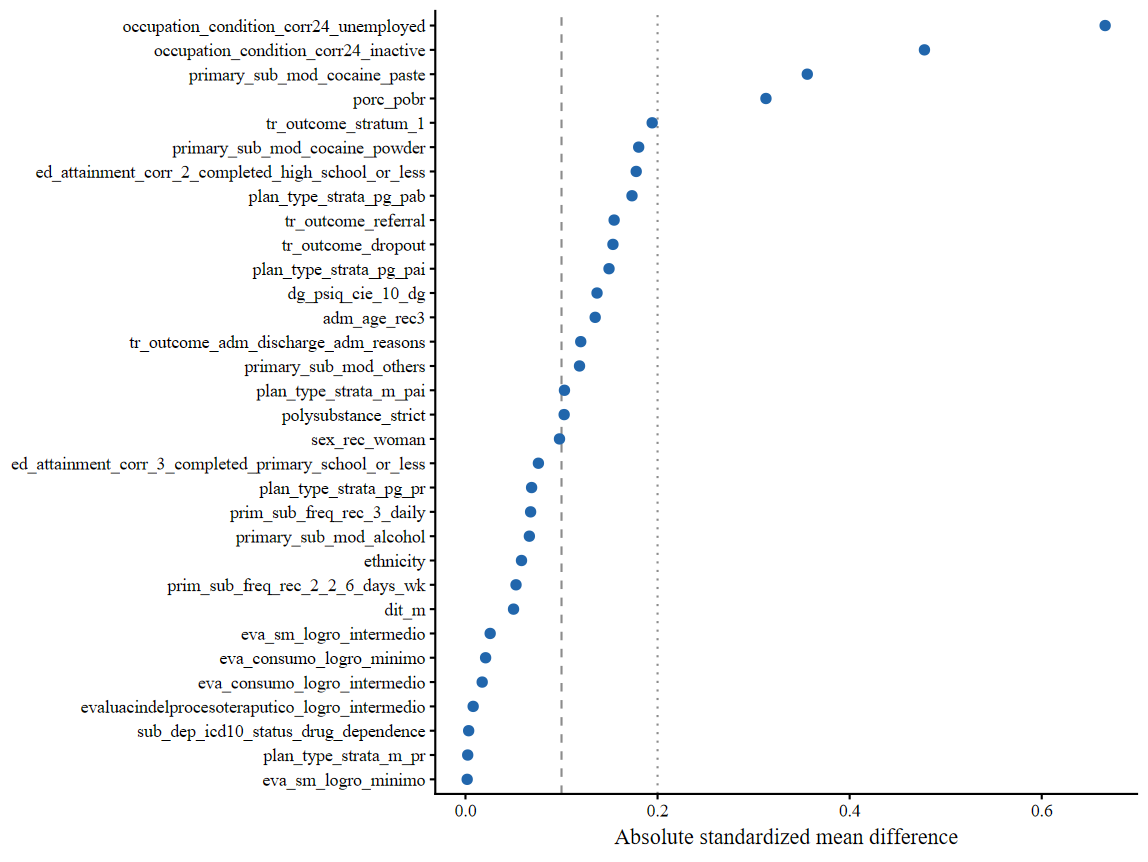

In [89]:
#| label: smd-comparison

cat("\n--- Standardized mean difference comparison ---\n")
cat("Comparing development imputations to external validation cohort.\n")
flush.console()
# Compute SMDs between each development imputation and the external cohort,
# then pool across imputations.
smd <- compute_smd_across_imputations(train_list, external_data, plan_levels)
# Print the 15 largest mean absolute SMDs.
table_html(
  utils::head(smd$summary, 15L),
  "Largest development-versus-external standardized mean differences",
  digits = 3
)
# Compute supplementary SMDs restricted to external patients with at least
# the horizon's worth of potential follow-up.
horizon_smd <- compute_horizon_complete_followup_smd(
  train_list, external_data, plan_levels, HORIZONS
)
# Print the top 5 largest SMDs per horizon.
table_html(
  horizon_smd |>
    dplyr::group_by(horizon_months) |>
    dplyr::slice_max(abs_smd_mean, n = 5, with_ties = FALSE) |>
    dplyr::ungroup(),
  "Supplementary SMD diagnostic among patients with complete potential follow-up",
  digits = 3
)
# Create a dot plot of absolute SMDs for visual inspection of transportability.
smd_plot <- ggplot2::ggplot(
  smd$summary,
  ggplot2::aes(x = stats::reorder(variable, abs_smd_mean), y = abs_smd_mean)
) +
  ggplot2::geom_hline(yintercept = c(0.10, 0.20), linetype = c("dashed", "dotted"), color = "grey55") +
  ggplot2::geom_point(color = "#2166AC", size = 2) +
  ggplot2::coord_flip() +
  ggplot2::labs(x = NULL, y = "Absolute standardized mean difference") +
  ggplot2::theme_classic(base_size = 11, base_family = "serif")
cat("Displaying SMD plot.\n")
flush.console()
print(smd_plot)

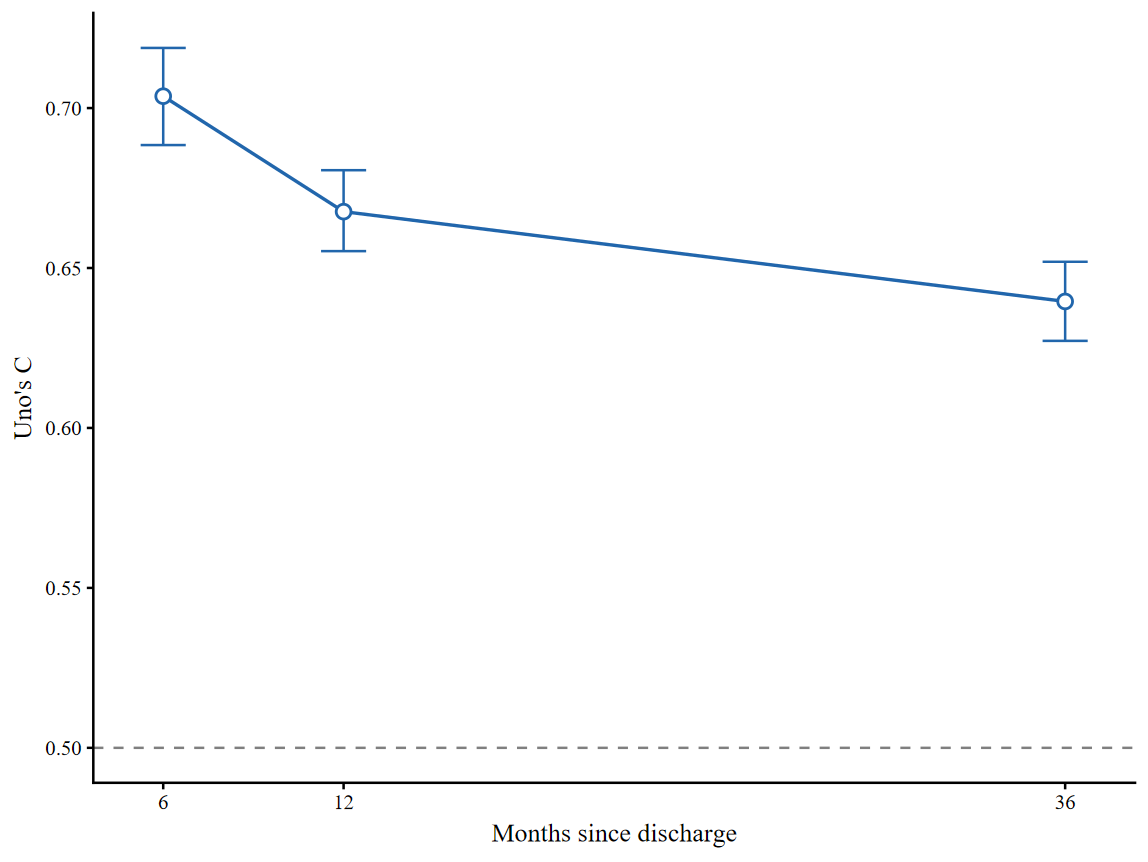

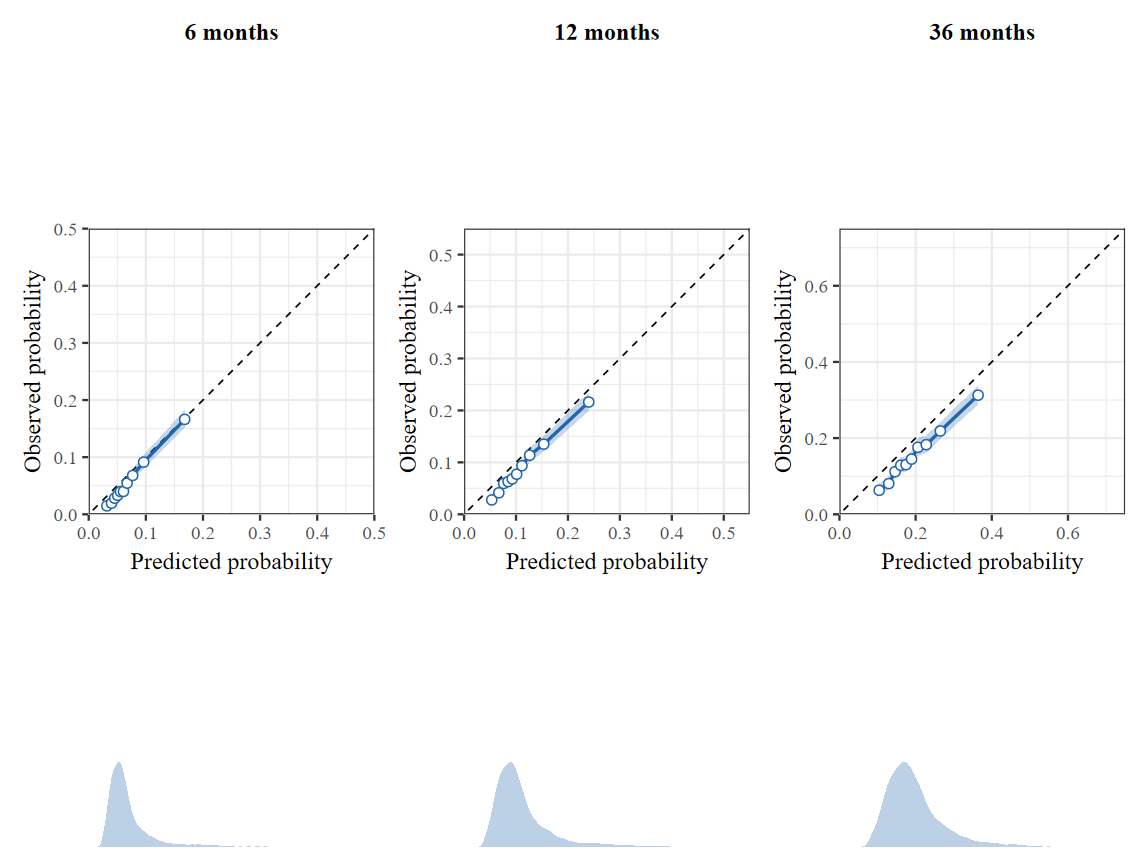

In [93]:
#| label: publication-style-figures
#| fig-width: 12
#| fig-height: 4.5

concordance_plot <- plot_concordance(external_c$summary)
print(concordance_plot)

calibration_panels <- lapply(seq_along(HORIZONS), function(j) {
  horizon <- HORIZONS[[j]]
  create_calibration_panel(
    calibration_curves[calibration_curves$horizon_months == horizon, ],
    external_predictions$horizon$pooled[, j],
    horizon
  )
})
calibration_plot <- patchwork::wrap_plots(calibration_panels, nrow = 1)
print(calibration_plot)

suffix <- if (OFFICIAL_RUN) "full" else "tentative_smoke"
ggplot2::ggsave(file.path(OUTPUT_DIR, paste0("readmission_uno_c_", suffix, ".png")), concordance_plot, width = 7, height = 4.5, dpi = 300)
ggplot2::ggsave(file.path(OUTPUT_DIR, paste0("readmission_calibration_", suffix, ".png")), calibration_plot, width = 12, height = 5, dpi = 300)
ggplot2::ggsave(file.path(OUTPUT_DIR, paste0("readmission_smd_", suffix, ".png")), smd_plot, width = 8, height = 8, dpi = 300)


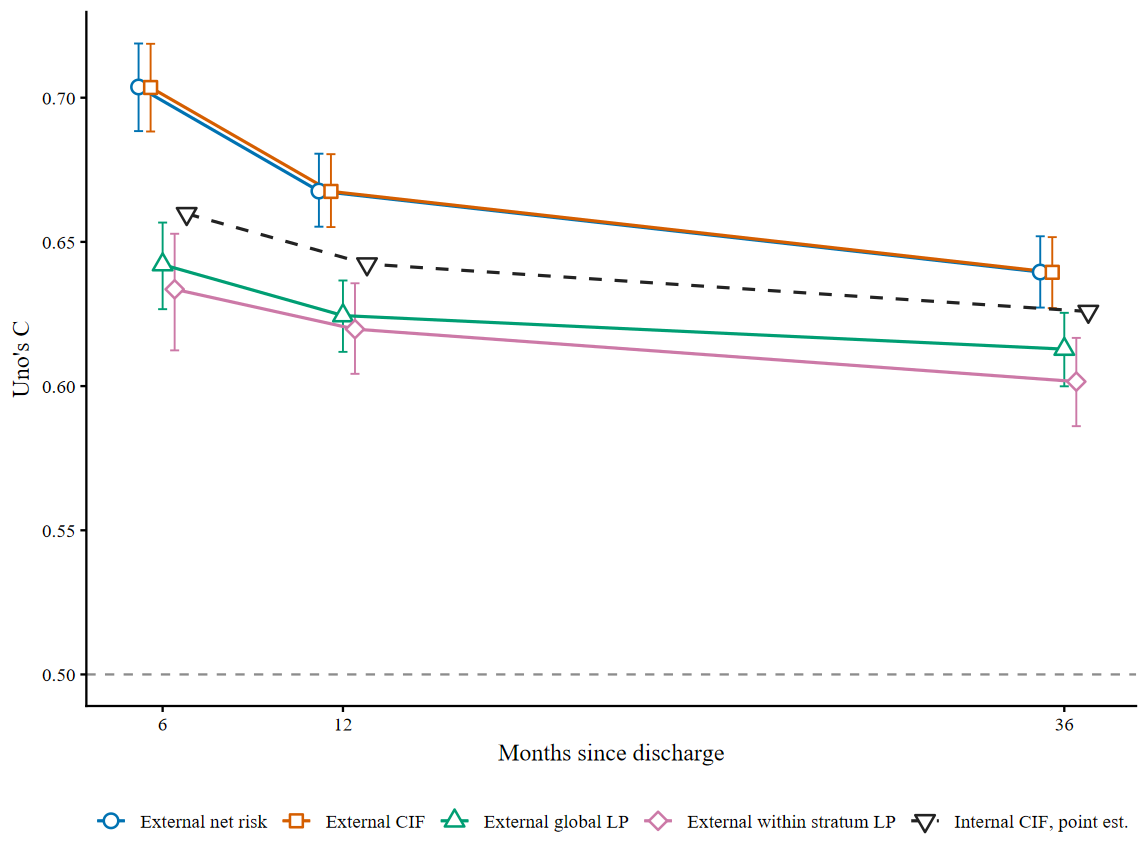

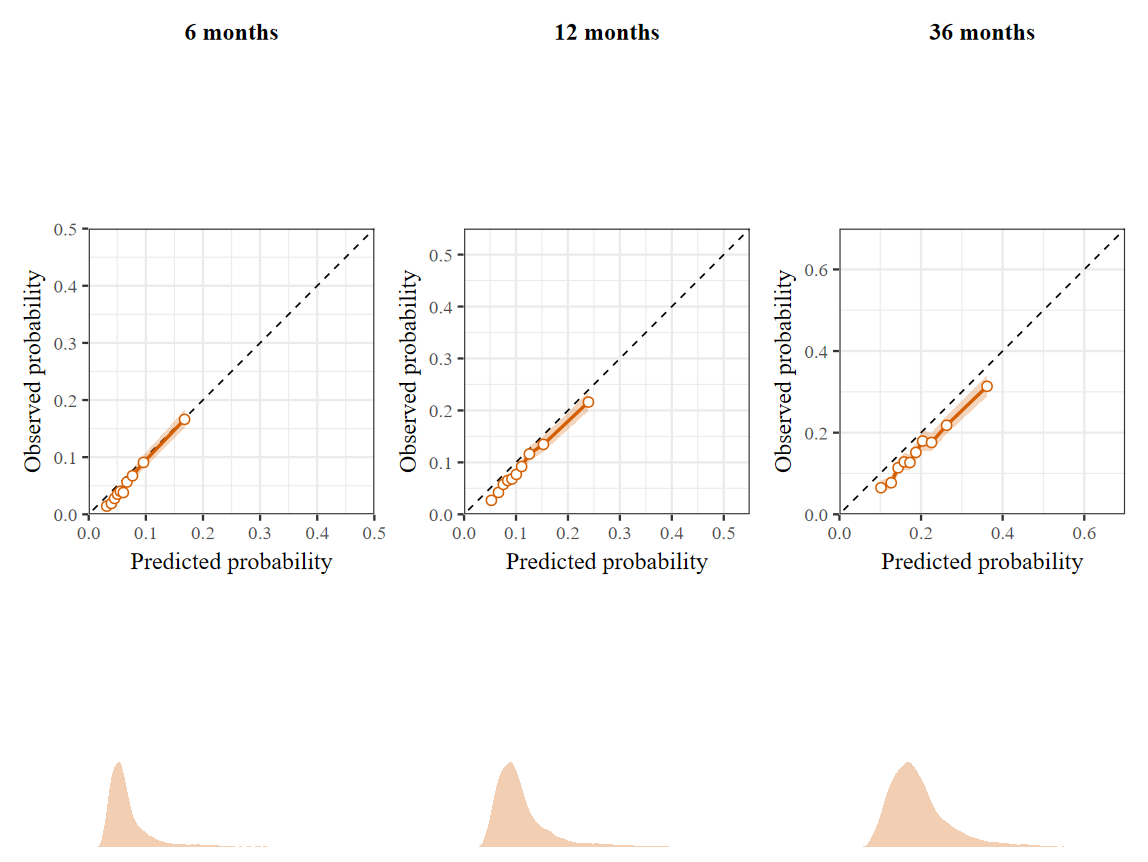

Completed concordance and CIF calibration figures in 0.04 minutes.


In [101]:
#| label: concordance-and-cif-calibration-comparison                                                                                     
  #| fig-width: 12                                                                                                                         
  #| fig-height: 5.8                                                                                                                       
                                                                                                                                           
  .t0 <- proc.time()[["elapsed"]]
  required_objects <- c(                                                                                                                   
    "external_c",                                                                                                                          
    "external_c_cif",                                                                                                                      
    "external_c_lp",                                                                                                                       
    "external_c_within",                                                                                                                   
    "internal_c_cif",                                                                                                                      
    "external_data_cif",                                                                                                                   
    "external_cif_predictions",                                                                                                            
    "external_cif_metric_boot",                                                                                                            
    "external_cif_point",                                                                                                                  
    "summarize_cif_bootstrap_metric",                                                                                                      
    "calibration_curve_groups",                                                                                                            
    "create_calibration_panel",                                                                                                            
    "HORIZONS",                                                                                                                            
    "OFFICIAL_RUN",                                                                                                                        
    "OUTPUT_DIR"                                                                                                                           
  )
  missing_objects <- required_objects[                                                                                                     
    !vapply(required_objects, exists, logical(1), inherits = TRUE)                                                                         
  ]                                                                                                                                        
  if (length(missing_objects)) {                                                                                                           
    stop(                                                                                                                                  
      "Run the preceding cells first. Missing objects: ",                                                                                  
      paste(missing_objects, collapse = ", ")                                                                                              
    )                                                                                                                                      
  }                                                                                                                                        
  # -------------------------------------------------------------------------                                                              
  # Uno's C comparison                                                                                                                     
  # -------------------------------------------------------------------------                                                              
  comparison_levels <- c(                                                                                                                  
    "External net risk",                                                                                                                   
    "External CIF",                                                                                                                        
    "External global LP",                                                                                                                  
    "External within stratum LP",                                                                                                          
    "Internal CIF, point est."                                                                                                    
  )
  comparison_data <- dplyr::bind_rows(                                                                                                     
    dplyr::mutate(                                                                                                                         
      external_c$summary,                                                                                                                  
      series = comparison_levels[[1L]]                                                                                                     
    ),                                                                                                                                     
    dplyr::mutate(                                                                                                                         
      external_c_cif$summary,                                                                                                              
      series = comparison_levels[[2L]]                                                                                                     
    ),                                                                                                                                     
    dplyr::mutate(                                                                                                                         
      external_c_lp$summary,                                                                                                               
      series = comparison_levels[[3L]]                                                                                                     
    ),                                                                                                                                     
    dplyr::mutate(                                                                                                                         
      external_c_within$summary,                                                                                                           
      series = comparison_levels[[4L]]                                                                                                     
    ),                                                                                                                                     
    dplyr::mutate(                                                                                                                         
      internal_c_cif$summary,                                                                                                              
      series = comparison_levels[[5L]]                                                                                                     
    )                                                                                                                                      
  ) |>                                                                                                                                     
    dplyr::filter(metric != "Global") |>                                                                                                   
    dplyr::mutate(                                                                                                                         
      horizon_months = as.numeric(sub(" months", "", metric)),                                                                             
      series = factor(series, levels = comparison_levels)                                                                                  
    )                                                                                                                                      
  # Slightly offset the series because the external net risk and CIF estimates                                                             
  # are almost identical and would otherwise be drawn on top of each other.                                                                
  comparison_offsets <- stats::setNames(                                                                                                   
    seq(-0.8, 0.8, length.out = length(comparison_levels)),                                                                                
    comparison_levels                                                                                                                      
  )                                                                                                                                        
  comparison_data$plot_horizon <- comparison_data$horizon_months +                                                                         
    unname(comparison_offsets[as.character(comparison_data$series)])                                                                       
  comparison_interval_data <- comparison_data |>                                                                                           
    dplyr::filter(is.finite(lower_95), is.finite(upper_95))                                                                                
  comparison_colors <- stats::setNames(                                                                                                    
    c("#0072B2", "#D55E00", "#009E73", "#CC79A7", "#222222"),                                                                              
    comparison_levels                                                                                                                      
  )                                                                                                                                        
  comparison_shapes <- stats::setNames(                                                                                                    
    c(21, 22, 24, 23, 25),                                                                                                                 
    comparison_levels                                                                                                                      
  )                                                                                                                                        
  comparison_linetypes <- stats::setNames(                                                                                                 
    c("solid", "solid", "solid", "solid", "dashed"),                                                                                       
    comparison_levels                                                                                                                      
  )                                                                                                                                        
  concordance_comparison_plot <- ggplot2::ggplot(                                                                                          
    comparison_data,                                                                                                                       
    ggplot2::aes(                                                                                                                          
      x = plot_horizon,                                                                                                                    
      y = estimate,                                                                                                                        
      group = series
    )                                                                                                                                      
  ) +                                                                                                                                      
    ggplot2::geom_hline(                                                                                                                   
      yintercept = 0.5,                                                                                                                    
      linetype = "dashed",                                                                                                                 
      color = "grey55"                                                                                                                     
    ) +                                                                                                                                    
    ggplot2::geom_errorbar(                                                                                                                
      data = comparison_interval_data,                                                                                                     
      ggplot2::aes(                                                                                                                        
        ymin = lower_95,                                                                                                                   
        ymax = upper_95,                                                                                                                   
        color = series                                                                                                                     
      ),                                                                                                                                   
      width = 0.30,                                                                                                                        
      linewidth = 0.45                                                                                                                     
    ) +                                                                                                                                    
    ggplot2::geom_line(                                                                                                                    
      ggplot2::aes(                                                                                                                        
        color = series,                                                                                                                    
        linetype = series                                                                                                                  
      ),                                                                                                                                   
      linewidth = 0.75                                                                                                                     
    ) +                                                                                                                                    
    ggplot2::geom_point(                                                                                                                   
      ggplot2::aes(                                                                                                                        
        color = series,                                                                                                                    
        shape = series                                                                                                                     
      ),                                                                                                                                   
      fill = "white",                                                                                                                      
      size = 2.8,                                                                                                                          
      stroke = 0.9                                                                                                                         
    ) +                                                                                                                                    
    ggplot2::scale_x_continuous(                                                                                                           
      breaks = HORIZONS,                                                                                                                   
      labels = HORIZONS                                                                                                                    
    ) +                                                                                                                                    
    ggplot2::scale_color_manual(                                                                                                           
      values = comparison_colors,                                                                                                          
      name = NULL                                                                                                                          
    ) +                                                                                                                                    
    ggplot2::scale_shape_manual(                                                                                                           
      values = comparison_shapes,                                                                                                          
      name = NULL                                                                                                                          
    ) +                                                                                                                                    
    ggplot2::scale_linetype_manual(                                                                                                        
      values = comparison_linetypes,                                                                                                       
      name = NULL                                                                                                                          
    ) +                                                                                                                                    
    ggplot2::labs(                                                                                                                         
      x = "Months since discharge",                                                                                                        
      y = "Uno's C"#,                                                                                                                       
      # caption = paste(                                                                                                                     
      #   "Series are horizontally offset within each horizon for visibility.",                                                              
      #   "The within stratum and global estimates use different comparable pair sets.",                                                     
      #   "The internal CIF series has no bootstrap confidence interval."                                                                    
      # )                                                                                                                                    
    ) +                                                                                                                                    
    ggplot2::theme_classic(                                                                                                                
      base_size = 12,                                                                                                                      
      base_family = "serif"                                                                                                                
    ) +                                                                                                                                    
    ggplot2::theme(                                                                                                                        
      legend.position = "bottom",
      plot.caption = ggplot2::element_text(                                                                                                
        hjust = 0,                                                                                                                         
        size = 9                                                                                                                           
      )                                                                                                                                    
    )                                                                                                                                      
  print(concordance_comparison_plot)                                                                                                       
  # -------------------------------------------------------------------------                                                              
  # External CIF calibration plot                                                                                                          
  # -------------------------------------------------------------------------                                                              
  # external_cif_metric_boot contains bootstrap distributions for scalar                                                                   
  # calibration metrics. It does not contain the grouped calibration curves.                                                               
  # Therefore, the curves are constructed from the CIF predictions, while the                                                              
  # bootstrap object supplies the E/O, ICI, and slope confidence intervals.                                                                
  cif_bootstrap_metrics <- c(                                                                                                              
    "expected_to_observed",                                                                                                                
    "ici",                                                                                                                                 
    "calibration_slope"                                                                                                                    
  )                                                                                                                                        
  cif_bootstrap_summary_for_plot <- dplyr::bind_rows(lapply(                                                                               
    cif_bootstrap_metrics,                                                                                                                 
    function(metric) {                                                                                                                     
      summarize_cif_bootstrap_metric(                                                                                                      
        external_cif_metric_boot,                                                                                                          
        metric,                                                                                                                            
        HORIZONS                                                                                                                           
      )                                                                                                                                    
    }                                                                                                                                      
  ))                                                                                                                                       
  external_cif_calibration_curves <- dplyr::bind_rows(lapply(                                                                              
    seq_along(HORIZONS),                                                                                                                   
    function(j) {                                                                                                                          
      calibration_curve_groups(                                                                                                            
        time = external_data_cif$readmit_time_from_disch_m,                                                                                
        event = external_data_cif$readmit_event,                                                                                           
        predicted_risk = external_cif_predictions$horizon$pooled[, j],                                                                     
        horizon = HORIZONS[[j]],                                                                                                           
        groups = 10L                                                                                                                       
      )                                                                                                                                    
    }                                                                                                                                      
  ))                                                                                                                                       
  format_cif_bootstrap_annotation <- function(horizon) {                                                                                   
    point <- external_cif_point$table[                                                                                                     
      external_cif_point$table$horizon_months == horizon,                                                                                  
      ,                                                                                                                                    
      drop = FALSE                                                                                                                         
    ]                                                                                                                                      
    if (nrow(point) != 1L) {                                                                                                               
      stop(                                                                                                                                
        "Expected one external CIF point estimate row at ",                                                                                
        horizon,                                                                                                                           
        " months."                                                                                                                         
      )                                                                                                                                    
    }                                                                                                                                      
    interval_at <- function(metric) {                                                                                                      
      interval <- cif_bootstrap_summary_for_plot[                                                                                          
        cif_bootstrap_summary_for_plot$horizon_months == horizon &                                                                         
          cif_bootstrap_summary_for_plot$metric == metric,                                                                                 
        ,                                                                                                                                  
        drop = FALSE                                                                                                                       
      ]                                                                                                                                    
      if (nrow(interval) != 1L) {                                                                                                          
        stop(                                                                                                                              
          "Expected one bootstrap interval for ",                                                                                          
          metric,                                                                                                                          
          " at ",                                                                                                                          
          horizon,                                                                                                                         
          " months."                                                                                                                       
        )                                                                                                                                  
      }                                                                                                                                    
                                                                                                                                           
      interval                                                                                                                             
    }                                                                                                                                      
    eo_interval <- interval_at("expected_to_observed")                                                                                     
    ici_interval <- interval_at("ici")                                                                                                     
    slope_interval <- interval_at("calibration_slope")                                                                                     
    sprintf(                                                                                                                               
      paste0(                                                                                                                              
        "E/O %.3f (95%% bootstrap CI %.3f to %.3f); ",                                                                                     
        "ICI %.3f (%.3f to %.3f)\n",                                                                                                       
        "Calibration slope %.2f (%.2f to %.2f)"                                                                                            
      ),                                                                                                                                   
      point$expected_to_observed[[1L]],                                                                                                    
      eo_interval$lower_95[[1L]],                                                                                                          
      eo_interval$upper_95[[1L]],                                                                                                          
      point$ici[[1L]],                                                                                                                     
      ici_interval$lower_95[[1L]],                                                                                                         
      ici_interval$upper_95[[1L]],                                                                                                         
      point$calibration_slope[[1L]],                                                                                                       
      slope_interval$lower_95[[1L]],                                                                                                       
      slope_interval$upper_95[[1L]]                                                                                                        
    )                                                                                                                                      
  }                                                                                                                                        
  external_cif_calibration_panels <- lapply(                                                                                               
    seq_along(HORIZONS),                                                                                                                   
    function(j) {                                                                                                                          
      horizon <- HORIZONS[[j]]                                                                                                             
      curve <- external_cif_calibration_curves[                                                                                            
        external_cif_calibration_curves$horizon_months == horizon,                                                                         
        ,                                                                                                                                  
        drop = FALSE                                                                                                                       
      ]                                                                                                                                    
      panel <- create_calibration_panel(                                                                                                   
        curve = curve,                                                                                                                     
        individual_risk = external_cif_predictions$horizon$pooled[, j],                                                                    
        horizon = horizon,                                                                                                                 
        color = "#D55E00"                                                                                                                  
      )                                                                                                                                    
      (                                                                                                                                    
        panel +                                                                                                                            
          patchwork::plot_annotation(                                                                                                      
            caption = format_cif_bootstrap_annotation(horizon)                                                                             
          )                                                                                                                                
      ) &                                                                                                                                  
        ggplot2::theme(                                                                                                                    
          plot.caption = ggplot2::element_text(                                                                                            
            hjust = 0.5,                                                                                                                   
            size = 8                                                                                                                       
          )                                                                                                                                
        )                                                                                                                                  
    }                                                                                                                                      
  )                                                                                                                                        
  external_cif_calibration_plot <- patchwork::wrap_plots(                                                                                  
    external_cif_calibration_panels,                                                                                                       
    nrow = 1                                                                                                                               
  ) +                                                                                                                                      
    patchwork::plot_annotation(                                                                                                            
      title = NULL,#"External CIF calibration",                                                                                                  
      subtitle = NULL,#paste0(                                                                                                                   
        #"Calibration metrics use percentile intervals from ",                                                                              
        #dim(external_cif_metric_boot)[[3L]],                                                                                               
        #" bootstrap replicates"                                                                                                            
      #),                                                                                                                                   
      #caption = paste(                                                                                                                     
      #  "The curves and ribbons show grouped Kaplan Meier observed risks.",                                                                
      #  "External death ascertainment was unavailable, so death remains treated as censoring on the observed side."                        
      #)                                                                                                                                    
    )                                                                                                                                      
                                                                                                                                           
  print(external_cif_calibration_plot)                                                                                                     
  # -------------------------------------------------------------------------                                                              
  # Save the two additional figures                                                                                                        
  # -------------------------------------------------------------------------                                                              
  suffix <- if (OFFICIAL_RUN) "full" else "tentative_smoke"                                                                                
  ggplot2::ggsave(                                                                                                                         
    filename = file.path(                                                                                                                  
      OUTPUT_DIR,                                                                                                                          
      paste0("readmission_uno_c_comparison_", suffix, ".png")                                                                              
    ),                                                                                                                                     
    plot = concordance_comparison_plot,                                                                                                    
    width = 10,                                                                                                                            
    height = 5.5,                                                                                                                          
    dpi = 300                                                                                                                              
  )                                                                                                                                        
  ggplot2::ggsave(                                                                                                                         
    filename = file.path(                                                                                                                  
      OUTPUT_DIR,                                                                                                                          
      paste0("readmission_cif_calibration_", suffix, ".png")                                                                               
    ),                                                                                                                                     
    plot = external_cif_calibration_plot,                                                                                                  
    width = 12,                                                                                                                            
    height = 5.8,                                                                                                                          
    dpi = 300                                                                                                                              
  )                                                                                                                                        
  cat(                                                                                                                                     
    sprintf(                                                                                                                               
      "Completed concordance and CIF calibration figures in %.2f minutes.\n",                                                              
      (proc.time()[["elapsed"]] - .t0) / 60                                                                                                
    )                                                                                                                                      
  )                        

In [ ]:
#| label: save-results

result_bundle <- list(
  created = as.character(Sys.time()),
  official_run = OFFICIAL_RUN,
  config = config,
  input_manifest = input_manifest,
  formula = f_readmit,
  fit_audit = frozen$audit,
  csc_audit = csc_build$audit,
  baseline_strata = baseline_strata,
  cohort_flow = external_built$flow,
  complete_case_flow = complete_case_flow,
  source_date_audit = source_date_audit,
  missingness = external_prepared$missingness,
  encoding_audit = external_prepared$category_audit,
  imputation_sizes = imputation_sizes,
  stratum_events = stratum_events,
  primary_substance_counts = primary_counts,
  smd_complete_vs_dropped = smd_complete_vs_dropped,
  support = support_table,
  # ---- Net-risk arm (primary) ----
  c_internal = internal_c$summary,
  c_external = external_c$summary,
  # ---- Global LP-based arm (supplementary, added for LP-vs-risk comparability) ----
  c_lp_internal = internal_c_lp$summary,
  c_lp_external = external_c_lp$summary,
  # ---- Within-stratum LP-based arm (supplementary) ----
  c_within_strata_internal = internal_c_within$summary,
  c_within_strata_external = external_c_within$summary,
  # ---- Competing-risk CIF-adjusted arm (third scoring arm) ----
  c_cif_internal = internal_c_cif$summary,
  c_cif_external = external_c_cif$summary,
  # ---- Combined comparison across all scoring arms (previously print-only) ----
  uno_c_three_arm = dplyr::bind_rows(
    dplyr::mutate(internal_c$summary,        cohort = "Internal holdout",     score = "Net risk (1-S(t), death censored)"),
    dplyr::mutate(external_c$summary,        cohort = "External temporal C1", score = "Net risk (1-S(t), death censored)"),
    dplyr::mutate(internal_c_cif$summary,    cohort = "Internal holdout",     score = "CIF (CSC cause=1, death competing risk)"),
    dplyr::mutate(external_c_cif$summary,    cohort = "External temporal C1", score = "CIF (CSC cause=1, death competing risk)"),
    dplyr::mutate(internal_c_within$summary, cohort = "Internal holdout",     score = "LP within-strata (supplementary)"),
    dplyr::mutate(external_c_within$summary, cohort = "External temporal C1", score = "LP within-strata (supplementary)")
  ) |>
    dplyr::select(cohort, score, dplyr::everything()),
  # ---- Calibration/Brier/IBS: net-risk arm ----
  performance_internal = internal_point$table,
  performance_external = performance_table,
  brier_curve_internal = internal_point$brier_curve,
  bootstrap_precision = bootstrap_precision,
  calibration_curves_external = calibration_curves,
  brier_curve_external = external_point$brier_curve,
  # ---- Calibration/Brier/IBS: CIF-adjusted arm ----
  performance_internal_cif = internal_cif_point$table,
  performance_external_cif = external_cif_point$table,
  brier_curve_internal_cif = internal_cif_point$brier_curve,
  brier_curve_external_cif = external_cif_point$brier_curve,
  bootstrap_precision_cif = external_cif_bootstrap_summary,
  calibration_internal_cif_aj = internal_cif_aj$metrics,
  # ---- Riley precision, descriptive, SMD ----
  riley = riley_results,
  riley_actual_n = riley_actual_n,
  events_per_parameter = event_parameter_table,
  smd = smd,
  horizon_complete_followup_smd = horizon_smd,
  stage_times = stage_times,
  mortality_measurement_note = paste(
    "Individual post-2020 death dates were unavailable and were not used to censor external follow-up.",
    "The exact internally death-masked sensitivity requires reconstruction from the pre-censoring source layer."
  )
)
suffix <- if (OFFICIAL_RUN) "full" else "tentative_smoke"
saveRDS(result_bundle, file.path(PROJECT_ROOT, "data", "20241015_out", paste0("prediction26_", suffix, ".rds")))


# ---- Heavy artifacts: fitted models, per-imputation prediction matrices, and
# raw bootstrap replicate arrays. Kept OUT of result_bundle so the main bundle
# stays fast to load; these exist so nothing here requires a full refit or a
# B_BOOT-replicate bootstrap rerun to recover. ----
model_artifact_bundle <- list(
  created = as.character(Sys.time()),
  model_fits_readmit = fits,
  model_fits_death_csc = csc_fits,
  external_predictions = external_predictions,
  internal_predictions = internal_predictions,
  external_cif_predictions = external_cif_predictions,
  internal_cif_predictions = internal_cif_predictions,
  c_external_replicates = external_c$replicates,
  c_lp_external_replicates = external_c_lp$replicates,
  c_within_strata_external_replicates = external_c_within$replicates,
  c_cif_external_replicates = external_c_cif$replicates,
  calibration_boot_external_replicates = external_metric_boot,
  calibration_boot_external_cif_replicates = external_cif_metric_boot
)
saveRDS(model_artifact_bundle, file.path(PROJECT_ROOT, "data", "20241015_out", paste0("prediction26_", suffix, "_model_artifacts.rds")))

csv_objects <- list(
  config = config,
  input_manifest = input_manifest,
  cohort_flow = external_built$flow,
  complete_case_flow = complete_case_flow,
  source_date_audit = source_date_audit,
  missingness = external_prepared$missingness,
  imputation_sizes = imputation_sizes,
  stratum_events = stratum_events,
  primary_substance_counts = primary_counts,
  smd_complete_vs_dropped = smd_complete_vs_dropped,
  support = support_table,
  performance_external = performance_table,
  performance_external_cif = external_cif_point$table,
  uno_c_within_strata = dplyr::bind_rows(
    dplyr::mutate(internal_c_within$summary, cohort = "Internal holdout"),
    dplyr::mutate(external_c_within$summary, cohort = "External temporal C1")
  ),
  uno_c_lp_global = dplyr::bind_rows(
    dplyr::mutate(internal_c_lp$summary, cohort = "Internal holdout"),
    dplyr::mutate(external_c_lp$summary, cohort = "External temporal C1")
  ),
  uno_c_three_arm = result_bundle$uno_c_three_arm,
  bootstrap_precision = bootstrap_precision,
  bootstrap_precision_cif = external_cif_bootstrap_summary,
  calibration_curves_external = calibration_curves,
  calibration_internal_cif_aj = internal_cif_aj$metrics,
  riley = riley_results,
  riley_actual_n = riley_actual_n,
  events_per_parameter = event_parameter_table,
  smd_summary = smd$summary,
  smd_detailed = smd$detailed,
  horizon_complete_followup_smd = horizon_smd,
  stage_times = stage_times
)
invisible(Map(function(data, name) {
  utils::write.csv(data, file.path(OUTPUT_DIR, paste0(name, ".csv")), row.names = FALSE, na = "")
}, csv_objects, names(csv_objects)))

output_manifest <- data.frame(
  file = list.files(OUTPUT_DIR, full.names = TRUE),
  size_bytes = file.info(list.files(OUTPUT_DIR, full.names = TRUE))$size
)
print_table(stage_times, "Measured execution time by stage", digits = 2)
print_table(output_manifest, "Output manifest", digits = 0)

if (!OFFICIAL_RUN) {
  cat("\nRESULT STATUS: TENTATIVE SMOKE TEST. Do not cite or transfer these estimates to the manuscript.\n")
}



Table: Measured execution time by stage

|stage                                               | seconds|
|:---------------------------------------------------|-------:|
|Load frozen inputs                                  |    2.75|
|Build external readmission cohort                   |    3.22|
|Create explicit model-ready external data           |    0.08|
|Fit five frozen development models                  |    6.71|
|Predict external readmission risk                   |    8.75|
|Predict internal holdout risk                       |    8.27|
|Augment external cohort with death-model covariates |    0.38|
|Fit joint CSC (readmission + death) models          |   10.87|
|Predict external competing-risk CIF                 |   18.89|
|Predict internal competing-risk CIF                 |   17.42|
|External Uno C bootstrap                            |  133.47|
|Internal Uno C point estimates                      |    0.29|
|External calibration, Brier, and IBS bootstrap      |  694.6

In [103]:
#| label: session-info
#| echo: true
#| error: true
#| message: true
#| paged.print: true

message(paste0("R library: ", Sys.getenv("R_LIBS_USER")))
message(paste0("Date: ",withr::with_locale(new = c('LC_TIME' = 'C'), code =Sys.time())))
message(paste0("Editor context: ", getwd()))
cat("quarto version: "); quarto::quarto_version()
sesion_info <- devtools::session_info()

tabla_pkg <- dplyr::select(
  tibble::as_tibble(sesion_info$packages),
  package,
  loadedversion,
  source
)

tabla_pkg <- tibble::rowid_to_column(tabla_pkg, var = "row_number")

names(tabla_pkg) <- c("Row number", "Package", "Version", "Source")

htmltools::browsable(
  htmltools::tags$div(
    style = "
      max-height: 420px;
      overflow: auto;
      border: 1px solid #ddd;
      font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
      font-size: 70%;
      line-height: 0.75em;
      width: 100%;
    ",
    htmltools::tags$caption(
      style = "
        caption-side: top;
        text-align: left;
        display: block;
        padding: 6px 4px;
        font-size: 120%;
        line-height: 1.2em;
      ",
      htmltools::em("R packages")
    ),
    htmltools::tags$table(
      style = "
        border-collapse: collapse;
        width: max-content;
        min-width: 100%;
        white-space: nowrap;
      ",
      htmltools::tags$thead(
        htmltools::tags$tr(
          lapply(names(tabla_pkg), function(nm) {
            htmltools::tags$th(
              style = "
                position: sticky;
                top: 0;
                z-index: 2;
                background: #f3f3f3;
                border-bottom: 1px solid #ccc;
                padding: 4px 8px;
                text-align: left;
                white-space: nowrap;
              ",
              nm
            )
          })
        )
      ),
      htmltools::tags$tbody(
        lapply(seq_len(nrow(tabla_pkg)), function(i) {
          htmltools::tags$tr(
            lapply(tabla_pkg[i, ], function(x) {
              htmltools::tags$td(
                style = "
                  border-bottom: 1px solid #eee;
                  padding: 3px 8px;
                  white-space: nowrap;
                ",
                as.character(x)
              )
            })
          )
        })
      )
    )
  )
)

R library: C:\Users\andre\AppData\Local/R/win-library/4.4
Date: 2026-07-20 22:06:32.632794
Editor context: g:/My Drive/Alvacast/SISTRAT 2023/cons
quarto version: 

Warning message:
In system2("quarto", "-V", stdout = TRUE, env = paste0("TMPDIR=",  :
  running command '"quarto" TMPDIR=C:/Users/andre/AppData/Local/Temp/RtmpwJLuyv/file47a499518bf -V' had status 1


1,backports,1.5.0,CRAN (R 4.4.1)
2,base64enc,0.1-3,CRAN (R 4.4.1)
3,cachem,1.1.0,CRAN (R 4.4.1)
4,checkmate,2.3.3,CRAN (R 4.4.3)
5,cli,3.6.4,CRAN (R 4.4.1)
6,cluster,2.1.8.1,CRAN (R 4.4.1)
7,cmprsk,2.2-12,CRAN (R 4.4.1)
8,codetools,0.2-20,CRAN (R 4.4.1)
9,colorspace,2.1-2,CRAN (R 4.4.3)
10,crayon,1.5.3,CRAN (R 4.4.1)
11,data.table,1.17.8,CRAN (R 4.4.3)
